# DCAFA: Differential Community Abundance and Feature Attribution Analysis for Concept Mining and Explainability in Biomedical Applications
(Piotr Keller, George Wright,, & Fayyaz Minhas)

## Motivation and Need

Biomedical, imaging, and omics datasets are typically **hierarchically structured**: fine-grained **instances** (e.g., cells, image patches, sequencing reads) are nested within **bags** (e.g., patients, slides, samples). To draw biologically meaningful conclusions, we need methods that can (i) quantify whether **communities of instances** differ across conditions and (ii) attribute **features of instances or communities** to clinical or biological outcomes.

**Examples:**
- In **histopathology**, image patches cluster into morphological communities; expansion or contraction of such communities may predict tumor aggressiveness.  
- In **single-cell transcriptomics**, cellular states form transcriptional communities; shifts in their prevalence can indicate disease subtypes.  
- In **microbiome ecology**, microbial taxa form functional communities whose abundances vary with host diet or disease.  

The **Differential Community Abundance and Feature Attribution (DCAFA)** framework unifies community-based differential analysis and feature attribution into four modules (CA1, CA2, FA1, FA2) which can be used for different analyses
DCAFA unifies:
- **CA1/CA2** for *differential community abundance* for Outcome
- **FA1/FA2** for *feature attribution*  to Outcome
- Feature Attribution for Community Membership

It leverages GLMs with offsets, clustered inference, and FDR correction, while explicitly addressing community membership estimation and collinearity. The framework is broadly applicable to histopathology, spatial omics, and microbiome research.  
Each module follows a structured presentation: **Goal → Intuition → Model → Interpretation → Caveats**.

---

## Hierarchical Data Setup

We assume:
- $N$ bags indexed by $i=1,\dots,N$  
- $P$ instances indexed by $p=1,\dots,P$  
- Mapping $s(p)=i$ assigns each instance $p$ to bag $i$  

Each instance $p$ has:
- Features $x_p \in \mathbb{R}^d$  
- Membership profile over $K$ communities, $m_{pk}\in[0,1]$, with $\sum_k m_{pk}=N$ in the **exclusive** case, and $\sum_k m_{pk}\leq 1$ in **soft/overlapping** cases  

For bag $i$:
- Bag size:  
$$
n_i = \sum_{p:\,s(p)=i} 1
$$
- Community counts:  
$$
c_{ik} = \sum_{p:\,s(p)=i} m_{pk}
$$

Outcomes:
- Bag-level: $y_i \in \mathbb{R}^{R_y}$  
- Instance-level: $t_p \in \mathbb{R}^{R_t}$  

Optional covariates: $v_i \in \mathbb{R}^q$ (e.g., site, scanner, batch).

---

## Obtaining Community Memberships

Communities can be derived in several ways, depending on whether memberships are **exclusive** (hard clustering) or **overlapping/probabilistic** (soft clustering or neighborhoods). This needs to be done by the user. This flexibility ensures DCAFA can be applied to both *hard-partitioned* and *continuous, overlapping* community structures.

**1. Clustering-based (exclusive).**  
Classical clustering methods such as $k$-means, Gaussian mixture models (GMMs), hierarchical clustering, spectral clustering, or graph-based clustering (e.g., Leiden, Louvain) partition instances into non-overlapping groups.  
- Hard membership: $m_{pk}\in\{0,1\}$ with $\sum_k m_{pk}=1$.  
- Suitable when we expect discrete, well-separated populations (e.g., distinct cell types).  

**2. Similarity or Neighborhood-based (overlapping).**  
Instead of defining a small number of clusters, communities can also be defined by **local neighborhoods**

- **Construction.**  
  1. Build a $k$NN graph of all instances (cells, patches, etc.) in a reduced space (e.g., PCA, UMAP, autoencoder embedding).  
  2. Select a set of **index nodes** (typically a subsample of instances, or one per connected component / cluster).  
  3. For each index node, define its community as the set of that node and its $k$ neighbors.  

- **Memberships.**  
  An instance can belong to multiple such neighborhoods:  
  $$
  m_{pk} = \mathbf{1}\{ \text{instance } p \in N(k)\}, \qquad
  \sum_k m_{pk} \geq 1.
  $$  
  Here $N(k)$ denotes the neighborhood centered at index node $k$.  
  Because each instance may appear in many neighborhoods, memberships are **overlapping by design**.

- **Practical use.**  
  To avoid having $P$ neighborhoods (one per instance), we usually:  
  - Use a **subset of index nodes** (e.g., every 20th node, or a random 5–10% of instances).  
  - Optionally **merge highly similar neighborhoods** (e.g., by Jaccard similarity threshold).  
  - This yields a tractable number of overlapping communities (hundreds–thousands, not $P$).  

- **Advantages.**  
  - Captures **local manifold structure** that clustering may miss.  
  - Sensitive to **rare or transitional populations** (e.g., rare immune subtypes, differentiation trajectories).  
  - Allows enrichment testing in fine-grained regions rather than only global clusters.  

- **Caveats.**  
  - Neighborhoods overlap heavily → collinearity in $M=[m_{pk}]$.  
    - Use regularization (ridge/elastic net) or sum-to-zero constraints to stabilize regression.  
  - Neighborhood size $k$ is critical: too small → noisy neighborhoods; too large → neighborhoods approximate global clusters.  
  - Multiple testing burden can be high; BH-FDR or spatial FDR adjustments are recommended.  


**3. Topic models and factorization (overlapping).**  
Instead of clusters or neighborhoods, we can represent each instance as a combination of **latent topics** or **factors** learned from the data.  

- **Binary or sparse topics.**  
  Methods such as CorEx (Correlation Explanation), sparse coding, or Boolean matrix factorization instead assign instances to topics in a *binary or near-binary* manner:  
  $$
  m_{pk} \in \{0,1\} \quad \text{(or mostly 0 with few non-zero entries)}.
  $$  
  - An instance can belong to multiple topics simultaneously, but only a small subset.  
  - This yields **overlapping but interpretable factors** (e.g., “topic = expression of gene module X”), where membership is a *switch* rather than a graded weight.  
  - Useful when communities correspond to *distinct latent attributes* that can co-occur (e.g., “immune activation” and “stress response” both active in the same cell).  

- **Continuous topics (mixture-based).**  
  Methods such as non-negative matrix factorization (NMF), latent Dirichlet allocation (LDA), or deep generative models (e.g., scVI/SCANVI) yield *graded memberships*.  
  - Each instance $p$ has topic loadings $m_{pk}\in[0,1]$, with $\sum_k m_{pk}=1$ (for LDA) or unconstrained (for NMF).  
  - This reflects the degree to which each latent program (e.g., pathway, morphological pattern) is expressed in an instance.  
  - Suitable for capturing **continuous biological programs** such as activation gradients or cell-cycle phases.  


- **Intuition.**  
  Topic-based communities do not partition the data but instead reveal *axes of variation*. Continuous topics describe **how much** of a program is expressed, while binary topics indicate **whether** a program is expressed at all.  

- **Caveats.**  
  - Continuous topics may blur interpretability when loadings are diffuse across many topics.  
  - Binary topics require thresholding or sparsity-inducing priors, and may miss subtle gradients.  
  - Topic correlations can induce multicollinearity across $m_{pk}$, requiring shrinkage or orthogonalization.  


**4. Predefined or annotated communities.**  
In some cases, communities are provided a priori (e.g., cell type annotations, taxonomic groups, histological regions).  
- Memberships are hard ($m_{pk}\in\{0,1\}$) or soft if confidence scores are available.  

---

**Collinearity issue.**  
- Exclusive memberships imply $\sum_k m_{pk}=1$, so community indicators are perfectly collinear.  
- Overlapping memberships reduce but do not eliminate collinearity, since communities may be highly correlated.  
- Solutions:  
  - Drop a reference community (“baseline”)  
  - Impose a sum-to-zero constraint ($\sum_k \gamma_{k,r}=0$)  
  - Use regularization (ridge, elastic net, group lasso) to stabilize estimates.  (not implemented)




---

## Module 1: CA1 — Bag-level Community Abundance

**Goal.**  
Test whether relative abundances of communities vary systematically with bag-level outcomes.  

**Intuition.**  
If certain communities are over- or under-represented in cases versus controls, this signals biological shifts.  

**Model.**  
For each community $k$:  
$$
c_{ik} \sim \text{NB}(\mu_{ik}, \alpha_k),
$$
$$
\log \mu_{ik} = \beta_{0k} + y_i^\top \beta_k + v_i^\top \delta_k + \log n_i,
$$
where:  
- $\alpha_k$ is the dispersion parameter  
- $\log n_i$ is an offset that ensures modeling of **relative abundances** rather than raw counts  

**Interpretation.**  
- The coefficient $\beta_{k,m}$ is on the log scale.  
- Exponentiating gives the **ratio of relative abundances**:  
  $$
  \text{Ratio change} = \exp(\beta_{k,m}).
  $$  
- This can also be reported as a **percentage change**:  
  $$
  \text{Percentage change} = \big(\exp(\beta_{k,m}) - 1\big) \times 100\%.
  $$  

For example, if $\beta_{k,m} = 0.22$:  
- $\exp(0.22) \approx 1.25$ → community $k$ is **1.25× more abundant**  
- $(1.25 - 1)\times 100\% = 25\%$ → community $k$ is **25% more abundant**  

**Caveats.**  
- As negative binomial regression is  used which relies on counts, it is left to the user to convert memberships (esp. soft memberships) to counts.
- Rare communities ($c_{ik}$ very small) give unstable estimates → filter or merge.  
- Because abundances are compositional, coefficients should be interpreted **relative to other communities** or with constraints (e.g., reference community, sum-to-zero coding).  

---
## Module 2: CA2 — Instance-level Community Association

**Goal.**  
Test whether community membership affects instance-level outcomes.  

**Intuition.**  
If instances in a community consistently show higher or lower outcomes, this indicates that the community is outcome-associated.  

**Model.**  
For outcome dimension $r$:  
$$
t_{p,r} \sim g_r^{-1}\!\left(
\alpha_r + \sum_{k=1}^K \gamma_{k,r} m_{pk} + v_{s(p)}^\top \eta_r + u_{s(p),r}
\right),
$$
where:  
- $g_r(\cdot)$ is the link function (logit for binary outcomes, identity for Gaussian outcomes, log for count outcomes, etc.)  
- $u_{s(p),r}$ is a bag-level random intercept to account for within-bag correlation  

**Interpretation.**  
- $\gamma_{k,r}$ represents the effect of membership in community $k$ on the outcome $r$.  
- Exponentiating gives **ratios**:  
  $$
  \text{Ratio change} = \exp(\gamma_{k,r}).
  $$  
- These ratios can also be expressed as **percentage changes**:  
  $$
  \text{Percentage change} = \big(\exp(\gamma_{k,r}) - 1\big) \times 100\%.
  $$  

For example, if $\gamma_{k,r} = 0.4$:  
- $\exp(0.4) \approx 1.49$ → membership in community $k$ increases the odds/rate of outcome $r$ by a factor of 1.49  
- $(1.49 - 1)\times 100\% = 49\%$ → the outcome is **49% more likely/higher** for instances in that community  

**Importance of link function.**  
The choice of $g_r(\cdot)$ determines how coefficients are interpreted:  
- **Logit link (binary outcome):** $\exp(\gamma_{k,r})$ is an **odds ratio**.  
- **Log link (count outcome):** $\exp(\gamma_{k,r})$ is a **rate ratio**.  
- **Identity link (continuous outcome):** $\gamma_{k,r}$ is a direct **additive change** in the outcome.  

Selecting the appropriate link ensures that reported ratios and percentage changes are meaningful and correspond to the scale of the outcome.  

**Caveats.**  
- With exclusive memberships, collinearity between communities must be handled (reference coding, sum-to-zero constraints, or regularization).  
- Cluster-robust SEs or random effects ($u_{s(p),r}$) are required to account for within-bag dependence and avoid pseudoreplication.  

---

## Module 3: FA1 — Instance-level Feature Attribution

**Goal.**  
Identify which instance-level features explain outcomes.  

**Intuition.**  
Features like nuclear size, gene expression, or morphology can drive outcomes.  

**Model.**  
$$
t_{p,r} \sim g_r^{-1}\!\left(
\alpha_{0r} + x_p^\top \alpha_r + v_{s(p)}^\top \eta_r + u_{s(p),r}
\right).
$$

**Interpretation.**  
- $\alpha_{r,j}$: effect of feature $j$ on outcome $r$  
- $\exp(\alpha_{r,j})$: odds/rate ratio for non-Gaussian links  

**Caveats.**  
- High-dimensional $x_p$ requires regularization (LASSO, ridge).  
- Within-bag correlation handled via $u_{s(p),r}$.  

---

## Module 4: FA2 — Bag-level Feature Attribution

**Goal.**  
Identify which aggregated features across instances predict bag outcomes.  

**Intuition.**  
Patient-level outcomes (e.g., survival, response) may depend on global or community-averaged features.  

**Aggregations.**  
- Global average:  
$$
\tilde{x}_i = \frac{1}{n_i}\sum_{p:\,s(p)=i} x_p
$$
- Community-specific mean:  
$$
\bar{x}_{ik} = \frac{1}{c_{ik}} \sum_{p:\,s(p)=i} m_{pk} x_p
$$

**Models.**  
$$
y_{i,m} \sim \tilde{x}_i + v_i, \quad
y_{i,m} \sim \sum_{k=1}^K \bar{x}_{ik} + v_i.
$$

**Interpretation.**  
- $\zeta_{m,j}$: effect of global feature $j$ on bag outcome $m$  
- $\psi_{k,m,j}$: effect of community-specific feature $j$  

**Caveats.**  
- Global averages may dilute rare but important communities.  
- Community-specific averages sensitive to small $c_{ik}$.  

--

### **Feature Attribution for Community Membership**

To identify which instance-level features determine a patch’s membership in a given community, we can reuse the **FA1 (Feature Attribution 1)** formulation while redefining its target.

Specifically, set the instance-level **target variable** to the community membership:

$$
t_{p,k} = m_{pk},
$$

where $m_{pk}$ denotes the (soft or hard) membership of patch $p$ in community $k$.

Applying FA1 with this target yields the regression model

$$
g^{-1}\!\big(\mathbb{E}[m_{pk} \mid x_p]\big)
 = \alpha_k + x_p^{\top}\gamma_k,
$$

where $x_p$ are the instance features and $g^{-1}$ is the inverse link function (e.g., logistic).

The estimated coefficients $\gamma_{k}$ indicate how each feature influences the likelihood of belonging to community $k$:

- **Positive** coefficient $\gamma_{k,j} > 0$ → increasing feature $x^{(j)}$ **increases** the odds of belonging to community $k$.
- **Negative** coefficient $\gamma_{k,j} < 0$ → increasing feature $x^{(j)}$ **decreases** those odds.

In other words, this FA1 regression directly quantifies which features are **enriched or depleted** in each community, thereby revealing the **feature basis of community membership**.


---

## Inference and Multiple Testing

- All models provide estimates, SEs, 95% CIs, and $p$-values.  
- Benjamini–Hochberg correction applied across communities and features.  
- Within-bag dependence handled by clustered SEs or random intercepts.  

---



# How to Apply DCAFA

### Input Representation

We consider a set of $N$ patches $\{p\}_{p=1}^{N}$ extracted from WSIs.  
Each patch $p$ is represented by a $C$-dimensional concept or feature vector:
$$
x_p = [x_p^1, x_p^2, \dots, x_p^C] \in \mathbb{R}^C,
$$
where each component $x_p^c$ quantifies the degree to which the patch expresses concept $c$.

This concept activation can originate from different sources:

1. **Raw/Deep Feature Embedding**

2. **Vision–Language Model (VLM)–based concept similarity**

   Derived as the differential similarity between the patch embedding and polarity-specific text embeddings from a vision–language model (e.g., CONCH or CONCH v2):
   $$
   x_p^c
   = \operatorname{sim}\!\big(f(p), g(d_c^{+})\big)
   - \operatorname{sim}\!\big(f(p), g(d_c^{-})\big),
   $$
   where $f(\cdot)$ and $g(\cdot)$ are the VLM’s image and text encoders, and $d_c^{+}$ and $d_c^{-}$ denote the “presence/high” and “absence/low” textual descriptors for concept $c$ (see examples for colorectal cancer concepts below).

3. **Model-predicted or measured concept score**

   If a pretrained model or quantitative measurement directly provides the value of concept $c$ (e.g., epithelial cell fraction, tumour budding score, or gene expression level), then:
   $$
   x_p^c = \hat{y}_c(p),
   $$
   where $\hat{y}_c(p)$ is the predicted or observed quantitative value associated with patch $p$.

Thus, each patch $p$ is represented as a unified vector $x_p$ whose components $x_p^c$ capture concept activations derived from **differential similarity**, **model prediction**, or **other measured features**.

---
### Steps

1. **Zero-centering (concept normalization)**

   For each concept $c$, remove the global mean activation across all patches:
   $$
   x_p^c \leftarrow x_p^c - \frac{1}{N}\sum_{p=1}^{N}x_p^c
   $$
   Optionally standardize by variance for comparability:
   $$
   x_p^c \leftarrow \frac{x_p^c}{\sqrt{\frac{1}{N}\sum_p (x_p^c)^2}}
   $$

---

2. **(Optional – ignore for now) Sigmoid gating**

   Apply a per-concept temperature-scaled sigmoid to map activations to $(0,1)$:
   $$
   a_p^c = \sigma\!\left(\frac{x_p^c - b_c}{\tau_c}\right),
   \quad \sigma(u) = \frac{1}{1 + e^{-u}},
   $$
   where $b_c$ and $\tau_c$ are the center and temperature for concept $c$.

---

3. **Patch-level feature representation**

   After normalization, each patch remains represented as:
   $$
   x_p = [x_p^1, x_p^2, \dots, x_p^C] \in \mathbb{R}^C,
   $$
   forming the Semantic Activation Matrix (SAM):
   $$
   S = [x_p^c]_{p,c} \in \mathbb{R}^{N \times C}.
   $$

---

4. **Low-dimensional projection and community definition**

   - Compute the $C \times C$ correlation matrix from $S$ to identify highly coupled or redundant concepts.  
   - Perform hierarchical clustering on the correlation matrix to group correlated concepts.  
   - Optionally reduce dimensionality or redundancy via feature selection, PCA, UMAP, or topic modeling (e.g., Non-negative Matrix Factorization after sigmoid transformation).  
   - If per-patch outcomes are available, use partial least squares (with patient-level cross-validation to avoid leakage).  
   - Perform patch-level clustering or community detection.

---

5. **Community-level analysis (DCAFA)**

   - Apply DCAFA to identify **differential community abundances** across conditions or outcomes.  
   - Use the same framework for **feature attribution** (e.g., DCAFA–F1).

---

6. **Visualization**

   - Plot UMAP or PCA projections colored by selected concept activations $x_p^c$ or community labels.  
   - Display heatmaps showing community–concept associations identified by DCAFA.  
   - Present visualizations to expert pathologists for validation.

---

### Outputs
- Patch-level Semantic Activation Matrix (SAM) $S = [x_p^c] \in \mathbb{R}^{N \times C}$  
- Low-dimensional embedding of patches for visualization  
- Community structure and concept–outcome associations

---

**Interpretation**  
Each patch $p$ is represented in a biologically interpretable concept space, where the distribution of activations $x_p^c$ across patches and communities reveals how histopathological concepts vary within and across samples.

---

**Interpretation:**  
Each patch is thus represented in a biologically interpretable semantic coordinate system.  
The distribution of these semantic activations across patches and communities reveals
how histopathological concepts vary within and across patient samples.

## Example Concepts for Colorectal Cancer for use with VLM

#### **A. Adenoma / Pre-invasive Morphology**

- **Villous architecture**  
  (+) High villous or tubulovillous architecture present.  
  (–) Predominantly tubular glands with absence of villous component.  

- **Epithelial dysplasia grade**  
  (+) High-grade epithelial dysplasia with marked nuclear atypia.  
  (–) Low-grade epithelial dysplasia with mild atypia only.  

- **Cribriform or crowded glands**  
  (+) Cribriform glandular crowding within mucosa.  
  (–) No cribriform or crowded glands.  

- **Serrated features**  
  (+) Serrated or saw-tooth glandular architecture.  
  (–) Non-serrated straight tubular glands.  

---

#### **B. Tumour Architecture and Differentiation**

- **Gland-forming differentiation**  
  (+) Well-formed glands with preserved polarity and differentiation.  
  (–) Loss of glandular differentiation with poorly formed glands.  

- **Poor differentiation / solid growth**  
  (+) Poorly differentiated solid or cribriform growth pattern present.  
  (–) Absence of solid or cribriform growth pattern.  

- **Mucinous component**  
  (+) Prominent extracellular mucin pools greater than fifty percent.  
  (–) No significant mucinous component.  

- **Signet-ring cells**  
  (+) Signet-ring cell morphology present.  
  (–) No signet-ring cell morphology.  

- **Medullary pattern**  
  (+) Medullary carcinoma pattern with syncytial sheets and lymphoid stroma.  
  (–) No medullary carcinoma pattern.  

---

#### **C. Necrosis, Stroma, and Invasion Front**

- **Dirty necrosis**  
  (+) Dirty necrosis within glandular lumina present.  
  (–) Absence of dirty necrosis.  

- **Desmoplastic stromal reaction**  
  (+) Marked desmoplastic stromal reaction at the invasive front.  
  (–) Minimal or absent desmoplastic stromal reaction.  

- **Tumour border configuration**  
  (+) Infiltrative tumour border configuration.  
  (–) Pushing or expansile tumour border configuration.  

- **Tumour budding**  
  (+) High tumour budding at the invasive front.  
  (–) Low tumour budding or none.  

- **Tumour–stroma ratio**  
  (+) Stroma-rich tumour with more than fifty percent stroma.  
  (–) Stroma-poor tumour with less than fifty percent stroma.  

- **Fibro-inflammatory stromal reaction**  
  (+) Strong fibro-inflammatory stromal response surrounding glands.  
  (–) Weak or absent fibro-inflammatory stromal response.  

---

#### **D. Immune Microenvironment**

- **Intratumoral lymphocytic infiltrate (TILs)**  
  (+) High intratumoral lymphocytic infiltrate.  
  (–) Low intratumoral lymphocytic infiltrate.  

- **Peritumoral lymphoid reaction / TLS**  
  (+) Prominent peritumoral lymphoid aggregates or tertiary lymphoid structures.  
  (–) Absent peritumoral lymphoid reaction.  

- **Neutrophilic infiltrate**  
  (+) Dense intratumoral neutrophilic infiltrate.  
  (–) Minimal or absent intratumoral neutrophilic infiltrate.  

---

#### **E. Vascular, Neural, and Stage-linked Spread**

- **Lymphovascular invasion (LVI)**  
  (+) Lymphovascular invasion present.  
  (–) No lymphovascular invasion.  

- **Perineural invasion (PNI)**  
  (+) Perineural invasion present.  
  (–) No perineural invasion.  

- **Extramural venous invasion (EMVI)**  
  (+) Extramural venous invasion present.  
  (–) No extramural venous invasion.  

- **Tumour deposits / satellite nodules**  
  (+) Tumour deposits or satellite nodules present in mesocolic fat.  
  (–) No tumour deposits or satellite nodules.  

---

#### **F. Oncofetal and Primitive Program**

- **Fetal-like or oncofetal phenotype**  
  (+) Fetal-like enterocyte phenotype or oncofetal reprogramming present.  
  (–) No fetal-like or oncofetal features.  

- **Enteroblastic differentiation**  
  (+) Enteroblastic differentiation with microtrabecular or clear-cell morphology.  
  (–) No enteroblastic differentiation.  

- **Oncofetal marker expression**  
  (+) Oncofetal marker expression for SALL4, IMP3, GPC3, or AFP positive.  
  (–) Oncofetal marker expression for SALL4, IMP3, GPC3, or AFP negative.  

- **CDX2 expression**  
  (+) Loss or reduced CDX2 expression.  
  (–) Preserved CDX2 expression.  

- **WNT/YAP-driven fetal program**  
  (+) WNT or YAP driven fetal intestinal stem-cell program active.  
  (–) No evidence of WNT or YAP driven fetal program.  


## CA1 Code

### Experiment: Community Abundance Analysis with Simulated Data

In this experiment we simulate a dataset of **bags** (e.g., patients or slides), each containing counts of instances partitioned into four **communities**.  
The total number of instances per bag is drawn from a Poisson distribution, and each community’s count is generated from a **Negative Binomial GLM** with log-link and a log(total size) offset to ensure relative abundance modeling.  
We introduce a **binary outcome variable** (`y_resp`) that influences two of the four communities: one community becomes more abundant in the positive class, while another becomes less abundant. Additional covariates (`age`, `site`, `y_score`) are included to mimic real-world confounders.  

The analysis uses **Community Abundance Model 1 (CA1)**, which regresses each community’s counts on the target(s) and covariates separately.  
We then summarize the estimated coefficients as **% change in expected relative abundance** and visualize them in **forest plots**, highlighting which communities are significantly associated with the target after multiple-testing correction.  
This setup demonstrates how CA1 can identify communities that are differentially enriched or depleted between groups while accounting for bag size and covariates.


     n  c_1  c_2  c_3  c_4  y_resp   y_score        age site
0  512  130   30   67   49       1  0.191731  63.871373    B
1  480  116   19   68   43       1  1.118659  75.591738    A
2  476  120   33   56   48       1 -1.306570  55.817194    C
3  539  128   36   71   49       1  0.918506  62.629499    A
4  523   60   46   61   53       0 -0.197011  50.733912    A
Row sums equal n? (compositional): False
[filter] Retained 4 communities for testing after filtering.
[info] Collinearity check → none; mode = none
[saved] ca1_mom_vs_fixed/moments/effects_y_resp.csv
[saved] ca1_mom_vs_fixed/moments/forest_y_resp.png


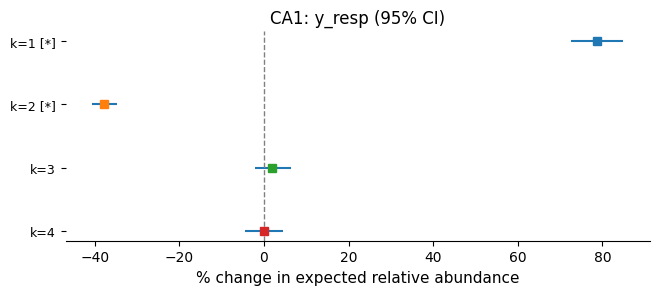

[saved] ca1_mom_vs_fixed/moments/effects_y_score.csv
[saved] ca1_mom_vs_fixed/moments/forest_y_score.png


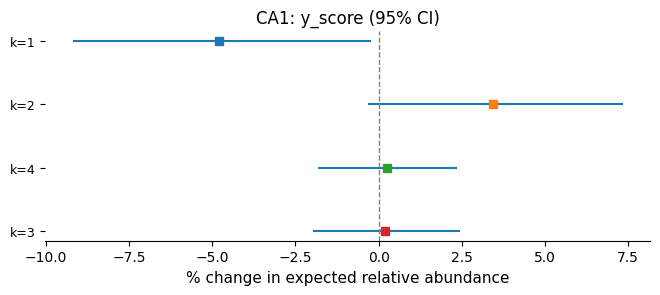

[filter] Retained 4 communities for testing after filtering.
[saved] ca1_mom_vs_fixed/fixed/effects_y_resp.csv
[saved] ca1_mom_vs_fixed/fixed/forest_y_resp.png


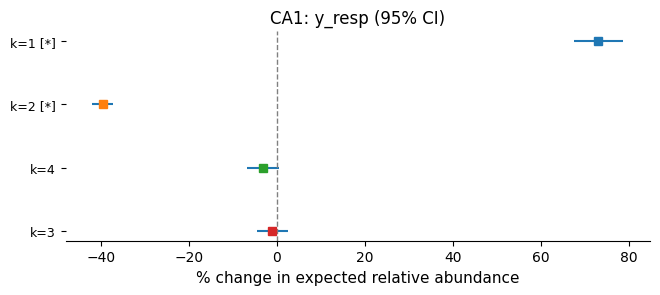

[saved] ca1_mom_vs_fixed/fixed/effects_y_score.csv
[saved] ca1_mom_vs_fixed/fixed/forest_y_score.png


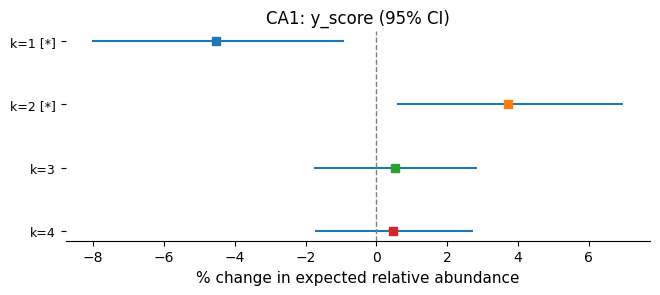


=== MoM (fitted α) vs Fixed-α comparison for term y_resp ===
  community  alpha_hat  coef_mom    se_mom          q_mom  coef_fix    se_fix  \
0       k=1   0.000008  0.580367  0.017649  1.454920e-236  0.548185  0.016447   
1       k=2   0.000000 -0.473538  0.024212   7.072331e-85 -0.504380  0.020346   
2       k=3   0.000000  0.019426  0.021218   4.798905e-01 -0.010763  0.018566   
3       k=4   0.000000 -0.001104  0.023128   9.619323e-01 -0.033042  0.019741   

           q_fix  se_ratio_mom_over_fix  disagree  
0  5.536643e-243               1.073068     False  
1  2.278276e-135               1.190032     False  
2   5.621238e-01               1.142814     False  
3   1.255589e-01               1.171590     False  


In [ ]:
# =================================================================================================
# CA1 (Community Abundance Analysis): compositional handling + MoM vs fixed alpha
# =================================================================================================
# Requires: numpy, pandas, matplotlib, statsmodels, patsy, scipy
#
# New in this version:
#   - handle_collinearity: {"none","auto","deviation","reference"}
#       * "auto": detect rows summing to n and apply "deviation"
#       * "deviation": center target effects across communities to sum to zero
#         (with conservative SE/CI/p adjustment)
#       * "reference": report effects vs a reference community (auto = most abundant)
#
# Keeps:
#   - Original fixed-alpha GLM helper + docstring
#   - Stable per-community dispersion via Method-of-Moments (MoM) + GLM NB
#   - Diagnostics comparing MoM vs fixed on the same data
# =================================================================================================

import os
from typing import List, Dict, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrices
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm


# =============================================================================
# Helper (kept): Fit Negative Binomial GLM with offset log(n) and fixed alpha
# =============================================================================
def _fit_nb_glm_one_formula(
    df: pd.DataFrame,
    formula: str,
    offset_col: str = "n",
    cov_type: str = "HC1",
    alpha: float = 1.0
):
    """
    Fit a single Negative Binomial GLM using statsmodels.

    Intuition:
    ----------
    - Each community count c_k is modeled as:
        c_k ~ NegBin(mu, alpha)
    - With log(mu) = linear predictor + log(n) offset
      where n = total bag size.
    - The offset ensures we model *relative abundance*
      rather than absolute counts.

    Parameters
    ----------
    df : DataFrame
        Data with counts, targets, and covariates.
        Actionable: Must contain the response column referenced on the left-hand side of
        `formula`, all predictors on the right-hand side, and the `offset_col`. Missing values
        should be handled upstream (drop/impute) to avoid fitting errors.

    formula : str
        Patsy formula (e.g., "c_1 ~ y_resp + age + site").
        Actionable: Ensure the left-hand side is a **single** community count column (e.g., "c_7").
        Use `C(var)` in your data prep or cast categorical predictors to category dtype.

    offset_col : str, default="n"
        Column name with bag total size (log used as offset).
        Actionable: Values must be ≥1; zeros are automatically clamped to 1 to avoid log(0).

    cov_type : {"nonrobust","HC0","HC1","HC2","HC3"}, default="HC1"
        Covariance estimator for robust standard errors.
        Actionable: Keep "HC1" for general use; consider cluster-robust SEs (not implemented here)
        if you have repeated measures per bag.

    alpha : float, default=1.0
        Dispersion parameter for Negative Binomial (fixes variance scaling).
        Actionable: Use 0.0 to recover a Poisson GLM; set to ~0.5–1.0 for mild overdispersion,
        or estimate α per community via the MoM path elsewhere.

    Returns
    -------
    res : statsmodels GLMResults
        Fitted model object with coef/SE/CI/p for all RHS terms (except Intercept).

    Notes
    -----
    • This routine does **not** estimate alpha; it **uses** the provided alpha.
    • If you need per-community dispersion, use the MoM estimator + `fit_nb_glm_with_alpha`.
    """
    model = smf.glm(
        formula=formula,
        data=df,
        family=sm.families.NegativeBinomial(alpha=alpha),
        offset=np.log(df[offset_col].clip(lower=1).values)  # avoid log(0)
    )
    res = model.fit(cov_type=cov_type)
    return res


# =============================================================================
# Stable per-community alpha estimation via Method-of-Moments (MoM)
# =============================================================================
def estimate_nb_alpha_moments(
    df: pd.DataFrame,
    formula: str,
    offset_col: str = "n",
    winsor: float = 0.98,
    min_mu: float = 1e-8,
) -> Tuple[float, np.ndarray]:
    """
    Estimate NB2 dispersion alpha using a Poisson GLM mean, then Pearson residuals (MoM).

    Steps:
    1) Fit Poisson GLM with log(exposure) offset to get mu-hat.
    2) Compute Pearson residuals: r_i^2 = (y_i - mu_i)^2 / mu_i.
    3) Method-of-moments for NB2: E[r_i^2] ≈ 1 + alpha * mu_i
       ⇒ alpha_hat ≈ mean(clip(r_i^2, q_{winsor}) - 1) / mean(mu_i).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the response and predictors identified by `formula` and `offset_col`.
        Actionable: Clean NA values prior to calling; ensure `offset_col` is present and ≥1.

    formula : str
        Patsy formula with a **single** response (e.g., "c_7 ~ y + covs").
        Actionable: Use the same RHS you will use for the NB fit (target + covariates).

    offset_col : str, default="n"
        Exposure column name (bag size).
        Actionable: Must be positive; zeros are automatically clamped to 1 for the log-offset.

    winsor : float in (0,1), default=0.98
        Upper-quantile clip for r_i^2 to reduce the influence of extreme outliers.
        Actionable: Increase to 0.995 if your data have occasional spiky bags; decrease to 0.95
        if you want less robustification.

    min_mu : float, default=1e-8
        Lower bound for fitted means μ_i to avoid numerical divisions by ~0.
        Actionable: Leave at default unless you encounter numerical warnings.

    Returns
    -------
    alpha_hat : float
        Estimated dispersion (≥0). If ≈0, data are consistent with Poisson variance.

    mu_hat : np.ndarray
        The fitted Poisson means (useful for diagnostics).

    Practical guidance
    ------------------
    • If alpha_hat ≈ 0 across many communities, Poisson is likely sufficient.
    • If alpha_hat > 0, carry it into the NB GLM via `fit_nb_glm_with_alpha` for calibrated SEs.
    """
    y_df, X_df = dmatrices(formula, df, return_type="dataframe")
    y = np.asarray(y_df).ravel()
    exposure = df[offset_col].clip(lower=1).to_numpy()

    pois = sm.GLM(y, X_df, family=sm.families.Poisson(), exposure=exposure).fit()
    mu = np.maximum(pois.fittedvalues.values, min_mu)

    r2 = (y - mu) ** 2 / mu
    q = np.quantile(r2, winsor)
    r2_w = np.minimum(r2, q)
    w = np.ones_like(mu)

    num = np.sum((r2_w - 1.0) * w)
    den = np.sum(mu * w)
    alpha_hat = float(np.clip(num / den if den > 0 else 0.0, a_min=0.0, a_max=np.inf))
    return alpha_hat, mu


def fit_nb_glm_with_alpha(
    df: pd.DataFrame,
    formula: str,
    offset_col: str,
    alpha_hat: float,
    cov_type: str = "HC1",
    refit_once: bool = True,
    min_mu: float = 1e-8,
):
    """
    Fit GLM-NegativeBinomial with a given alpha; optionally refit once with updated mu.

    Why:
    ----
    Fixing α to a MoM estimate avoids NB MLE numerical issues while still honoring
    overdispersion at the community level.

    Parameters
    ----------
    df : pd.DataFrame
        Bag-level dataset including response, predictors, and `offset_col`.
        Actionable: Pre-clean NA, ensure integer counts for the response.

    formula : str
        Patsy formula with a **single** community response (e.g., "c_3 ~ y + covs").
        Actionable: Match exactly the RHS used for MoM estimation for consistency.

    offset_col : str
        Exposure column name (e.g., "n").
        Actionable: Values must be ≥1; zeros are clamped internally to 1.

    alpha_hat : float
        Pre-estimated dispersion (≥0). If 0, this effectively becomes Poisson.
        Actionable: Use `estimate_nb_alpha_moments` per community to get this.

    cov_type : {"nonrobust","HC0","HC1","HC2","HC3"}, default="HC1"
        Sandwich covariance type for SEs.
        Actionable: Keep "HC1" unless you need a different small-sample correction.

    refit_once : bool, default=True
        If True, recompute a MoM α from the first NB fit’s μ, then refit NB once.
        Actionable: Keep True for extra stability; set False for speed.

    min_mu : float, default=1e-8
        Lower bound on fitted means when recomputing residuals.
        Actionable: Leave at default unless encountering numerical issues.

    Returns
    -------
    res : GLMResults (NegativeBinomial)
        Fitted NB GLM result with coef/SE/CI/p for RHS terms (except Intercept).

    Notes
    -----
    • This function does **not** change model terms or design; it only sets α.
    • If the first fit yields μ very close to zero for many rows, consider raising `min_mu`.
    """
    model = smf.glm(
        formula=formula,
        data=df,
        family=sm.families.NegativeBinomial(alpha=max(alpha_hat, 1e-12)),
        offset=np.log(df[offset_col].clip(lower=1).values)
    )
    res = model.fit(cov_type=cov_type)

    if not refit_once:
        return res

    mu1 = np.maximum(res.fittedvalues.values, min_mu)
    y = df[formula.split("~")[0].strip()].values
    r2 = (y - mu1) ** 2 / mu1
    num = np.sum(r2 - 1.0)
    den = np.sum(mu1)
    alpha2 = float(np.clip(num / den if den > 0 else 0.0, 0.0, np.inf))

    model2 = smf.glm(
        formula=formula,
        data=df,
        family=sm.families.NegativeBinomial(alpha=max(alpha2, 1e-12)),
        offset=np.log(df[offset_col].clip(lower=1).values)
    )
    res2 = model2.fit(cov_type=cov_type)
    return res2


# =============================================================================
# Compositionality handling helpers
# =============================================================================
def _detect_collinearity(
    df: pd.DataFrame,
    kept_cols: List[str],
    offset_col: str,
    r2_threshold: float = 0.999,      # near-compositionality if R^2 of sumC ~ n exceeds this
    rel_err_thresh: float = 1e-3,     # or mean relative error below this
    cond_threshold: float = 1e10      # condition number threshold for near-singularity
) -> Tuple[bool, str]:
    """
    Detect (near-)collinearity between community counts and the total n.

    Returns
    -------
    (flag, reason) : (bool, str)
        flag   = True if exact or near collinearity is detected
        reason = "exact", "r2", "relerr", or "condition" to indicate what triggered it

    Actionable guidance
    -------------------
    • If True, treat as compositional for coding purposes ("deviation" or "reference").
    • Tighten/loosen thresholds depending on dataset size/noise (see parameters below).

    Parameters
    ----------
    df : pd.DataFrame
        Must include kept community columns and `offset_col`.

    kept_cols : list[str]
        Community count columns considered (post-filtering).

    offset_col : str
        Name of total bag size column.

    r2_threshold : float, default=0.999
        If R^2 of sum_counts ~ n exceeds this, flag near-collinearity.

    rel_err_thresh : float, default=1e-3
        If mean(|sum_counts - n| / max(n,1)) ≤ this, flag near-collinearity.

    cond_threshold : float, default=1e10
        If the (scaled) design has condition number above this, flag near-singularity.
    """
    import numpy as np

    # 1) Exact compositionality (your original check).
    sum_counts = df[kept_cols].sum(axis=1).to_numpy()
    nvec = df[offset_col].to_numpy()
    exact = np.allclose(sum_counts, nvec, rtol=1e-6, atol=1e-6)
    if exact:
        return True, "exact"

    # 2) Near-equality: R^2 of sum_counts ~ n close to 1
    x = nvec.astype(float)
    y = sum_counts.astype(float)
    xm = x - x.mean()
    ym = y - y.mean()
    ssx = np.sum(xm * xm)
    ssy = np.sum(ym * ym)
    r2 = (np.sum(xm * ym) ** 2) / (ssx * ssy + 1e-12) if ssx > 0 and ssy > 0 else 0.0
    if r2 >= r2_threshold:
        return True, "r2"

    # 3) Mean relative error small
    denom = np.maximum(nvec, 1.0)
    rel_err = np.mean(np.abs(sum_counts - nvec) / denom)
    if rel_err <= rel_err_thresh:
        return True, "relerr"

    # 4) Condition number of [counts | n] (scaled) is huge → near-singularity
    #    Center/scale columns to avoid trivial scale-driven condition inflation.
    X = df[kept_cols + [offset_col]].to_numpy(dtype=float)
    Xc = X - np.nanmean(X, axis=0, keepdims=True)
    scale = np.nanstd(Xc, axis=0, ddof=1, keepdims=True)
    scale[scale == 0] = 1.0
    Xcs = Xc / scale
    # cond = ratio of largest to smallest singular value
    u, s, vT = np.linalg.svd(Xcs, full_matrices=False)
    cond = (s[0] / (s[-1] + 1e-12)) if s.size > 1 else np.inf
    if cond >= cond_threshold:
        return True, "condition"

    return False, "none"


def _apply_deviation_coding(effects: pd.DataFrame, term: str) -> pd.DataFrame:
    """
    Center the term's coefficients across communities (sum-to-zero coding).

    Parameters
    ----------
    effects : pd.DataFrame
        Output rows from the per-community fits for one target (mix of terms).

    term : str
        The target/predictor whose effects need centering (e.g., "y_resp").

    Returns
    -------
    pd.DataFrame
        Effects with the given term’s coefficients centered across communities and
        SE/CI/p updated via a conservative variance-centering approximation.

    Actionable guidance
    -------------------
    • Use this when counts are compositional (rows sum to n).
    • Interpretation: positive values indicate communities that increase relative
      to the average community as the term increases, and vice versa.
    """
    ef = effects.copy()
    m = ef["term"] == term
    if not m.any():
        return ef

    beta = ef.loc[m, "coef_log"].to_numpy()
    se = ef.loc[m, "se"].to_numpy()
    K = len(beta)

    beta_c = beta - np.nanmean(beta)

    # Approximate variance adjustment (no covariances available):
    # Var(centered_i) ≈ Var_i * (1 - 2/K) + mean(Var)/K
    var = se ** 2
    mean_var = np.nanmean(var)
    var_c = var * (1.0 - 2.0 / K) + (mean_var / K)
    var_c = np.clip(var_c, 0.0, np.inf)
    se_c = np.sqrt(var_c)

    # Recompute Wald z, p, CI (normal)
    z = np.divide(beta_c, se_c, out=np.zeros_like(beta_c), where=se_c > 0)
    p = 2 * norm.sf(np.abs(z))
    zcrit = norm.ppf(0.975)
    lo = beta_c - zcrit * se_c
    hi = beta_c + zcrit * se_c

    ef.loc[m, "coef_log"] = beta_c
    ef.loc[m, "se"] = se_c
    ef.loc[m, "p"] = p
    ef.loc[m, "ci_lo"] = lo
    ef.loc[m, "ci_hi"] = hi
    ef.loc[m, "exp_coef"] = np.exp(beta_c)
    ef.loc[m, "exp_ci_lo"] = np.exp(lo)
    ef.loc[m, "exp_ci_hi"] = np.exp(hi)
    ef.loc[m, "percent_change"] = (ef.loc[m, "exp_coef"] - 1.0) * 100.0
    ef.loc[m, "coding"] = "deviation"
    return ef


def _apply_reference_coding(effects: pd.DataFrame, term: str, ref_response: str) -> pd.DataFrame:
    """
    Express term effects relative to a reference community response (e.g., 'c_3').

    Parameters
    ----------
    effects : pd.DataFrame
        Output rows from the per-community fits for one target (mix of terms).

    term : str
        The target/predictor to re-express (e.g., "y_resp").

    ref_response : str
        The response column name to use as the reference (e.g., "c_3").

    Returns
    -------
    pd.DataFrame
        Effects where the selected term is transformed to β_k - β_ref on log-scale,
        with SE/CI/p via independent-difference approximation (conservative).

    Actionable guidance
    -------------------
    • Choose a **stable, abundant** reference (or let the caller auto-pick).
    • Interpretation becomes “fold-change versus reference community.”
    • The reference row itself is set to 0 (log-scale) with NA SE/CI/p.
    """
    ef = effects.copy()
    m = ef["term"] == term
    if not m.any():
        return ef

    # rows for target term
    E = ef.loc[m].copy()
    # find ref row
    ref_row = E[E["response"] == ref_response]
    if ref_row.empty:
        # nothing to do if reference not present
        return ef

    ref_beta = float(ref_row["coef_log"].iloc[0])
    ref_se = float(ref_row["se"].iloc[0])
    ref_var = ref_se ** 2

    # compute diffs for all (including ref → set to 0 with NA inferential stats)
    diffs = E["coef_log"].values - ref_beta
    var_diff = (E["se"].values ** 2) + ref_var  # ignore covariance (conservative)
    se_diff = np.sqrt(np.clip(var_diff, 0.0, np.inf))

    # fill back
    ef.loc[E.index, "coef_log"] = diffs
    ef.loc[E.index, "se"] = se_diff
    z = np.divide(diffs, se_diff, out=np.zeros_like(diffs), where=se_diff > 0)
    p = 2 * norm.sf(np.abs(z))
    zcrit = norm.ppf(0.975)
    lo = diffs - zcrit * se_diff
    hi = diffs + zcrit * se_diff

    ef.loc[E.index, "p"] = p
    ef.loc[E.index, "ci_lo"] = lo
    ef.loc[E.index, "ci_hi"] = hi
    ef.loc[E.index, "exp_coef"] = np.exp(diffs)
    ef.loc[E.index, "exp_ci_lo"] = np.exp(lo)
    ef.loc[E.index, "exp_ci_hi"] = np.exp(hi)
    ef.loc[E.index, "percent_change"] = (ef.loc[E.index, "exp_coef"] - 1.0) * 100.0
    ef.loc[E.index, "coding"] = f"reference:{ref_response}"

    # For the reference itself: set estimate to exactly 0 and mark p/CI appropriately
    ef.loc[(ef["term"] == term) & (ef["response"] == ref_response), ["coef_log", "se"]] = [0.0, np.nan]
    ef.loc[(ef["term"] == term) & (ef["response"] == ref_response), ["p", "ci_lo", "ci_hi",
                                                                     "exp_coef", "exp_ci_lo", "exp_ci_hi",
                                                                     "percent_change"]] = [np.nan, np.nan, np.nan,
                                                                                           1.0, np.nan, np.nan, 0.0]
    return ef


# =============================================================================
# CA1 main (supports "moments" for fitted alpha or "fixed" for fixed alpha)
# =============================================================================
def fit_ca1_multi_targets(
    df: pd.DataFrame,
    K: int,
    target_cols: List[str],
    covariates: Optional[List[str]] = None,
    offset_col: str = "n",
    cov_type: str = "HC1",
    handle_collinearity: str = "auto",  # "none","auto","deviation","reference"
    reference_response: Optional[str] = None,  # e.g., "c_3"; if None and reference mode, pick most abundant
    ci_level: float = 0.95,
    outdir: Optional[str] = None,
    plot: bool = True,
    scale: str = "percent",   # "percent" or "ratio"
    min_total: int = 10,
    min_bags: int = 1,
    dispersion_mode: str = "moments",   # "moments" (per-community MoM alpha) or "fixed"
    alpha_fixed: float = 1.0
) -> Dict[str, pd.DataFrame]:
    """
    Fit CA1 (Community Abundance analysis) for multiple bag-level targets.

    Intuition
    ---------
    For each target and each community (neighborhood), regress the community's
    counts on the target + covariates with a log(n) offset so effects are on
    *relative abundance*. This function supports:
      - Per-community dispersion estimation ("moments"): robust MoM + GLM NB.
      - Fixed-alpha GLM ("fixed"): faster and mirrors a global-α approach.
      - Compositional collinearity handling ("auto","deviation","reference"): post-hoc
        reparameterization of the target effect across communities to respect unit-sum.

    Parameters
    ----------
    df : pd.DataFrame
        Bag-level data with:
          • "n" (offset/exposure), ≥1
          • Community count columns "c_1..c_K" (subset OK)
          • All `target_cols` and `covariates`
        Actionable: Ensure counts are non-negative integers; drop/impute NAs before fitting.

    K : int
        Maximum community index (defines expected columns up to c_K).
        Actionable: You can pass a larger K than observed; function filters to present columns.

    target_cols : list[str]
        Names of target variables to test (e.g., ["y_resp", "y_score"]).
        Actionable: Binary targets should be 0/1; for multi-level factors, encode dummies or use C() upstream.

    covariates : list[str] or None, default=None
        Extra RHS predictors (e.g., ["age", "C(site)"]).
        Actionable: Cast categorical covariates to category dtype or pre-dummy them.

    offset_col : str, default="n"
        Exposure column used as log-offset.
        Actionable: Must be ≥1; zeros are clamped internally to 1.

    cov_type : {"nonrobust","HC0","HC1","HC2","HC3"}, default="HC1"
        Robust SE type.
        Actionable: Keep "HC1" unless you have a reason to change small-sample corrections.

    handle_collinearity : {"none","auto","deviation","reference"}, default="auto"
        Strategy for the **unit-sum** dependency across communities.
        - "auto": detect compositional rows (sum c_k ≈ n); if True → "deviation", else "none".
        - "deviation": center target coefficients across communities (sum-to-zero).
        - "reference": re-express as differences vs one reference community.
        - "none": no special handling.
        Actionable: Keep "auto" for safety; switch to "reference" if a specific baseline is desired.

    reference_response : str or None, default=None
        When using "reference", which community column (e.g., "c_3") to use as baseline.
        Actionable: If None, the most abundant community (by total counts) is auto-selected.

    ci_level : float in (0,1), default=0.95
        Wald confidence level.
        Actionable: Use 0.90 for exploratory screens; 0.99 for strict confirmatory analysis.

    outdir : str or None, default=None
        Directory to write CSV and plots. None = do not save to disk.
        Actionable: Provide a path to persist both per-target effects and forest plots.

    plot : bool, default=True
        If True, produce a forest plot per target.
        Actionable: Disable in non-interactive/CI runs.

    scale : {"percent","ratio"}, default="percent"
        Forest-plot display scale.
        Actionable: "percent" shows (exp(coef)-1)*100; "ratio" shows exp(coef).

    min_total : int, default=10
        Minimum total counts (across all bags) to retain a community.
        Actionable: Increase (e.g., 20–50) in large datasets to avoid tiny/noisy communities.

    min_bags : int, default=1
        Minimum number of bags with >0 counts to keep a community.
        Actionable: Use 2–3 in small studies to reduce quasi/separation issues.

    dispersion_mode : {"moments","fixed"}, default="moments"
        How to set dispersion α.
        - "moments": estimate α per community via `estimate_nb_alpha_moments`, then fit NB with it.
        - "fixed"  : fit NB with a global α = `alpha_fixed`.
        Actionable: Prefer "moments"; use "fixed" for speed or benchmarking (α=0 → Poisson).

    alpha_fixed : float, default=1.0
        Global α used when `dispersion_mode="fixed"`.
        Actionable: Set 0.0 for Poisson baseline, or 0.5–1.0 for mild overdispersion.

    Returns
    -------
    results_by_target : dict[str, pd.DataFrame]
        Per-target effects table with columns:
        ["target","community","response","term","coef_log","se","p","ci_lo","ci_hi",
         "exp_coef","exp_ci_lo","exp_ci_hi","percent_change","dispersion_alpha",
         "converged","nobs","q","significant","coding" (if applied)]

    Practical guidance
    ------------------
    • If many α estimates are ≈0, Poisson is adequate (tighter CIs).
    • Use deviation coding whenever counts are compositional to avoid spurious global shifts.
    • Always inspect diagnostics: dropped communities, convergence messages, CI widths.
    """
    if covariates is None:
        covariates = []
    if outdir:
        os.makedirs(outdir, exist_ok=True)

    # Filter rare communities
    all_count_cols = [f"c_{k}" for k in range(1, K + 1)]
    count_cols = [c for c in all_count_cols if c in df.columns]
    if len(count_cols) == 0:
        raise ValueError("No community count columns found (expected c_1..c_K).")

    totals = df[count_cols].sum(axis=0)
    presence = (df[count_cols] > 0).sum(axis=0)
    keep_mask = (totals >= min_total) & (presence >= min_bags)

    dropped = [c for c, keep in zip(count_cols, keep_mask) if not keep]
    if dropped:
        print(f"[filter] Dropping {len(dropped)} low-membership communities: {dropped}")
    kept_cols = [c for c in count_cols if c not in dropped]
    print(f"[filter] Retained {len(kept_cols)} communities for testing after filtering.")
    if len(kept_cols) == 0:
        raise ValueError("All communities dropped by filters; relax 'min_total'/'min_bags'.")

    # Decide compositionality handling mode
    if handle_collinearity not in {"none", "auto", "deviation", "reference"}:
        raise ValueError("handle_collinearity must be one of {'none','auto','deviation','reference'}")

    flag, why = _detect_collinearity(df, kept_cols, offset_col)
    if handle_collinearity == "auto":
        comp_mode = "deviation" if flag else "none"
        print(f"[info] Collinearity check → {why}; mode = {comp_mode}")
    else:
        comp_mode = handle_collinearity


    results_by_target: Dict[str, pd.DataFrame] = {}

    for target in target_cols:
        rhs_terms = [target] + list(covariates)
        rhs = " + ".join(rhs_terms) if rhs_terms else "1"

        rows = []
        for idx_k, response in enumerate(kept_cols, start=1):
            formula = f"{response} ~ {rhs}"

            try:
                if dispersion_mode == "moments":
                    alpha_hat, _ = estimate_nb_alpha_moments(df, formula, offset_col=offset_col)
                    res = fit_nb_glm_with_alpha(
                        df=df, formula=formula, offset_col=offset_col,
                        alpha_hat=alpha_hat, cov_type=cov_type, refit_once=True
                    )
                elif dispersion_mode == "fixed":
                    res = _fit_nb_glm_one_formula(df, formula, offset_col, cov_type, alpha_fixed)
                    alpha_hat = float(alpha_fixed)
                else:
                    raise ValueError("dispersion_mode must be 'moments' or 'fixed'.")

                params = res.params
                bse = res.bse
                conf = res.conf_int(alpha=1 - ci_level)
                conf.columns = ["ci_lo", "ci_hi"]
                pvals = res.pvalues
                converged = True
                nobs = res.nobs

            except Exception:
                rows.append({
                    "target": target, "community": f"k={idx_k}", "response": response,
                    "term": "FIT_FAILED", "coef_log": np.nan, "se": np.nan, "p": np.nan,
                    "ci_lo": np.nan, "ci_hi": np.nan, "exp_coef": np.nan,
                    "exp_ci_lo": np.nan, "exp_ci_hi": np.nan, "percent_change": np.nan,
                    "dispersion_alpha": np.nan, "converged": False, "nobs": df.shape[0],
                })
                continue

            for term in params.index:
                if term == "Intercept":
                    continue
                coef = float(params.get(term, np.nan))
                se = float(bse.get(term, np.nan))
                pval = float(pvals.get(term, np.nan))
                ci_lo = float(conf.loc[term, "ci_lo"]) if term in conf.index else np.nan
                ci_hi = float(conf.loc[term, "ci_hi"]) if term in conf.index else np.nan

                rows.append({
                    "target": target, "community": f"k={idx_k}", "response": response,
                    "term": term, "coef_log": coef, "se": se, "p": pval,
                    "ci_lo": ci_lo, "ci_hi": ci_hi,
                    "exp_coef": np.exp(coef) if np.isfinite(coef) else np.nan,
                    "exp_ci_lo": np.exp(ci_lo) if np.isfinite(ci_lo) else np.nan,
                    "exp_ci_hi": np.exp(ci_hi) if np.isfinite(ci_hi) else np.nan,
                    "percent_change": (np.exp(coef) - 1.0) * 100.0 if np.isfinite(coef) else np.nan,
                    "dispersion_alpha": alpha_hat, "converged": converged, "nobs": nobs,
                })

        effects = pd.DataFrame(rows)

        # --- Compositional coding (post-hoc on the 'target' term across communities)
        if comp_mode == "deviation":
            effects = _apply_deviation_coding(effects, term=target)

        elif comp_mode == "reference":
            # Pick reference response if not provided: most abundant community overall
            if reference_response is None:
                total_by_resp = df[kept_cols].sum(axis=0).sort_values(ascending=False)
                reference_response = total_by_resp.index[0]
                print(f"[info] Reference community auto-selected: {reference_response}")
            effects = _apply_reference_coding(effects, term=target, ref_response=reference_response)

        # --- BH-FDR correction per term (after coding)
        effects["q"] = np.nan
        effects["significant"] = False
        for term_name, grp in effects.groupby("term", sort=False):
            if term_name == "FIT_FAILED":
                continue
            # drop rows with NaN p (e.g., reference line), but preserve their rows
            valid = np.isfinite(grp["p"].values)
            if valid.sum() == 0:
                continue
            rej, qvals, _, _ = multipletests(grp["p"].values[valid], method="fdr_bh")
            effects.loc[grp.index[valid], "q"] = qvals
            effects.loc[grp.index[valid], "significant"] = rej

        if outdir:
            csv_path = os.path.join(outdir, f"effects_{target}.csv")
            effects.to_csv(csv_path, index=False)
            print(f"[saved] {csv_path}")

        if plot:
            forest_plot_publication(
                effects=effects,
                term=target,
                ci_level=ci_level,
                title=f"CA1: {target}",
                scale=scale,
                sort_by_abs=True,
                outpath=os.path.join(outdir, f"forest_{target}.png") if outdir else None
            )

        results_by_target[target] = effects

    return results_by_target


# =============================================================================
# Forest plot
# =============================================================================
def forest_plot_publication(
    effects: pd.DataFrame,
    term: str,
    ci_level: float = 0.95,
    title: str = "",
    scale: str = "percent",    # "percent" or "ratio"
    sort_by_abs: bool = True,
    top_C: Optional[int] = 20,
    outpath: Optional[str] = None
):
    """
    Draw a compact forest plot of a single term's effects across communities.

    Parameters
    ----------
    effects : pd.DataFrame
        Output from `fit_ca1_multi_targets` for a given target.

    term : str
        The predictor to visualize (e.g., "y_resp").

    ci_level : float in (0,1), default=0.95
        Displayed confidence level for intervals.
        Actionable: Keep consistent with the model's CI level for clarity.

    title : str, default=""
        Plot title text.

    scale : {"percent","ratio"}, default="percent"
        X-axis scale:
        • "percent" → (exp(coef)-1)*100
        • "ratio"   → exp(coef)
        Actionable: Use "percent" for readability; "ratio" for direct multiplicative effects.

    sort_by_abs : bool, default=True
        If True, sort rows by |effect| descending to surface the largest effects first.

    top_C : int or None, default=20
        If not None, show only the top C communities by |effect| (after sorting).
        Actionable: Increase for larger panels; set None to show all.

    outpath : str or None, default=None
        If provided, save the figure to this path (PNG). Nothing is saved if None.

    Notes
    -----
    • Significant results (FDR-adjusted) are indicated in the labels if you add such markers upstream.
    • This is a compact, publication-friendly plot; customize as needed for your pipeline.
    """
    df = effects.loc[effects["term"] == term].copy()
    if df.empty:
        print(f"[warn] No rows for term '{term}'")
        return

    if scale == "percent":
        df["effect"] = (df["exp_coef"] - 1.0) * 100
        df["ci_lo_plot"] = (df["exp_ci_lo"] - 1.0) * 100
        df["ci_hi_plot"] = (df["exp_ci_hi"] - 1.0) * 100
        ref_line = 0.0
        x_label = "% change in expected relative abundance"
    elif scale == "ratio":
        df["effect"] = df["exp_coef"]
        df["ci_lo_plot"] = df["exp_ci_lo"]
        df["ci_hi_plot"] = df["exp_ci_hi"]
        ref_line = 1.0
        x_label = "Multiplicative effect on expected relative abundance"
    else:
        raise ValueError("scale must be 'percent' or 'ratio'")

    if sort_by_abs:
        df = df.reindex(df["effect"].abs().sort_values(ascending=False).index)
    else:
        df = df.sort_values("community")

    if top_C is not None and len(df) > top_C:
        df = df.head(top_C)

    df["label"] = df["community"] + df["significant"].map(lambda x: " [*]" if x else "")
    y_pos = np.arange(len(df))

    fig, ax = plt.subplots(figsize=(6.7, 0.44 * len(df) + 1.3))
    for i, row in enumerate(df.itertuples(index=False)):
        ax.hlines(y=y_pos[i], xmin=row.ci_lo_plot, xmax=row.ci_hi_plot, lw=1.5)
        ax.plot(row.effect, y_pos[i], "s", markersize=6, zorder=3)

    ax.axvline(ref_line, linestyle="--", color="gray", lw=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df["label"].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_title(f"{title} ({int(ci_level*100)}% CI)", fontsize=12)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.8)

    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"[saved] {outpath}")
    plt.show()


# =============================================================================
# Diagnostics: compare MoM vs fixed-alpha on the same term
# =============================================================================
def compare_moments_vs_fixed(eff_mom: pd.DataFrame, eff_fix: pd.DataFrame, term: str) -> pd.DataFrame:
    """
    Compare per-community effects between MoM-α fits and fixed-α fits for one term.

    Parameters
    ----------
    eff_mom : pd.DataFrame
        Effects DataFrame for a target produced by `fit_ca1_multi_targets` with
        `dispersion_mode="moments"`.

    eff_fix : pd.DataFrame
        Effects DataFrame for the same target produced with `dispersion_mode="fixed"`.

    term : str
        The predictor to compare (e.g., "y_resp").

    Returns
    -------
    pd.DataFrame
        A merged table with columns:
        ["community","response","alpha_hat","coef_mom","se_mom","p_mom","q_mom",
         "coef_fix","se_fix","p_fix","q_fix","se_ratio_mom_over_fix",
         "agree_significant","disagree"]

    Actionable guidance
    -------------------
    • Inspect `alpha_hat`—if many 0’s, Poisson suffices.
    • `se_ratio_mom_over_fix` > 1 implies MoM-α increased uncertainty (more conservative).
    • Use `disagree` to flag communities whose significance depends on α handling.
    """
    a = eff_mom.loc[eff_mom["term"] == term, ["community", "response", "coef_log", "se", "p", "q", "dispersion_alpha"]].copy()
    a = a.rename(columns={"coef_log": "coef_mom", "se": "se_mom", "p": "p_mom", "q": "q_mom", "dispersion_alpha": "alpha_hat"})
    b = eff_fix.loc[eff_fix["term"] == term, ["community", "response", "coef_log", "se", "p", "q"]].copy()
    b = b.rename(columns={"coef_log": "coef_fix", "se": "se_fix", "p": "p_fix", "q": "q_fix"})
    out = a.merge(b, on=["community", "response"], how="outer", validate="one_to_one")
    out["se_ratio_mom_over_fix"] = out["se_mom"] / out["se_fix"]
    out["agree_significant"] = (out["q_mom"] < 0.05) & (out["q_fix"] < 0.05)
    out["disagree"] = (out["q_mom"] < 0.05) ^ (out["q_fix"] < 0.05)
    return out


# =============================================================================
# Example: simulate Poisson-by-community (NOT compositional) and run
# =============================================================================
if __name__ == "__main__":
    rng = np.random.default_rng(123)

    # Poisson-by-community (NOT compositional)
    N, K = 150, 4
    n = rng.poisson(500, size=N).clip(min=50)
    y_resp = rng.integers(0, 2, size=N)
    y_score = rng.normal(0, 1, size=N)
    age = rng.normal(60, 10, size=N)
    site = rng.choice(list("ABC"), size=N)

    beta0 = np.array([-2.0, -2.2, -2.1, -2.3])
    betas = np.array([0.6, -0.5, 0.0, 0.0])  # k=1 positive, k=2 negative

    C = np.zeros((N, K), dtype=int)
    for k in range(K):
        eta = beta0[k] + y_resp * betas[k] + np.log(n)
        mu = np.exp(eta)
        C[:, k] = rng.poisson(mu)

    df = pd.DataFrame({
        "n": n,
        "c_1": C[:, 0], "c_2": C[:, 1], "c_3": C[:, 2], "c_4": C[:, 3],
        "y_resp": y_resp,
        "y_score": y_score,
        "age": age,
        "site": site
    })
    df["site"] = df["site"].astype("category")

    print(df.head())
    print("Row sums equal n? (compositional):",
          np.allclose(df[[f"c_{k}" for k in range(1, K+1)]].sum(axis=1), df["n"]))

    # -------------------------------------------------------------------------
    # Run CA1 on the SAME data: MoM (fitted alpha) vs Fixed-alpha
    #   and demonstrate compositionality handling switches
    # -------------------------------------------------------------------------
    outroot = "ca1_mom_vs_fixed"
    mom_dir = os.path.join(outroot, "moments")
    fix_dir = os.path.join(outroot, "fixed")

    # MoM with automatic compositional handling (will detect 'False' here and do nothing)
    results_mom = fit_ca1_multi_targets(
        df=df, K=K, target_cols=["y_resp", "y_score"],
        covariates=None, offset_col="n",
        cov_type="HC1", outdir=mom_dir, plot=True, scale="percent",
        min_total=10, min_bags=1,
        dispersion_mode="moments",
        handle_collinearity="auto"   # ← auto-detect & apply deviation only if compositional
    )

    # Fixed-alpha (α=1) with deviation coding forced (for demonstration)
    results_fixed = fit_ca1_multi_targets(
        df=df, K=K, target_cols=["y_resp", "y_score"],
        covariates=None, offset_col="n",
        cov_type="HC1", outdir=fix_dir, plot=True, scale="percent",
        min_total=10, min_bags=1,
        dispersion_mode="fixed", alpha_fixed=1.0,
        handle_collinearity="deviation"  # manually force deviation coding
    )

    # Compare MoM vs fixed for y_resp
    cmp = compare_moments_vs_fixed(results_mom["y_resp"], results_fixed["y_resp"], term="y_resp")
    print("\n=== MoM (fitted α) vs Fixed-α comparison for term y_resp ===")
    print(cmp[["community", "alpha_hat", "coef_mom", "se_mom", "q_mom",
               "coef_fix", "se_fix", "q_fix", "se_ratio_mom_over_fix", "disagree"]])

    # Tip: to test compositional behavior, switch generator to multinomial:
    #   - Draw probabilities via softmax(logits) per bag
    #   - Sample counts for each bag from Multinomial(n, p)
    # Then run with handle_collinearity="auto" or "deviation"/"reference"


### Experiment: Community Abundance Analysis with Exclusive Cluster Assignments

In this experiment, we simulate bags where each instance is assigned **exclusively** to one of four communities, mimicking a clustering or hard-partitioning scenario.  
The total number of instances per bag is drawn from a Poisson distribution, and a **binary outcome** (`y_resp`) is introduced that makes one community more abundant (positively associated) and another less abundant (negatively associated) in the positive class.  

To generate counts, we use a **multinomial sampling process**: for each bag, outcome-dependent logits are defined for the communities, converted to probabilities, and instances are sampled accordingly. This ensures that **all counts in a bag sum exactly to the bag size**, enforcing a compositional structure.  

The resulting dataset is analyzed using **CA1 (Community Abundance Model 1)**, which regresses each community’s count on the outcome (`y_resp`) while using the bag size as an offset. This setup highlights how CA1 detects enrichment and depletion in specific communities under exclusive clustering. Forest plots display the effect sizes as **% change in expected relative abundance**, allowing us to visually identify which communities are significantly linked to the outcome.


     n  c_1  c_2  c_3  c_4  y_resp        age site
0  411  101  106  120   84       0  43.037023    C
1  382  138   92   60   92       1  39.691390    B
2  379  154   83   70   72       1  71.095621    A
3  435  113  119  102  101       0  61.107198    A
4  401   95  101  109   96       0  64.101621    A
Row sums check: True
[filter] Retained 4 communities for testing after filtering.
[info] Collinearity check → exact; mode = deviation
[saved] ca1_results/effects_y_resp.csv
[saved] ca1_results/forest_y_resp.png


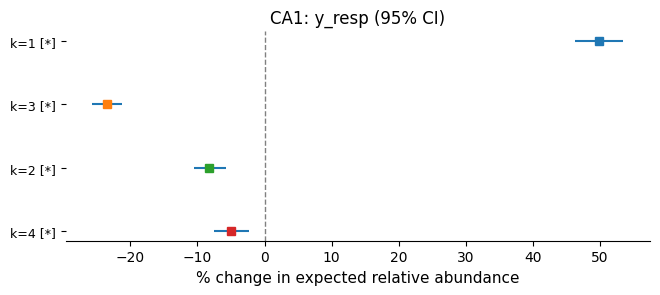

[saved] ca1_results/effects_y_score.csv
[warn] No rows for term 'y_score'


In [ ]:
if __name__ == "__main__":
    rng = np.random.default_rng(123)

    # Parameters
    N, K = 120, 4
    n = rng.poisson(400, size=N).clip(min=50)
    y_resp = rng.integers(0, 2, size=N)  # binary bag outcome
    age = rng.normal(60, 10, size=N)
    site = rng.choice(list("ABC"), size=N)

    # Choose which clusters have positive/negative dependence
    k_pos, k_neg = 1, 3   # (1-indexed for c_1..c_K)
    beta_pos, beta_neg = +0.5, -0.2      # effect strengths on logit scale

    counts = np.zeros((N, K), dtype=int)

    for i in range(N):
        # baseline logits for all K communities
        logits = np.zeros(K)

        # add outcome effect for positive and negative clusters
        logits[k_pos-1] = beta_pos * y_resp[i]
        logits[k_neg-1] = beta_neg * y_resp[i]

        # convert logits to probabilities
        exp_logits = np.exp(logits - np.max(logits))  # stability
        probs = exp_logits / exp_logits.sum()

        # draw assignments for each instance in bag i
        assignments = rng.choice(K, size=n[i], p=probs)
        for k in range(K):
            counts[i, k] = np.sum(assignments == k)

        # sanity check
        assert counts[i].sum() == n[i]

    # DataFrame
    df = pd.DataFrame({
        "n": n,
        "c_1": counts[:, 0], "c_2": counts[:, 1],
        "c_3": counts[:, 2], "c_4": counts[:, 3],
        "y_resp": y_resp,
        "age": age,
        "site": site
    })

    print(df.head())
    print("Row sums check:", np.allclose(df[[f"c_{k}" for k in range(1,K+1)]].sum(axis=1), df["n"]))

    # Run CA1
    results = fit_ca1_multi_targets(
        df=df,
        K=K,
        target_cols=["y_resp", "y_score"],
        covariates=None,#["age", "site"],
        handle_collinearity="auto",   # auto handles exclusive case
        outdir="ca1_results",
        #dispersion_mode="fixed", alpha_fixed=0.01,
        plot=True
    )


# 🧩 Building overlapping communities

This cell simulates **instance-level data grouped into bags**, builds a **k-nearest-neighbour (kNN) graph** in a reduced space, defines **overlapping neighborhoods (communities)** on that graph, aggregates them to the **bag** level, and finally runs a **Community Abundance Analysis (CA1)** regression.

The workflow reproduces a *differential abundance* scenario where a bag-level outcome (e.g., `y_resp`) alters the mixture of underlying latent regions.

---

## **1️⃣ Simulate Bags with Outcome-Dependent Latent Regions**

**Function:** `simulate_bags_da(cfg)`

Each simulated bag (`bag_id`) contains instances drawn from a mixture of well-separated Gaussian clusters in `ℝ^d`.  
The bag-level binary outcome `y_bag ∈ {0,1}` affects the **mixture weights**, producing **differential abundance** between regions.

**Outputs:**
- `inst_df` — instance-level DataFrame with `[bag_id, y, i_in_bag, x1..xd]`
- `X` — array of instance coordinates (used for kNN)
- `bag_ids` — maps each instance to its bag
- `y_bag` — array of bag-level outcomes

**Config parameters (in `SimConfig`):**
| Parameter | Meaning | Typical Range |
|------------|----------|---------------|
| `N_bags` | Number of bags | 50–500 |
| `mean_bag_size` | Mean number of instances per bag | 100–1000 |
| `bag_size_dispersion` | Controls bag size variability | 0.2–1.0 |
| `d` | Dimensionality of latent space | 5–20 |
| `n_regions` | Number of latent spatial regions | 4–12 |
| `sep` | Distance between region centers (cluster separation) | 2–5 |
| `sigma` | Within-region noise | 0.5–1.0 |
| `prop` | Fraction of vertices sampled as seeds for neighborhoods | 0.01–0.2 |
| `k` | k for kNN and neighborhood radius | 20–100 |
| `refinement_scheme` | `"reduced_dim"` (smooth manifold) or `"graph"` (dense core) | — |
| `seed` | RNG seed for reproducibility | any int |

---

## **2️⃣ Build the kNN Graph**

**Functions:**
- `knn_bruteforce(X, k)` — computes exact kNN indices for all instances (batched).
- `make_undirected_edge_list(knn_idx)` — removes duplicates to form undirected edges.
- `adjacency_lists(N, edges_i, edges_j)` — builds `{node: neighbors}` adjacency dictionary.

**Purpose:**  
Creates a fully connected geometric graph where each point’s local neighborhood structure is explicitly represented.

**Tuning:**
- Increase `k` for smoother, more connected graphs.
- Adjust `batch` to balance speed and memory for large N.

---

## **3️⃣ Define Overlapping Neighborhoods (Communities)**

**Functions:**
- `sample_vertices(N, prop, rng)` — randomly sample seed vertices.
- **Refinement:**  
  - `"reduced_dim"` → take the median of each seed’s kNN in `X`, then snap to the nearest real point (local medoid).  
  - `"graph"` → within the seed’s 1-hop ego, select the node with the most triangles (dense core).

**Output of `make_neighborhoods(...)`:**
- `knn_idx` — directed kNN indices  
- `adj` — undirected adjacency dictionary  
- `centers` — final refined neighborhood centers

Each neighborhood corresponds to a **1-hop ego network** around a chosen center.  
Overlapping neighborhoods mimic “communities” of locally similar instances.

---

## **4️⃣ Aggregate to Bag-Level Counts**

**Functions:**
- `neighborhoods_incidence(centers, adj)` — builds a long-form incidence table: (instance, neighborhood, membership).  
- `bag_level_counts_from_incidence(inc, bag_ids, K)` — sums membership per bag.

**Output:**  
A bag-level DataFrame with columns:
- `c_1, c_2, …, c_K` → counts per neighborhood  
- `n` → total bag size  

Each instance can belong to **multiple neighborhoods**, so counts can overlap.

---

## **5️⃣ Run Community Abundance Analysis (CA1)**

CA1 tests whether community-level relative abundances differ by bag-level outcome.

**Key idea:**  
For each community `k`, fit a Negative Binomial regression  
\[
c_k \sim \text{NB}(\mu, \alpha), \quad \log(\mu) = \text{predictors} + \log(n)
\]
where `n` is the bag size (offset), so coefficients measure **relative abundance** effects.

**Main function:** `fit_ca1_multi_targets(df, K, target_cols, covariates, ...)`

**Features:**
- `dispersion_mode="moments"` → estimates a per-community α via method-of-moments.  
- `dispersion_mode="fixed"` → uses fixed α (e.g., Poisson-like if α=0).  
- `handle_collinearity`:
  - `"auto"` → detects compositional counts (row sums ≈ n) and applies deviation coding.  
  - `"deviation"` → centers effects so they sum to zero across communities.  
  - `"reference"` → expresses effects relative to one reference community.  
  - `"none"` → no adjustment (assumes counts independent).

**Outputs:**
- DataFrame of effect estimates per community:
  - `coef_log`, `exp_coef`, `percent_change`, `se`, `p`, `q`, `dispersion_alpha`
- Optional forest plots of top community effects.

**Example:**
```python
results = fit_ca1_multi_targets(
    df=df.drop(columns=["bag_id"]),
    K=K_comm,
    target_cols=["y_resp"],
    covariates=None,
    handle_collinearity="auto",
    outdir=None,
    plot=True,
    scale="ratio",
    min_total=10,
    min_bags=0
)


[info] Simulated 8943 instances across 100 bags.
[info] Built 86 overlapping neighborhoods (communities).
   bag_id    n  c_1  c_2  c_3  c_4  c_5  c_6  c_7  c_8  ...  c_78  c_79  c_80  \
0       0  305    7   20   21    2   15    7    2    1  ...    30     5    23   
1       1   23    0    1    3    0    1    0    0    0  ...     0     0     0   
2       2  107    2    4   13    3    6    1    1    1  ...     2     7     0   
3       3  122    3    6   10    4    9    1    3    2  ...     5     4     3   
4       4  120    3   10   13    2   12    3    0    2  ...     7     8     6   

   c_81  c_82  c_83  c_84  c_85  c_86  y_resp  
0     9    27    13    11    18     8       1  
1     4     3     0     0     2     0       1  
2     4     4     4     6    11     2       1  
3     4    10     6     5     9     6       1  
4     2     6     8    10    10     7       1  

[5 rows x 89 columns]
[filter] Retained 86 communities for testing after filtering.
[info] Collinearity check → none; 

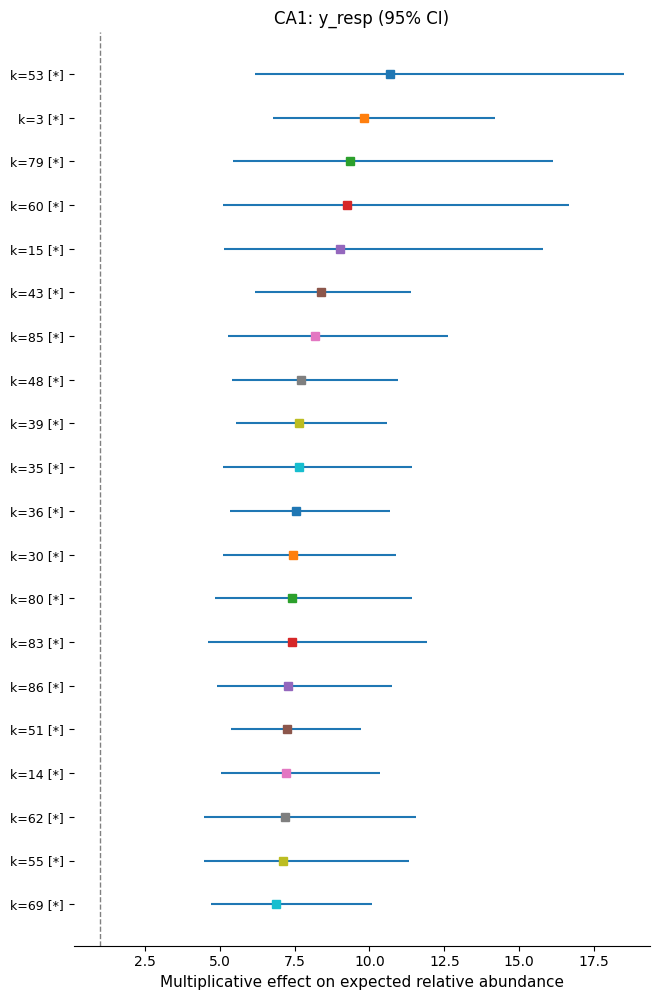

In [ ]:
import numpy as np
import pandas as pd
from typing import Tuple, Dict, Optional
from dataclasses import dataclass

# ============================================================
# 1) Data simulation: bags with DA at the bag-level outcome
# ============================================================

@dataclass
class SimConfig:
    N_bags: int = 120
    mean_bag_size: int = 500
    bag_size_dispersion: float = 0.5  # >0; larger -> more variable sizes
    d: int = 10                       # reduced-dim space for graph/neighborhoods
    n_regions: int = 6                # latent spatial “regions” on R^d
    sep: float = 3.0                  # region center separation (larger -> clearer regions)
    sigma: float = 0.8                # per-instance noise within a region
    prop: float = 0.12                # proportion of vertices to sample as seeds
    k: int = 20                       # k for kNN graph and refinement
    refined: bool = True
    refinement_scheme: str = "reduced_dim"  # or "graph"
    seed: int = 7

def _softmax(a, axis=-1):
    a = a - np.max(a, axis=axis, keepdims=True)
    ea = np.exp(a)
    return ea / np.sum(ea, axis=axis, keepdims=True)

def simulate_bags_da(cfg: SimConfig) -> Tuple[pd.DataFrame, np.ndarray, np.ndarray, np.ndarray]:
    """
    Create instance-level data pooled across bags, where the bag outcome y affects
    mixture weights over latent spatial regions. This induces DA at bag level.
    Returns:
      - inst_df: DataFrame with columns [bag_id, y, i_in_bag, *X_d*]
      - X: (M x d) array of instance coordinates (reduced space for graph)
      - bag_ids: (M,) int array of bag indices
      - y_bag: (N_bags,) outcome per bag (0/1)
    """
    rng = np.random.default_rng(cfg.seed)

    # Bag-level outcomes and sizes
    y_bag = rng.integers(0, 2, size=cfg.N_bags)
    # NegBin-like variability via Gamma-Poisson mixture:
    # lambda ~ Gamma(shape, scale) -> size ~ Poisson(lambda)
    shape = 1.0 / (cfg.bag_size_dispersion + 1e-8)
    scale = cfg.mean_bag_size / shape
    lam = rng.gamma(shape, scale, size=cfg.N_bags)
    n_i = np.maximum(20, rng.poisson(lam))  # avoid tiny bags

    # Define latent region centers (well separated)
    C = rng.normal(0, 1, size=(cfg.n_regions, cfg.d))
    # Spread them apart
    C = C / np.linalg.norm(C, axis=1, keepdims=True) * cfg.sep

    # Outcome-dependent logits for mixture over regions
    # y=0 prefers half the regions; y=1 prefers the other half
    half = cfg.n_regions // 2
    logit_base = np.zeros(cfg.n_regions)
    logit_shift = np.concatenate([np.ones(half), -np.ones(cfg.n_regions - half)]) * 1.0
    # Random per-bag perturbation so not perfectly separable
    bag_jitter = rng.normal(0, 0.4, size=(cfg.N_bags, cfg.n_regions))

    X_list = []
    bag_ids = []
    y_rep = []
    i_in_bag = []

    for b in range(cfg.N_bags):
        K = cfg.n_regions
        logits = logit_base + (2 * y_bag[b] - 1) * logit_shift + bag_jitter[b]
        w = _softmax(logits)
        # draw component assignments then positions
        z = rng.choice(K, size=n_i[b], p=w)
        noise = rng.normal(0, cfg.sigma, size=(n_i[b], cfg.d))
        pts = C[z] + noise

        X_list.append(pts)
        bag_ids.append(np.full(n_i[b], b, dtype=int))
        y_rep.append(np.full(n_i[b], y_bag[b], dtype=int))
        i_in_bag.append(np.arange(n_i[b], dtype=int))

    X = np.vstack(X_list)
    bag_ids = np.concatenate(bag_ids)
    y_inst = np.concatenate(y_rep)
    i_in_bag = np.concatenate(i_in_bag)

    cols = {f"x{j+1}": X[:, j] for j in range(cfg.d)}
    inst_df = pd.DataFrame({
        "bag_id": bag_ids,
        "y": y_inst,
        "i_in_bag": i_in_bag
    } | cols)

    return inst_df, X, bag_ids, y_bag


# ============================================================
# 2) kNN graph construction (undirected), pure NumPy
# ============================================================

def knn_bruteforce(X: np.ndarray, k: int, batch: int = 5000) -> np.ndarray:
    """
    Return kNN indices for each row in X using batched brute-force L2.
    Shape: (N, k). Excludes self; symmetric not enforced.
    """
    N, d = X.shape
    idx_out = np.empty((N, k), dtype=int)
    # Precompute row norms to speed up distances
    row2 = np.sum(X**2, axis=1, keepdims=True)  # (N,1)
    for start in range(0, N, batch):
        end = min(N, start + batch)
        # D(i,j) = ||x_i||^2 + ||x_j||^2 - 2 x_i·x_j
        dots = X[start:end] @ X.T                                 # (b, N)
        d2 = row2[start:end] + row2.T - 2.0 * dots               # (b, N)
        # exclude self: set diag big
        for i in range(start, end):
            d2[i-start, i] = np.inf
        # pick k smallest
        idx_out[start:end] = np.argpartition(d2, kth=k-1, axis=1)[:, :k]
    return idx_out

def make_undirected_edge_list(knn_idx: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From directed kNN indices, produce undirected edges (i<j) without duplicates.
    """
    N, k = knn_idx.shape
    rows = np.repeat(np.arange(N), k)
    cols = knn_idx.ravel()
    i = np.minimum(rows, cols)
    j = np.maximum(rows, cols)
    mask = i != j
    i, j = i[mask], j[mask]
    # unique pairs
    order = np.lexsort((j, i))
    i, j = i[order], j[order]
    dedup = np.ones_like(i, dtype=bool)
    dedup[1:] = (i[1:] != i[:-1]) | (j[1:] != j[:-1])
    return i[dedup], j[dedup]

def adjacency_lists(N: int, edges_i: np.ndarray, edges_j: np.ndarray) -> Dict[int, np.ndarray]:
    adj = {u: [] for u in range(N)}
    for a, b in zip(edges_i, edges_j):
        adj[a].append(b)
        adj[b].append(a)
    return {u: np.array(v, dtype=int) for u, v in adj.items()}


# ============================================================
# 3) Milo-style neighborhood construction (overlapping)
# ============================================================

def sample_vertices(N: int, prop: float, rng: np.random.Generator) -> np.ndarray:
    m = max(1, int(np.floor(prop * N)))
    return rng.choice(N, size=m, replace=False)

def refined_sampling_reduced_dim(
    seeds: np.ndarray, X: np.ndarray, knn_idx: np.ndarray
) -> np.ndarray:
    """
    For each seed, compute the coordinate-wise median of its kNN,
    then snap to the nearest real point in X. (Medoid-like refinement.)
    """
    import math
    k = knn_idx.shape[1]
    nh_medians = np.median(X[knn_idx[seeds]], axis=1)  # (S, d)

    # find nearest neighbor of each median in X (brute-force)
    S, d = nh_medians.shape
    batch = 4096
    nearest = np.empty(S, dtype=int)
    for start in range(0, S, batch):
        end = min(S, start + batch)
        M = nh_medians[start:end]                        # (b,d)
        # distances to all X
        # ||m||^2 + ||x||^2 - 2 m·x
        m2 = np.sum(M**2, axis=1, keepdims=True)         # (b,1)
        x2 = np.sum(X**2, axis=1, keepdims=True).T       # (1,N)
        dots = M @ X.T                                   # (b,N)
        d2 = m2 + x2 - 2.0 * dots
        nearest[start:end] = np.argmin(d2, axis=1)
    return nearest

def count_triangles_in_ego(center: int, adj: Dict[int, np.ndarray]) -> Tuple[np.ndarray, np.ndarray]:
    """
    For the 1-hop ego graph of 'center', return:
      - nodes: np.ndarray of nodes in ego (excluding center)
      - tri_counts: triangles per node within the ego (undirected).
    """
    nbrs = adj[center]
    if nbrs.size == 0:
        return nbrs, np.zeros(0, dtype=int)
    nbr_set = set(nbrs.tolist())
    tri = np.zeros_like(nbrs, dtype=int)
    # Count triangles by shared neighbors within the ego
    for idx, u in enumerate(nbrs):
        # triangles through u are neighbors of u that are also in nbrs
        shared = np.intersect1d(adj[u], nbrs, assume_unique=False)
        # Each triangle (center, u, v) is counted twice across u and v; consistency across nodes is fine
        tri[idx] = shared.size
    return nbrs, tri

def refined_sampling_graph(seeds: np.ndarray, adj: Dict[int, np.ndarray]) -> np.ndarray:
    """
    For each seed, select the node in its 1-hop ego with the max triangle count.
    """
    refined = []
    for s in seeds:
        nodes, tri = count_triangles_in_ego(s, adj)
        if nodes.size == 0:
            refined.append(s)
        else:
            arg = np.argmax(tri)
            refined.append(nodes[arg])
    return np.array(refined, dtype=int)

def make_neighborhoods(
    X: np.ndarray,
    k: int,
    prop: float,
    refined: bool = True,
    refinement_scheme: str = "reduced_dim",
    rng: Optional[np.random.Generator] = None
) -> Tuple[np.ndarray, Dict[int, np.ndarray], np.ndarray]:
    """
    Build Milo-style overlapping neighborhoods on a kNN graph in reduced space X.
    Returns:
      - knn_idx: (N,k) kNN indices (directed)
      - adj: adjacency lists (undirected)
      - centers: refined neighborhood centers (unique)
    """
    if rng is None:
        rng = np.random.default_rng(123)

    N = X.shape[0]
    knn_idx = knn_bruteforce(X, k=k)
    ei, ej = make_undirected_edge_list(knn_idx)
    adj = adjacency_lists(N, ei, ej)

    seeds = sample_vertices(N, prop, rng)

    if not refined:
        centers = seeds
    else:
        if refinement_scheme == "reduced_dim":
            centers = refined_sampling_reduced_dim(seeds, X, knn_idx)
        elif refinement_scheme == "graph":
            centers = refined_sampling_graph(seeds, adj)
        else:
            raise ValueError("refinement_scheme must be 'reduced_dim' or 'graph'")

    centers = np.unique(centers)
    return knn_idx, adj, centers

def neighborhoods_incidence(
    centers: np.ndarray,
    adj: Dict[int, np.ndarray]
) -> pd.DataFrame:
    """
    Create an instance-by-neighborhood (overlapping) incidence matrix (0/1) as a DataFrame.
    Neighborhood = 1-hop ego INCLUDING the center (as in Milo).
    """
    N = len(adj)
    K = len(centers)
    rows = []
    cols = []
    data = []
    for j, c in enumerate(centers):
        # 1-hop ego includes center
        members = np.unique(np.concatenate(([c], adj[c])))
        rows.extend(members.tolist())
        cols.extend([j] * len(members))
        data.extend([1] * len(members))
    # build a sparse-like COO in pandas (we’ll groupby to count later)
    inc = pd.DataFrame({"i": rows, "k": cols, "v": data})
    # pivot to wide (dense) only at the end for clarity; we keep as long-form
    return inc


# ============================================================
# 4) From neighborhoods to bag-level counts & CA1 call
# ============================================================

def bag_level_counts_from_incidence(
    inc: pd.DataFrame,
    bag_ids: np.ndarray,
    K: int
) -> pd.DataFrame:
    """
    Sum overlapping neighborhood membership per bag.
    Each instance can contribute to multiple neighborhoods (as in Milo).
    Returns a (bags x K) DataFrame with count columns c_1..c_K and column 'n' (bag size).
    """
    # instance → bag map
    inst2bag = pd.Series(bag_ids, name="bag_id")
    inst2bag.index.name = "i"

    # join incidence with bag ids
    g = inc.merge(inst2bag.reset_index(), on="i", how="left")
    # sum v by (bag, k)
    bag_k = g.groupby(["bag_id", "k"], sort=False)["v"].sum().reset_index()
    # pivot to wide c_1..c_K
    wide = bag_k.pivot(index="bag_id", columns="k", values="v").fillna(0).astype(int)
    # ensure all K present
    for kk in range(K):
        if kk not in wide.columns:
            wide[kk] = 0
    wide = wide.sort_index(axis=1)
    wide.columns = [f"c_{j+1}" for j in range(K)]
    wide = wide.reset_index()

    # add bag sizes (n)
    n_per_bag = pd.Series(bag_ids).value_counts().sort_index()
    wide["n"] = wide["bag_id"].map(n_per_bag)
    return wide


# ============================================================
# 5) Demonstration: simulate → build neighborhoods → CA1
# ============================================================

if __name__ == "__main__":
    # --- configure simulation & neighborhoods
    cfg = SimConfig(
        N_bags=100,
        mean_bag_size=100,
        bag_size_dispersion=0.6,
        d=10,
        n_regions=6,
        sep=3.0,
        sigma=0.8,
        prop=0.01,
        k=100,
        refined=True,
        refinement_scheme="reduced_dim",  # or "graph"
        seed=7
    )

    # 1) simulate instances pooled across bags (y drives mixture over latent regions)
    inst_df, X, bag_ids, y_bag = simulate_bags_da(cfg)

    # 2) build neighborhoods (overlapping) on pooled kNN graph
    knn_idx, adj, centers = make_neighborhoods(
        X=X, k=cfg.k, prop=cfg.prop, refined=cfg.refined,
        refinement_scheme=cfg.refinement_scheme,
        rng=np.random.default_rng(cfg.seed)
    )

    # 3) instance×neighborhood incidence (long-form), then bag-level counts
    inc = neighborhoods_incidence(centers, adj)
    K_comm = len(centers)
    bag_counts = bag_level_counts_from_incidence(inc, bag_ids, K_comm)

    # 4) assemble CA1 design: bag-level outcome y + optional covariates
    bags = pd.DataFrame({
        "bag_id": np.arange(cfg.N_bags, dtype=int),
        "y_resp": y_bag.astype(int)  # binary outcome that *truly* drives DA
    })

    df = bags.merge(bag_counts, on="bag_id", how="left").fillna(0)
    # Reorder columns: counts, n, targets (as expected by fit_ca1_multi_targets)
    count_cols = [c for c in df.columns if c.startswith("c_")]
    df = df[["bag_id"] + ["n"] + count_cols + ["y_resp"]]

    print(f"[info] Simulated {len(X)} instances across {cfg.N_bags} bags.")
    print(f"[info] Built {K_comm} overlapping neighborhoods (communities).")
    print(df.head())

    # 5) Run CA1 using your function
    results = fit_ca1_multi_targets(
        df=df.drop(columns=["bag_id"]),  # CA1 uses only counts/offset/targets/covariates
        K=K_comm,
        target_cols=["y_resp"],
        covariates=None,
        handle_collinearity="auto",   # will switch to deviation coding if compositional
        outdir=None,
        plot=True,
        scale="ratio",

        min_total=10,
        min_bags=0
    )


In [ ]:
# identify all community columns
comm_cols = [c for c in df.columns if c.startswith("c_")]

# total membership across all communities
df["total_memberships"] = df[comm_cols].sum(axis=1)

# inspect
df[["n", "total_memberships"]].head()


,n,total_memberships
0,305,871
1,23,67
2,107,277
3,122,336
4,120,337


In [ ]:
df.y_resp.mean()

np.float64(0.56)

# CA2 Code: Community Memberships and Instance-Level Outcomes

**Goal.**  
This notebook simulates and analyzes how *community memberships* of instances within bags relate to an instance-level outcome. We then fit a Generalized Linear Model (GLM) that estimates the effect of each community on the outcome, while being robust to bag-level clustering and potential collinearity among membership predictors.

---

## Setup at a glance

- **Bags and instances:** We simulate $N$ bags (e.g., slides/patients), each with a random number of instances ($\sim \text{Poisson}(\text{mean}_n)$).
- **Communities ($K$):** Every instance has memberships $m_1, \dots, m_K$.
  - **Exclusive** mode: one-hot membership (rows sum to 1).
  - **Overlapping** mode: multiple communities can be active (Bernoulli by community).
  - **Soft memberships** (optional): active memberships take a value in $(0, 1)$.
- **Covariates (optional):**
  - A bag-level categorical site ($A/B/C$).
  - A per-instance numeric covariate centered around a bag-specific mean.
- **Bag heterogeneity:** A random intercept per bag on the link scale ($u_i \sim \mathcal{N}(0, \tau)$).

---

## Data-generating model

For each instance $p$ in bag $i$, we simulate an outcome $t_p$ from a GLM:

$$
\eta_p = \alpha_0 + u_i + \sum_{k=1}^{K} \gamma_k m_{pk} + \text{(covariates)},
$$

with $t_p$ drawn according to the chosen **family**:

- **Binomial:** $\text{logit}^{-1}(\eta_p) \;\;\Rightarrow\;\; t_p \in \{0,1\}$
- **Gaussian:** $\eta_p$ directly as the mean $\;\;\Rightarrow\;\; t_p \in \mathbb{R}$
- **Poisson:** $\exp(\eta_p) \;\;\Rightarrow\;\; t_p \in \mathbb{N}$

The vector $\gamma = (\gamma_1,\dots,\gamma_K)$ encodes the *true* community effects used to generate the data (e.g., community 1 increases risk, community 3 decreases risk).

---

## What we fit (CA2)

We fit a GLM:

$$
t \;\sim\; m_1 + \cdots + m_K + \text{covariates},
$$

using **cluster-robust (bag-clustered) standard errors** so inference accounts for within-bag correlation.  

For binomial/poisson families we report **odds/rate ratios** (via $\exp(\hat\beta)$);  
for gaussian we report raw coefficient changes.

---

## Preventing large bags from dominating

By default, we apply **frequency weights** proportional to the inverse of bag size so that each bag contributes roughly equally to the fit. You can switch this off or use a balanced variant.

- `instance_weights="inverse_bag_size"` (default): equalize bag influence.  
- `instance_weights="balanced"`: scaled variant with similar behavior.  
- `instance_weights="none"`: standard instance-level likelihood.

---

## Handling collinearity among memberships

When memberships are **exclusive** (rows sum to 1), including all $K$ membership columns plus an intercept makes the design **rank-deficient**.

We support several strategies (chosen via `handle_collinearity`):

- **"auto"**: Detects exclusivity/rank deficiency; switches to **deviation coding**.
- **"deviation"**: Reparameterize with $K-1$ deviation-coded columns (sum-to-zero constraint), fit the model, then **back-transform** to obtain $K$ per-community effects $\theta_k$ with $\sum_k \theta_k = 0$. We compute **Wald p-values** for each $\theta_k$ using the delta method.
- **"drop"**: Drop one membership as a reference and report $K-1$ contrasts.
- **"none"**: Fit raw columns as-is (may fail if rank-deficient).

---

## Output and visualization

- The function returns a tidy table with coefficients, CIs, p-values, FDR-adjusted q-values (BH across membership terms), and effect scales:
  - **Binomial/Poisson:** ratios (and optional % change $= (\exp(\beta)-1)\times 100\%$)
  - **Gaussian:** raw coefficient scale
- The provided **forest plot** shows each community’s effect with confidence intervals and marks FDR-significant terms.

---

## How to explore

- Toggle **exclusive vs overlapping** memberships.  
- Change the **family** to switch between logistic, linear, and log-linear models.  
- Turn **instance weighting** on/off to see how bag-size dominance affects estimates.  
- Compare **handle_collinearity** strategies to see their impact on inference and interpretability.

---


Columns: ['bag_id', 't', 'm_1', 'm_2', 'm_3', 'm_4', 'x_num', 'site'] ...
Head:
    bag_id  t  m_1  m_2  m_3  m_4      x_num site
0       0  0  0.0  0.0  0.0  1.0  58.678448    A
1       0  0  0.0  0.0  1.0  0.0  57.957663    A
2       0  1  1.0  0.0  0.0  0.0  53.079513    A
3       0  1  0.0  0.0  1.0  0.0  67.086402    A
4       0  1  1.0  0.0  0.0  0.0  62.455861    A 

True community effects (gamma): [ 1.   0.  -0.8  0. ]
[info] Collinearity likely (exclusive memberships or rank-deficient design) → using deviation coding.
[info] Collinearity likely (exclusive memberships or rank-deficient design) → using deviation coding.

CA2 effects (memberships first):
  term  is_membership      coef        se             p     ci_lo     ci_hi  \
0  m_1           True  0.899739  0.124339  4.615575e-13  0.656039  1.143440   
1  m_3           True -0.881623  0.106998  1.727481e-16 -1.091335 -0.671911   
2  m_2           True -0.018607  0.084293  8.252919e-01 -0.183818  0.146604   
3  m_4         

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


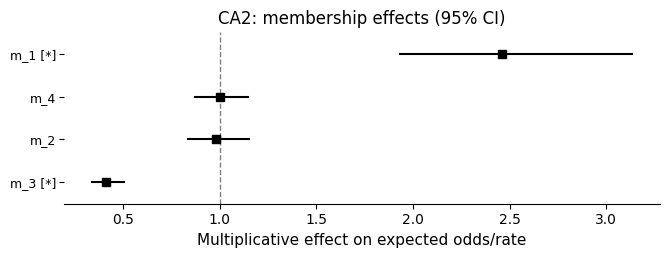

In [ ]:
# If needed in Colab:
# !pip install -q statsmodels scipy

from typing import List, Dict, Optional, Tuple, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families import Binomial, Gaussian, Poisson
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm


# =============================================================================
# 1) SIMULATION: Instance-level CA2 data with memberships and bag structure
# =============================================================================

def simulate_ca2_instances(
    N: int = 100,                 # number of bags
    K: int = 4,                   # number of communities
    mean_n: int = 200,            # average instances per bag
    exclusive: bool = True,       # if True, exactly one community per instance
    overlapping_prob: float = 0.3,# if not exclusive: Bernoulli prob per community
    soft_memberships: bool = False,# if True: draw soft m_pk in [0,1] for selected communities
    family: str = "binomial",     # "binomial", "gaussian", or "poisson"
    gamma: Optional[np.ndarray] = None,  # true effects per community (K,)
    alpha0: float = 0.0,          # intercept
    tau_bag: float = 0.8,         # SD of random bag intercept on link scale
    covariates: bool = True,      # include a numeric covariate and a categorical site
    seed: int = 7
) -> Tuple[pd.DataFrame, Dict[str, Union[np.ndarray, Dict]]]:
    """
    Simulate instance-level data for **CA2** (community-at-instance effects).

    Intuition
    ---------
    Each instance p in bag i has memberships m_{pk} over K communities and an outcome t_p.
    On the link scale we simulate:
        η_p = α0 + u_i + Σ_k γ_k m_{pk} + (optional covariates),
    where u_i is a bag random intercept. Then t_p is drawn from the chosen family:
      - 'binomial': logit link → t ∈ {0,1}
      - 'gaussian': identity link → t ∈ ℝ
      - 'poisson' : log link → t ∈ ℕ
    Memberships can be exclusive (one-hot), overlapping, or soft weights.

    Returns
    -------
    df : long DataFrame with columns ['bag_id','t','m_1'..'m_K', (optional) 'x_num','site']
    meta : dict with simulation metadata (true_gamma, etc.)
    """
    rng = np.random.default_rng(seed)

    # True community effects γ_k used to generate t
    if gamma is None:
        gamma = np.array([1.0, 0.0, -0.8, 0.0], dtype=float) if K == 4 else np.zeros(K, dtype=float)
        if K > 0:
            gamma[0] = 1.0
        if K > 2:
            gamma[2] = -0.8
    else:
        gamma = np.asarray(gamma, dtype=float)
        assert gamma.shape == (K,)

    # Bag sizes and random intercepts
    n_per_bag = rng.poisson(mean_n, size=N).clip(min=20)
    u_bag = rng.normal(0.0, tau_bag, size=N)  # random effect per bag (link scale)

    # Optional bag covariates
    if covariates:
        site = rng.choice(list("ABC"), size=N, p=[0.5, 0.3, 0.2])   # categorical (per bag)
        age_mean = rng.normal(60, 8, size=N)                        # a bag-level numeric "mean"
    else:
        site = np.array(["A"] * N)
        age_mean = np.zeros(N)

    # Build instances
    rows = []
    for i in range(N):
        n_i = n_per_bag[i]
        x_num_i = rng.normal(loc=age_mean[i], scale=5.0, size=n_i) if covariates else np.zeros(n_i)

        # Membership matrix M for bag i (n_i x K)
        M = np.zeros((n_i, K), dtype=float)
        if exclusive:
            # exactly one community per instance
            choices = rng.integers(0, K, size=n_i)
            M[np.arange(n_i), choices] = 1.0
            if soft_memberships:
                # soften 1s into Beta, then renorm row to sum=1
                for p in range(n_i):
                    m = np.zeros(K)
                    m[choices[p]] = rng.beta(3, 2)
                    m = m / (m.sum() + 1e-12)
                    M[p] = m
        else:
            # overlapping: Bernoulli per community per instance
            active = rng.random((n_i, K)) < max(min(overlapping_prob, 0.95), 0.05)
            if soft_memberships:
                M = np.where(active, rng.beta(3, 2, size=(n_i, K)), 0.0)
            else:
                M = active.astype(float)
            # ensure at least one membership per instance
            none_mask = M.sum(axis=1) == 0
            if none_mask.any():
                idx = np.where(none_mask)[0]
                chosen = rng.integers(0, K, size=len(idx))
                M[idx, chosen] = 1.0

        # Linear predictor
        lp = alpha0 + u_bag[i] + M.dot(gamma)
        if covariates:
            site_eff = {"A": 0.0, "B": 0.2, "C": -0.2}[site[i]]
            lp = lp + 0.01 * (x_num_i - 60.0) + site_eff

        # Outcomes
        if family == "binomial":
            p = 1.0 / (1.0 + np.exp(-lp))
            t = rng.binomial(n=1, p=p, size=n_i)
        elif family == "gaussian":
            t = lp + rng.normal(0.0, 1.0, size=n_i)
        elif family == "poisson":
            mu = np.exp(lp)
            t = rng.poisson(mu, size=n_i)
        else:
            raise ValueError("family must be one of {'binomial','gaussian','poisson'}")

        # Accumulate rows
        for p_idx in range(n_i):
            row = {"bag_id": i, "t": t[p_idx], **{f"m_{k+1}": float(M[p_idx, k]) for k in range(K)}}
            if covariates:
                row["x_num"] = float(x_num_i[p_idx])
                row["site"] = site[i]
            rows.append(row)

    df = pd.DataFrame(rows)
    meta = {
        "true_gamma": gamma,
        "alpha0": alpha0,
        "tau_bag": tau_bag,
        "exclusive": exclusive,
        "soft_memberships": soft_memberships,
        "family": family,
        "K": K,
        "N_bags": N
    }
    return df, meta


# =============================================================================
# 2) FITTING: GLM with memberships (+ bag-clustered SEs) — CA2 core
# =============================================================================

def _design_rank(X: np.ndarray, tol: float = 1e-10) -> int:
    """Utility: numerical matrix rank."""
    return np.linalg.matrix_rank(X, tol=tol)


def fit_ca2_glm(
    df: pd.DataFrame,
    target_col: str = "t",
    membership_cols: Optional[List[str]] = None,
    covariates: Optional[List[str]] = None,
    bag_id_col: str = "bag_id",
    family: str = "binomial",                      # 'binomial' | 'gaussian' | 'poisson'
    handle_collinearity: str = "auto",             # 'auto' | 'deviation' | 'drop' | 'none'
    ci_level: float = 0.95,
    cov_type: str = "cluster",                     # 'cluster' uses bag_id clustered SEs
    instance_weights: str = "inverse_bag_size"     # 'inverse_bag_size' | 'balanced' | 'none'
) -> pd.DataFrame:
    """
    Fit CA2 model: instance outcome ~ community memberships + covariates.

    Intuition
    ---------
    The CA2 model asks: *“Does belonging to a certain community make an instance
    more or less likely to have a particular outcome, after accounting for bag-level
    clustering and other covariates?”*.
    Each instance has memberships (m_1…m_K) and an outcome t (binary, continuous, or count).
    We fit a GLM with robust (clustered-by-bag) SEs. To avoid large bags dominating,
    we can apply **frequency weights**:
      - 'inverse_bag_size' (default): every bag contributes roughly equally.
      - 'balanced'        : per-bag weights scaled to have mean 1 across the dataset.
      - 'none'            : no weighting (instance-level likelihood).

    Why collinearity happens
    ------------------------
    With exclusive memberships (rows sum to 1), the K membership columns and the
    intercept are linearly dependent. Including all K makes the design rank-deficient.

    Strategies (handle_collinearity)
    --------------------------------
    - 'auto'      : Detect exclusivity or rank deficiency and switch to 'deviation'.
    - 'deviation' : Replace K memberships by K-1 *deviation-coded* columns that span
                    the sum-to-zero subspace; fit those, then **back-transform** to
                    K per-community effects θ with Σ_k θ_k = 0. We report **Wald
                    p-values** for each θ_k using the delta method (so not NaN).
    - 'drop'      : Drop one membership as reference; report K-1 contrasts with
                    standard statsmodels p-values.
    - 'none'      : Use raw columns as-is (may error if rank-deficient).

    Returns
    -------
    effects : pd.DataFrame
        Tidy table with (for membership terms and any covariates):
          - term, coef, se, p, ci_lo, ci_hi
          - effect_plot, effect_lo, effect_hi (exp-scale for binomial/poisson)
          - percent_change (for binomial/poisson: (exp(coef)-1)*100)
          - null_value (1 for ratios, 0 for gaussian)
          - q (BH-FDR across **membership** terms), significant flag
          - is_membership, nobs
        If 'deviation' is used, all K communities get an effect with sum-to-zero;
        p-values are Wald tests on the back-transformed θ_k.
    """
    # Detect membership columns if not supplied
    if membership_cols is None:
        membership_cols = sorted([c for c in df.columns if c.startswith("m_")],
                                 key=lambda s: int(s.split("_")[1]))
    if covariates is None:
        covariates = []

    K = len(membership_cols)
    if K < 2:
        raise ValueError("CA2 requires at least two membership columns (m_1, m_2, ...).")

    # ---------- Optional: per-instance weights to control bag-size dominance ----------
    if instance_weights not in {"inverse_bag_size", "balanced", "none"}:
        raise ValueError("instance_weights must be one of {'inverse_bag_size','balanced','none'}")

    bag_sizes = df.groupby(bag_id_col)[bag_id_col].transform("count")
    if instance_weights == "inverse_bag_size":
        w = 1.0 / bag_sizes
        # scale so average weight ≈ 1 (nice for GLM convergence)
        w = w * (len(w) / w.sum())
    elif instance_weights == "balanced":
        # equalize per-bag total weight to 1, then scale mean to 1
        w = 1.0 / bag_sizes
        w = w * (len(w) / w.sum())
    else:
        w = np.ones(len(df), dtype=float)

    # ---------- Heuristic checks for collinearity ----------
    is_exclusive = np.allclose(df[membership_cols].sum(axis=1).values, 1.0)
    X_members = df[membership_cols].to_numpy()
    intercept = np.ones((len(df), 1))
    X_quick = np.hstack([intercept, X_members])
    rank_deficient = _design_rank(X_quick) < (1 + K)

    # Resolve strategy
    method = handle_collinearity
    if handle_collinearity == "auto" and (is_exclusive or rank_deficient):
        print("[info] Collinearity likely (exclusive memberships or rank-deficient design) → using deviation coding.")
        method = "deviation"

    # Resolve strategy
    method = handle_collinearity
    if handle_collinearity == "auto" and (is_exclusive or rank_deficient):
        print("[info] Collinearity likely (exclusive memberships or rank-deficient design) → using deviation coding.")
        method = "deviation"

    # NEW: if still 'auto', choose a safe default
    if method == "auto":
        print("[info] No clear collinearity detected → using raw memberships ('none').")
        method = "none"


    # Family
    fam = {"binomial": Binomial(), "gaussian": Gaussian(), "poisson": Poisson()}[family]

    # -------------------------------------------------------------------------
    # Branch A: Deviation coding (sum-to-zero) with back-transform to K effects
    # -------------------------------------------------------------------------
    if method == "deviation":
        # Build contrast matrix B: K x (K-1) spanning the sum-to-zero subspace
        # B = [I_{K-1}; -1_{1×(K-1)}] ensures 1ᵀ B = 0.
        B = np.vstack([np.eye(K - 1), -np.ones((1, K - 1))])  # shape (K, K-1)

        # Deviation-coded design for memberships: (n x (K-1))
        M = df[membership_cols].to_numpy()
        M_dev = M @ B  # project  to sum-to-zero subspace

        # Build DataFrame of regression inputs
        dev_cols = [f"m_dev{k}" for k in range(1, K)]
        design = pd.DataFrame(M_dev, columns=dev_cols, index=df.index)
        for c in covariates:
            design[c] = df[c].values
        design[target_col] = df[target_col].values
        design["_w"] = w

        # Fit GLM on deviation-coded columns (freq_weights implements bag-size control)
        rhs_terms = dev_cols + covariates
        rhs = " + ".join(rhs_terms) if rhs_terms else "1"
        formula = f"{target_col} ~ {rhs}"
        model = smf.glm(formula=formula, data=design, family=fam, freq_weights=design["_w"])
        res = model.fit(
            cov_type="cluster" if cov_type == "cluster" else cov_type,
            cov_kwds={"groups": df[bag_id_col].values} if cov_type == "cluster" else None
        )

        # Extract β (K-1) and V_β ((K-1)x(K-1)), then map to θ = B β (K effects, sum-to-zero)
        beta = np.array([res.params.get(col, np.nan) for col in dev_cols])
        V_beta = res.cov_params().loc[dev_cols, dev_cols].to_numpy()

        theta = B @ beta                               # shape (K,)
        V_theta = B @ V_beta @ B.T                     # shape (K,K)

        # Collect membership effects (all K, sum-to-zero) with Wald p-values
        rows = []
        zcrit = norm.ppf(1 - (1 - ci_level) / 2.0)
        for k in range(K):
            term = membership_cols[k]
            coef = float(theta[k])
            var_k = float(V_theta[k, k]) if np.isfinite(V_theta[k, k]) else np.nan
            se = float(np.sqrt(max(var_k, 0.0))) if np.isfinite(var_k) else np.nan
            lo, hi = (coef - zcrit * se, coef + zcrit * se) if np.isfinite(se) and se > 0 else (np.nan, np.nan)

            # Wald p-value for θ_k (delta method)
            if np.isfinite(se) and se > 0:
                z = coef / se
                p_val = 2 * norm.sf(abs(z))
            else:
                p_val = np.nan

            if family in ("binomial", "poisson"):
                effect = np.exp(coef)
                effect_lo, effect_hi = (np.exp(lo), np.exp(hi)) if np.isfinite(lo) and np.isfinite(hi) else (np.nan, np.nan)
                percent_change = (effect - 1.0) * 100.0 if np.isfinite(effect) else np.nan
                null_value = 1.0
            else:
                effect, effect_lo, effect_hi = coef, lo, hi
                percent_change = coef
                null_value = 0.0

            rows.append({
                "term": term,
                "is_membership": True,
                "coef": coef,
                "se": se,
                "p": p_val,
                "ci_lo": lo,
                "ci_hi": hi,
                "effect_plot": effect,
                "effect_lo": effect_lo,
                "effect_hi": effect_hi,
                "percent_change": percent_change,
                "null_value": null_value,
                "nobs": res.nobs
            })

        # Add covariate rows (native p-values from the model)
        conf_df = res.conf_int(alpha=1 - ci_level)
        for term in res.params.index:
            if term == "Intercept" or term in dev_cols:
                continue
            coef = float(res.params[term]); se = float(res.bse[term]); p = float(res.pvalues[term])
            lo, hi = conf_df.loc[term].tolist()
            if family in ("binomial", "poisson"):
                eff, lo_e, hi_e = np.exp(coef), np.exp(lo), np.exp(hi)
                pc, null = (eff - 1.0) * 100.0, 1.0
            else:
                eff, lo_e, hi_e = coef, lo, hi
                pc, null = coef, 0.0
            rows.append({
                "term": term, "is_membership": False, "coef": coef, "se": se, "p": p,
                "ci_lo": lo, "ci_hi": hi,
                "effect_plot": eff, "effect_lo": lo_e, "effect_hi": hi_e,
                "percent_change": pc, "null_value": null, "nobs": res.nobs
            })

        effects = pd.DataFrame(rows)

    # ---------------------------------------------------------
    # Branch B: Drop one membership column as reference (K-1)
    # ---------------------------------------------------------
    elif method == "drop":
        used_memberships = membership_cols[:-1]  # drop last as reference
        rhs_terms = used_memberships + covariates
        rhs = " + ".join(rhs_terms) if rhs_terms else "1"
        formula = f"{target_col} ~ {rhs}"
        model = smf.glm(formula=formula, data=df, family=fam, freq_weights=w)
        res = model.fit(
            cov_type="cluster" if cov_type == "cluster" else cov_type,
            cov_kwds={"groups": df[bag_id_col].values} if cov_type == "cluster" else None
        )

        rows = []
        conf_df = res.conf_int(alpha=1 - ci_level)
        for term in res.params.index:
            if term == "Intercept":
                continue
            coef = float(res.params[term]); se = float(res.bse[term]); p = float(res.pvalues[term])
            lo, hi = conf_df.loc[term].tolist()

            if family in ("binomial", "poisson"):
                eff, lo_e, hi_e = np.exp(coef), np.exp(lo), np.exp(hi)
                pc, null = (eff - 1.0) * 100.0, 1.0
            else:
                eff, lo_e, hi_e = coef, lo, hi
                pc, null = coef, 0.0

            rows.append({
                "term": term,
                "is_membership": term in membership_cols,
                "coef": coef, "se": se, "p": p,
                "ci_lo": lo, "ci_hi": hi,
                "effect_plot": eff, "effect_lo": lo_e, "effect_hi": hi_e,
                "percent_change": pc, "null_value": null, "nobs": res.nobs
            })

        effects = pd.DataFrame(rows)

    # ---------------------------------------------------------
    # Branch C: None (use raw columns; may be collinear)
    # ---------------------------------------------------------
    elif method == "none":
        if is_exclusive:
            print("[warn] handle_collinearity='none' with exclusive memberships may cause collinearity.")
        rhs_terms = membership_cols + covariates
        rhs = " + ".join(rhs_terms) if rhs_terms else "1"
        formula = f"{target_col} ~ {rhs}"
        model = smf.glm(formula=formula, data=df, family=fam, freq_weights=w)
        res = model.fit(
            cov_type="cluster" if cov_type == "cluster" else cov_type,
            cov_kwds={"groups": df[bag_id_col].values} if cov_type == "cluster" else None
        )

        rows = []
        conf_df = res.conf_int(alpha=1 - ci_level)
        for term in res.params.index:
            if term == "Intercept":
                continue
            coef = float(res.params[term]); se = float(res.bse[term]); p = float(res.pvalues[term])
            lo, hi = conf_df.loc[term].tolist()

            if family in ("binomial", "poisson"):
                eff, lo_e, hi_e = np.exp(coef), np.exp(lo), np.exp(hi)
                pc, null = (eff - 1.0) * 100.0, 1.0
            else:
                eff, lo_e, hi_e = coef, lo, hi
                pc, null = coef, 0.0

            rows.append({
                "term": term,
                "is_membership": term in membership_cols,
                "coef": coef, "se": se, "p": p,
                "ci_lo": lo, "ci_hi": hi,
                "effect_plot": eff, "effect_lo": lo_e, "effect_hi": hi_e,
                "percent_change": pc, "null_value": null, "nobs": res.nobs
            })

        effects = pd.DataFrame(rows)

    else:
        raise ValueError("handle_collinearity must be one of {'auto','deviation','drop','none'}")

    # BH-FDR across membership terms only
    mem_mask = effects["is_membership"].values
    if mem_mask.any():
        # if any p is NaN (shouldn't in deviation now), treat as 1.0 for FDR
        pvals = effects.loc[mem_mask, "p"].fillna(1.0).values
        rej, qvals, _, _ = multipletests(pvals, method="fdr_bh")
        effects.loc[mem_mask, "q"] = qvals
        effects.loc[mem_mask, "significant"] = rej
    else:
        effects["q"] = np.nan
        effects["significant"] = False

    # Sort by absolute effect magnitude (percent_change is on an intuitive scale for binomial/poisson)
    effects = effects.sort_values(by="percent_change", key=np.abs, ascending=False).reset_index(drop=True)
    return effects


# =============================================================================
# 3) PLOTTING: Publication-style forest plot for CA2 (self-contained)
# =============================================================================

def plot_ca2_forest_publication(
    effects_df: pd.DataFrame,
    family: str = "binomial",
    title: str = "CA2: Community effects on instance outcome",
    ci_level: float = 0.95,
    scale: str = "ratio",          # 'percent' or 'ratio'
    only_memberships: bool = True,
    sort_by_abs: bool = True,
    outpath: Optional[str] = None
) -> None:
    """
    Draw a publication-style forest plot for CA2 (matches CA1 look/feel).

    Visual semantics:
      - Each row is a community membership effect (or covariate if included).
      - Square = point estimate; horizontal line = CI.
      - Append [*] to y-axis labels for BH-FDR significant memberships.
      - Reference line: 1.0 for ratio-scale (binomial/poisson), 0.0 for gaussian.
    """
    df = effects_df.copy()
    if only_memberships:
        df = df[df["is_membership"]]

    if df.empty:
        print("[warn] No membership terms to plot.")
        return

    # Choose scale
    if family in ("binomial", "poisson"):
        if scale == "percent":
            x = (df["effect_plot"] - 1.0) * 100.0
            lo = (df["effect_lo"] - 1.0) * 100.0
            hi = (df["effect_hi"] - 1.0) * 100.0
            ref_line = 0.0
            x_label = "% change in expected odds/rate"
        elif scale == "ratio":
            x = df["effect_plot"]; lo = df["effect_lo"]; hi = df["effect_hi"]
            ref_line = 1.0
            x_label = "Multiplicative effect on expected odds/rate"
        else:
            raise ValueError("scale must be 'percent' or 'ratio'")
    else:  # gaussian
        x = df["effect_plot"]; lo = df["effect_lo"]; hi = df["effect_hi"]
        ref_line = 0.0
        x_label = "Change in expected outcome"

    # Sorting
    order_idx = x.abs().sort_values(ascending=True).index if sort_by_abs else df.index
    df = df.loc[order_idx].copy()
    x = x.loc[order_idx]; lo = lo.loc[order_idx]; hi = hi.loc[order_idx]

    # Labels with [*] if significant (memberships only)
    df["label"] = df.apply(
        lambda r: f"{r['term']} [*]" if (r.get("significant", False) and r.get("is_membership", False)) else str(r["term"]),
        axis=1
    )

    y_pos = np.arange(len(df))
    fig, ax = plt.subplots(figsize=(6.8, 0.42 * len(df) + 1))

    # Draw segments and points
    for i, idx in enumerate(df.index):
        ax.hlines(y=y_pos[i], xmin=lo.loc[idx], xmax=hi.loc[idx], color="black", lw=1.5)
        ax.plot(x.loc[idx], y_pos[i], "s", color="black", markersize=6, zorder=3)

    # Reference line and axes styling
    ax.axvline(ref_line, linestyle="--", color="gray", lw=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df["label"].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_ylim(-0.5, len(df) - 0.5)
    ax.margins(y=0)
    ax.tick_params(axis="y", pad=2)

    ax.set_xlabel(x_label, fontsize=11)
    ax.set_title(title + f" ({int(ci_level*100)}% CI)", fontsize=12)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.8)

    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"[saved] {outpath}")
    plt.show()


# =============================================================================
# 4) EXAMPLE USAGE
# =============================================================================

if __name__ == "__main__":
    # --- Simulate instance-level CA2 (binary outcome), exclusive one-hot memberships ---
    df, meta = simulate_ca2_instances(
        N=12, K=4, mean_n=160,
        exclusive=True,            # change to False for overlapping memberships
        soft_memberships=False,    # True → soft m_{pk} in [0,1]
        family="binomial",         # try 'gaussian' or 'poisson' as well
        tau_bag=0.7,               # random bag intercept SD
        covariates=True,           # include x_num and site
        seed=123
    )

    print("Columns:", df.columns.tolist()[:10], "...")
    print("Head:\n", df.head(), "\n")
    print("True community effects (gamma):", meta["true_gamma"])

    # --- Fit GLM with memberships + (optional) covariates ---
    membership_cols = [c for c in df.columns if c.startswith("m_")]
    effects = fit_ca2_glm(
        df=df,
        target_col="t",
        membership_cols=membership_cols,
        covariates=[],                 # e.g., ["x_num", "site"]
        bag_id_col="bag_id",
        family="binomial",             # 'gaussian' or 'poisson'
        handle_collinearity="auto",    # auto-detect and resolve
        ci_level=0.95,
        cov_type="cluster",            # cluster-robust SEs by bag
        instance_weights="inverse_bag_size"  # default; try 'none' to see the difference
    )

    print("\nCA2 effects (memberships first):")
    print(effects.head(12))

    # --- Forest plot (memberships only), publication-style ---
    plot_ca2_forest_publication(
        effects_df=effects,
        family="binomial",
        title="CA2: membership effects",
        ci_level=0.95,
        scale="ratio",               # 'percent' or 'ratio'
        only_memberships=True,
        sort_by_abs=True,
        outpath=None                   # e.g., "ca2_forest.png"
    )


##FA1 Code

Columns: ['bag_id', 'x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10', 'site'] ...
Head:
    bag_id       x_1       x_2       x_3       x_4       x_5       x_6  \
0       0  2.774019  0.425957 -0.809527 -0.699767  0.721337 -0.270218   
1       0 -0.265135  1.292160  1.159984 -0.002459  0.957563 -0.605778   
2       0 -0.061024 -0.909653  0.091456  0.103653  1.217568  0.633065   
3       0  0.326707 -1.011136  1.621389 -0.963108  1.287963 -2.394993   
4       0 -0.099977 -0.997192 -1.980614 -0.744311 -0.784494  1.054752   

        x_7       x_8       x_9      x_10 site     z_num  t_r1      t_r2  
0 -0.121700  1.240560 -0.519875 -0.228320    A -1.014961   1.0  0.947912  
1  0.278113  0.324793  0.633827 -2.961996    A -0.823859   1.0  1.062788  
2  0.635429  0.301836  1.722715 -0.634820    A -0.387333   1.0 -1.564314  
3  1.023030 -1.552202  0.275131  0.760789    A -1.992558   1.0  0.036078  
4 -0.528305 -0.321247 -0.849717 -0.727494    A -1.156841   0.0 -2.199803   


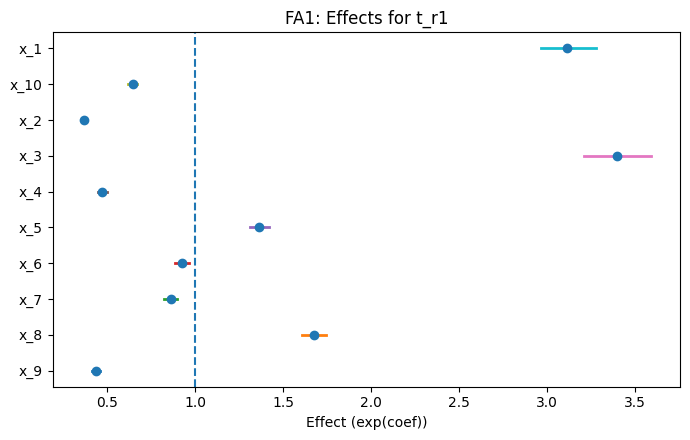


=== Effects for t_r2 (family=gaussian) ===
   target       term  is_feature      coef        se              p     ci_lo  \
0    t_r2        x_1        True -0.048365  0.009462   3.200120e-07 -0.066911   
1    t_r2       x_10        True  0.362727  0.008666   0.000000e+00  0.345742   
2    t_r2        x_2        True  0.874841  0.008927   0.000000e+00  0.857344   
3    t_r2        x_3        True  0.044628  0.009356   1.840064e-06  0.026292   
4    t_r2        x_4        True  0.444765  0.008977   0.000000e+00  0.427171   
5    t_r2        x_5        True -0.934641  0.010089   0.000000e+00 -0.954416   
6    t_r2        x_6        True -0.601912  0.008345   0.000000e+00 -0.618269   
7    t_r2        x_7        True  0.475247  0.008639   0.000000e+00  0.458315   
8    t_r2        x_8        True -0.303161  0.009227  9.380791e-237 -0.321246   
9    t_r2        x_9        True -0.021208  0.009787   3.024045e-02 -0.040390   
10   t_r2  site[T.B]       False  0.231647  0.135278   8.682832e-

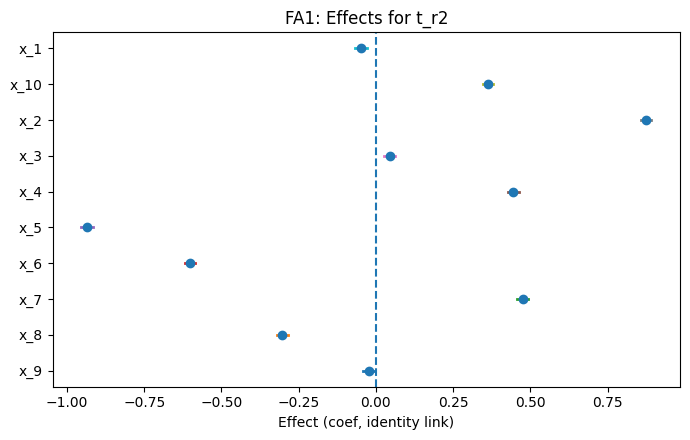

In [ ]:
# If needed in Colab:
# !pip install -q statsmodels

from typing import List, Dict, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families import Binomial, Gaussian, Poisson
from statsmodels.stats.multitest import multipletests


# =============================================================================
# 1) SIMULATION: Instance-level FA1 data (features -> instance targets)
# =============================================================================

def simulate_fa1_instances(
    N: int = 120,                 # number of bags
    n_mean: int = 150,            # average instances per bag
    d: int = 8,                   # number of instance features
    R: int = 2,                   # number of target components (e.g., t_r1, t_r2)
    families: Optional[List[str]] = None,  # per-target family: 'binomial'|'gaussian'|'poisson'
    alpha_true: Optional[np.ndarray] = None,  # shape (R, d) true feature effects
    intercepts: Optional[List[float]] = None, # per-target intercepts
    tau_bag: float = 0.6,         # SD of random bag intercept (on link scale)
    add_covariates: bool = True,  # include bag covariates: site (categorical), z_num (numeric)
    seed: int = 123
) -> Tuple[pd.DataFrame, Dict]:
    """
    Simulate FA1:
        For each target component r:
            g_r( E[t_{p,r}] ) = intercept_r + x_p^T alpha_r + covariates + u_{bag}
        where u_{bag} ~ N(0, tau_bag^2) and g_r is link for chosen family.

    Returns a long DataFrame with columns:
        bag_id, x_1..x_d, (optional) site, z_num, and targets t_r1..t_rR
    """
    rng = np.random.default_rng(seed)
    if families is None:
        families = ["binomial", "gaussian"][:R] + ["gaussian"] * max(0, R - 2)
    assert len(families) == R

    # True coefficients
    if alpha_true is None:
        alpha_true = rng.normal(0, 0.5, size=(R, d))
        # make a couple of stronger signals
        if d >= 2:
            alpha_true[:, :2] += np.array([[1.0, -0.8]] + [[0, 0]] * (R - 1))
    if intercepts is None:
        intercepts = [0.0] * R

    # Bag-level covariates (optional)
    site = rng.choice(list("ABC"), size=N, p=[0.5, 0.3, 0.2]) if add_covariates else np.array(["A"] * N)
    z_num_bag = rng.normal(0, 1, size=N) if add_covariates else np.zeros(N)

    # Bag random intercepts (on link scale)
    u_bag = rng.normal(0, tau_bag, size=N)

    rows = []
    for i in range(N):
        n_i = rng.poisson(n_mean)
        n_i = max(n_i, 30)  # ensure enough per bag

        # Instance features (iid standard normal)
        X = rng.normal(0, 1, size=(n_i, d))

        # Optional per-instance numeric covariate around bag value (weak effect)
        z_num = z_num_bag[i] + rng.normal(0, 0.5, size=n_i) if add_covariates else np.zeros(n_i)

        # Linear predictors and draw targets
        T_cols = {}
        for r in range(R):
            lp = intercepts[r] + X @ alpha_true[r] + u_bag[i]
            if add_covariates:
                # small effects for demo: site B:+0.2, C:-0.2 ; z_num:+0.2
                lp = lp + (0.2 if site[i] == "B" else (-0.2 if site[i] == "C" else 0.0)) + 0.2 * z_num

            fam = families[r]
            if fam == "binomial":
                p = 1.0 / (1.0 + np.exp(-lp))
                t = rng.binomial(n=1, p=p, size=n_i)
            elif fam == "gaussian":
                t = lp + rng.normal(0, 1.0, size=n_i)
            elif fam == "poisson":
                mu = np.exp(lp)
                t = rng.poisson(mu, size=n_i)
            else:
                raise ValueError("families entries must be 'binomial'|'gaussian'|'poisson'")
            T_cols[f"t_r{r+1}"] = t

        for p_idx in range(n_i):
            row = {
                "bag_id": i,
                **{f"x_{j+1}": float(X[p_idx, j]) for j in range(d)},
            }
            if add_covariates:
                row["site"] = site[i]
                row["z_num"] = float(z_num[p_idx])
            for k, v in T_cols.items():
                row[k] = float(v[p_idx])
            rows.append(row)

    df = pd.DataFrame(rows)
    meta = {
        "alpha_true": alpha_true,
        "intercepts": intercepts,
        "families": families,
        "tau_bag": tau_bag,
        "N_bags": N,
        "d": d,
        "R": R,
        "add_covariates": add_covariates
    }
    return df, meta


# =============================================================================
# 2) FITTING: GLM per target component with bag-clustered SEs
# =============================================================================

def fit_fa1_glm_multi_targets(
    df: pd.DataFrame,
    feature_cols: Optional[List[str]] = None,    # e.g., ['x_1', ... 'x_d']
    target_cols: Optional[List[str]] = None,     # e.g., ['t_r1','t_r2',...]
    covariates: Optional[List[str]] = None,      # e.g., ['site','z_num']
    bag_id_col: str = "bag_id",
    families: Optional[Dict[str, str]] = None,   # map target -> 'binomial'|'gaussian'|'poisson'
    cov_type: str = "cluster"                    # clustered SEs by bag
) -> Dict[str, pd.DataFrame]:
    """
    Fit FA1: for each target column, run GLM:
        target ~ x_1 + ... + x_d + covariates
    - Uses Patsy formula API and bag-clustered SEs.
    - Returns a dict of tidy tables (one per target) with BH-FDR across features.
    """
    if feature_cols is None:
        feature_cols = [c for c in df.columns if c.startswith("x_")]
        feature_cols = sorted(feature_cols, key=lambda s: int(s.split("_")[1]))
    if target_cols is None:
        target_cols = [c for c in df.columns if c.startswith("t_r")]
        target_cols = sorted(target_cols, key=lambda s: int(s.split("t_r")[1]))
    if covariates is None:
        covariates = []

    # family resolver
    def _fam(name: str):
        return {"binomial": Binomial(), "gaussian": Gaussian(), "poisson": Poisson()}[name]

    results: Dict[str, pd.DataFrame] = {}
    for tgt in target_cols:
        fam_name = families[tgt] if families and tgt in families else "gaussian"
        fam = _fam(fam_name)

        rhs_terms = feature_cols + covariates
        rhs = " + ".join(rhs_terms) if rhs_terms else "1"
        formula = f"{tgt} ~ {rhs}"

        model = smf.glm(formula=formula, data=df, family=fam)
        res = model.fit(
            cov_type="cluster" if cov_type == "cluster" else cov_type,
            cov_kwds={"groups": df[bag_id_col].values} if cov_type == "cluster" else None
        )

        # Extract all non-intercept terms
        rows = []
        for term in res.params.index:
            if term == "Intercept":
                continue
            coef = float(res.params[term])
            se = float(res.bse[term])
            p = float(res.pvalues[term])
            lo, hi = res.conf_int().loc[term].values

            # Forest-plot scale: exp for logit/log; raw for identity
            if fam_name in ("binomial", "poisson"):
                eff = np.exp(coef)
                eff_lo = np.exp(lo)
                eff_hi = np.exp(hi)
            else:
                eff = coef
                eff_lo = lo
                eff_hi = hi

            rows.append({
                "target": tgt,
                "term": term,
                "is_feature": (term in feature_cols) or any(term.startswith(f"C({c}") for c in feature_cols),  # robust flag
                "coef": coef,
                "se": se,
                "p": p,
                "ci_lo": lo,
                "ci_hi": hi,
                "effect_plot": eff,
                "effect_lo": eff_lo,
                "effect_hi": eff_hi,
                "family": fam_name,
                "nobs": res.nobs
            })

        eff_df = pd.DataFrame(rows)

        # BH-FDR across *features only* for this target
        feat_mask = eff_df["is_feature"].values
        if feat_mask.any():
            rej, qvals, _, _ = multipletests(eff_df.loc[feat_mask, "p"].values, method="fdr_bh")
            eff_df.loc[feat_mask, "q"] = qvals
            eff_df.loc[feat_mask, "significant"] = rej
        else:
            eff_df["q"] = np.nan
            eff_df["significant"] = False

        results[tgt] = eff_df.sort_values(["is_feature", "term"], ascending=[False, True]).reset_index(drop=True)

    return results


# =============================================================================
# 3) PLOTTING: Forest plot per target (features only by default)
# =============================================================================

def plot_fa1_forest(
    effects_df: pd.DataFrame,
    title: str = "FA1: Feature effects on instance outcome",
    only_features: bool = True
) -> None:
    """
    Forest plot for one target's effects:
    - Uses exp(coef) for binomial/poisson targets (odds/rate ratios)
    - Uses raw coef for gaussian targets
    """
    df = effects_df.copy()
    fam = df["family"].iloc[0] if "family" in df.columns and not df.empty else "gaussian"
    if only_features:
        df = df[df["is_feature"]]

    if df.empty:
        print("[warn] No rows to plot.")
        return

    # Sort for consistent top-down ordering
    df = df.sort_values("term", ascending=False).reset_index(drop=True)
    y = np.arange(len(df))

    plt.figure(figsize=(7, 4.5))

    # CIs
    for i, r in enumerate(df.itertuples(index=False)):
        plt.plot([r.effect_lo, r.effect_hi], [y[i], y[i]], lw=2)

    # Points
    plt.scatter(df["effect_plot"].values, y, zorder=3)

    # Reference line
    if fam in ("binomial", "poisson"):
        plt.axvline(1.0, linestyle="--")
        plt.xlabel("Effect (exp(coef))")
    else:
        plt.axvline(0.0, linestyle="--")
        plt.xlabel("Effect (coef, identity link)")

    plt.yticks(y, df["term"].values)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# =============================================================================
# 4) EXAMPLE USAGE
# =============================================================================

if __name__ == "__main__":
    # ---- Simulate instance-level FA1 with two targets (one binomial, one gaussian) ----
    df, meta = simulate_fa1_instances(
        N=150, n_mean=120, d=10, R=2,
        families=["binomial", "gaussian"],  # t_r1 logistic, t_r2 Gaussian
        tau_bag=0.7,
        add_covariates=True,
        seed=77
    )

    print("Columns:", df.columns.tolist()[:12], "...")
    print("Head:\n", df.head(), "\n")
    print("True alpha (R x d) shape:", meta["alpha_true"].shape)

    # ---- Fit FA1 GLMs for both targets with bag-clustered SEs ----
    feature_cols = [c for c in df.columns if c.startswith("x_")]
    target_cols = [c for c in df.columns if c.startswith("t_r")]
    covariates = ["site", "z_num"]  # optional; can be []

    results = fit_fa1_glm_multi_targets(
        df=df,
        feature_cols=feature_cols,
        target_cols=target_cols,
        covariates=covariates,
        bag_id_col="bag_id",
        families={target_cols[0]: "binomial", target_cols[1]: "gaussian"},
        cov_type="cluster"
    )

    # ---- Show results and forest plots per target ----
    for tgt, eff_df in results.items():
        print(f"\n=== Effects for {tgt} (family={eff_df['family'].iloc[0]}) ===")
        print(eff_df.head(12))
        plot_fa1_forest(
            effects_df=eff_df,
            title=f"FA1: Effects for {tgt}",
            only_features=True
        )


## FA2 Code


=== Broadcast FA2 results for y_bin (family=binomial) ===
  target       term  is_feature      coef        se         p         q  \
0  y_bin        x_1        True  0.010190  0.016146  0.527952  0.723986   
1  y_bin        x_2        True  0.020350  0.013941  0.144346  0.520990   
2  y_bin        x_3        True -0.022917  0.017089  0.179901  0.520990   
3  y_bin        x_4        True  0.019050  0.016930  0.260495  0.520990   
4  y_bin        x_5        True -0.008186  0.015753  0.603322  0.723986   
5  y_bin        x_6        True  0.001906  0.014250  0.893588  0.893588   
6  y_bin        age       False  0.049345  0.024532  0.044280       NaN   
7  y_bin  site[T.B]       False  0.267293  0.441009  0.544452       NaN   
8  y_bin  site[T.C]       False  0.159559  0.533516  0.764886       NaN   

      ci_lo     ci_hi  effect_plot  effect_lo  effect_hi    family   nobs  \
0 -0.021455  0.041836     1.010242   0.978773   1.042724  binomial  17969   
1 -0.006973  0.047674     1.020559  

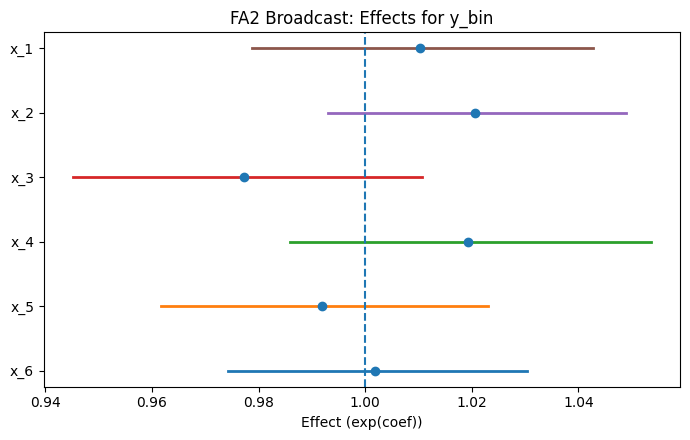


=== Broadcast FA2 results for y_gauss (family=gaussian) ===
    target       term  is_feature      coef        se         p         q  \
0  y_gauss        x_1        True -0.010182  0.007365  0.166803  0.500409   
1  y_gauss        x_2        True  0.009040  0.005246  0.084827  0.500409   
2  y_gauss        x_3        True -0.000456  0.007100  0.948803  0.948803   
3  y_gauss        x_4        True  0.005391  0.007382  0.465170  0.930339   
4  y_gauss        x_5        True -0.000799  0.006282  0.898832  0.948803   
5  y_gauss        x_6        True -0.001612  0.006043  0.789615  0.948803   
6  y_gauss        age       False -0.018598  0.010471  0.075699       NaN   
7  y_gauss  site[T.B]       False -0.008259  0.185056  0.964402       NaN   
8  y_gauss  site[T.C]       False -0.052801  0.225254  0.814671       NaN   

      ci_lo     ci_hi  effect_plot  effect_lo  effect_hi    family   nobs  \
0 -0.024617  0.004253    -0.010182  -0.024617   0.004253  gaussian  17969   
1 -0.001241  0

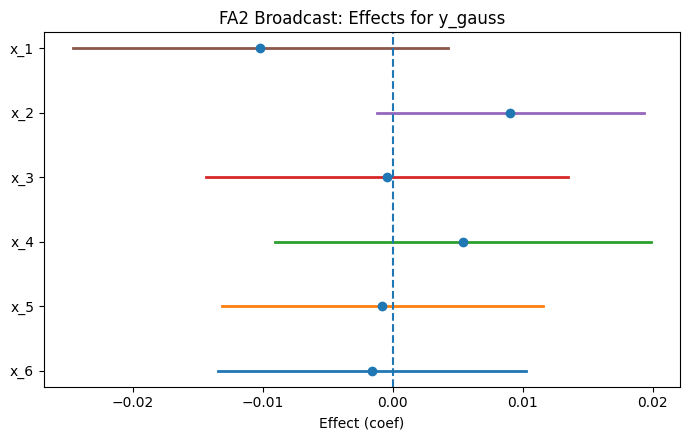


=== Aggregation FA2 results for y_bin (family=binomial) ===
   target       term  is_global_feat  is_comm_feat       coef        se  \
0   y_bin        age           False         False   0.043514  0.028460   
1   y_bin  site[T.B]           False         False   0.207787  0.590279   
2   y_bin  site[T.C]           False         False   0.258378  0.699708   
3   y_bin     xg_x_1            True         False   4.933831  6.490482   
4   y_bin     xg_x_2            True         False  11.803181  7.040446   
5   y_bin     xg_x_3            True         False  -5.242378  8.201875   
6   y_bin     xg_x_4            True         False   7.964323  8.244912   
7   y_bin     xg_x_5            True         False  13.451882  7.087887   
8   y_bin     xg_x_6            True         False   6.092097  6.687479   
9   y_bin      xk1_1           False          True  -0.452168  2.558549   
10  y_bin      xk1_2           False          True  -6.504856  3.600614   
11  y_bin      xk1_3           False   

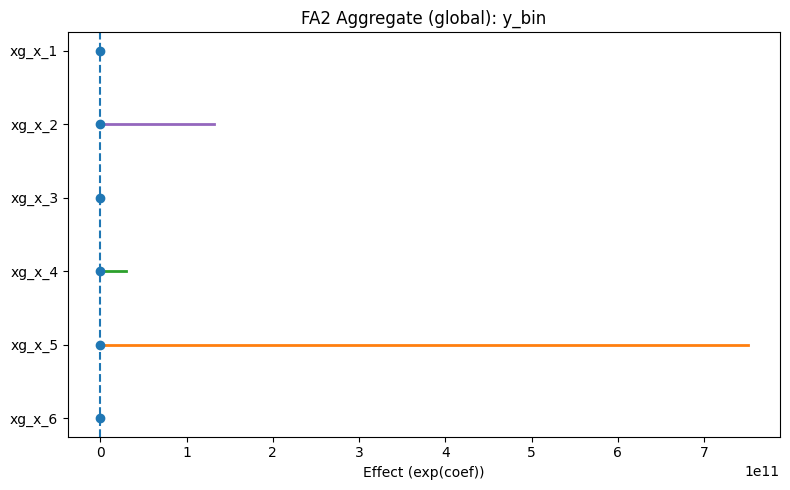

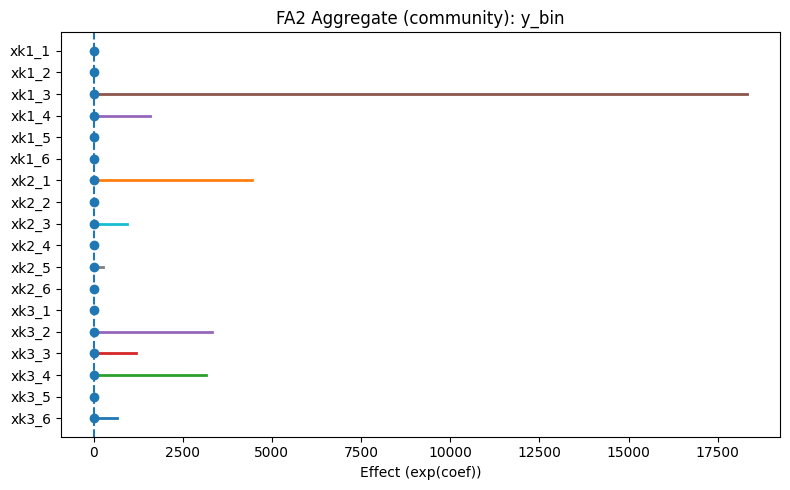


=== Aggregation FA2 results for y_gauss (family=gaussian) ===
     target       term  is_global_feat  is_comm_feat      coef        se  \
0   y_gauss        age           False         False -0.020990  0.010406   
1   y_gauss  site[T.B]           False         False -0.079326  0.174379   
2   y_gauss  site[T.C]           False         False -0.257939  0.265265   
3   y_gauss     xg_x_1            True         False  1.521462  2.197043   
4   y_gauss     xg_x_2            True         False  3.102465  2.547801   
5   y_gauss     xg_x_3            True         False  5.573844  2.892137   
6   y_gauss     xg_x_4            True         False -0.182911  2.714941   
7   y_gauss     xg_x_5            True         False  4.541503  2.893422   
8   y_gauss     xg_x_6            True         False  0.564660  2.899222   
9   y_gauss      xk1_1           False          True -0.991364  0.946314   
10  y_gauss      xk1_2           False          True -1.931166  1.221817   
11  y_gauss      xk1_3   

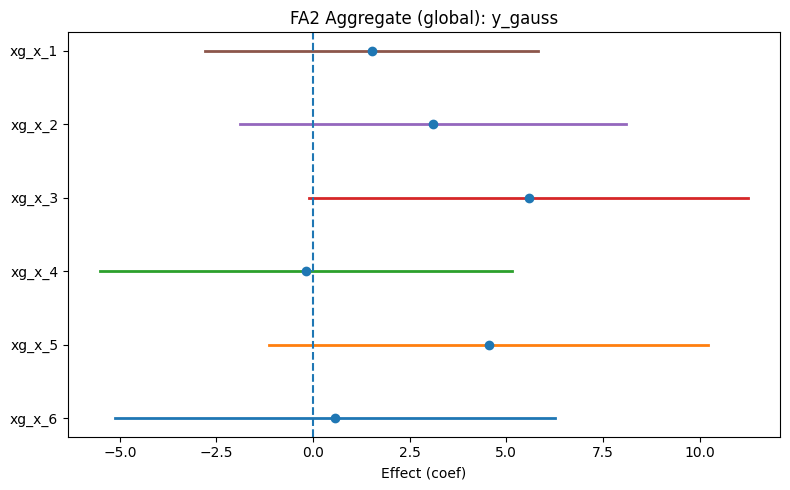

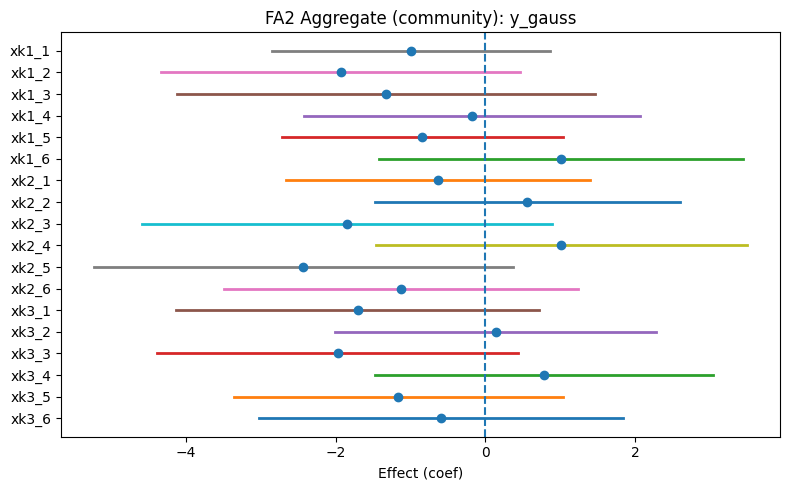

In [ ]:
# If needed in Colab:
# !pip install -q statsmodels

from typing import List, Dict, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families import Binomial, Gaussian, Poisson
from statsmodels.stats.multitest import multipletests


# =============================================================================
# 0) EXPECTED INPUTS
# -----------------------------------------------------------------------------
# Instance-level DataFrame with (at least):
#   bag_id            : bag/slide/patient identifier
#   x_1 ... x_d       : instance features
#   (optional) m_1..m_K : community memberships in [0,1] (hard or soft; can be missing)
#   (optional) t_*    : instance targets (not required for FA2 aggregation)
#
# Bag-level DataFrame with (at least):
#   bag_id
#   y_*               : one or more bag-level targets
#   (optional) v_*    : bag covariates (site, batch, age, ...)
# =============================================================================


# =============================================================================
# 1) BROADCAST SUPERVISION (weak supervision)
#    t_p := y_{bag(p)}, then fit instance-level GLMs with clustered SEs
# =============================================================================

def fa2_broadcast_fit(
    df_instances: pd.DataFrame,
    df_bags: pd.DataFrame,
    target_cols: List[str],                # bag-level targets to broadcast
    feature_cols: Optional[List[str]] = None,  # instance features (x_*)
    bag_covariates: Optional[List[str]] = None,# bag-level covariates to broadcast (v_*)
    bag_id_col: str = "bag_id",
    families: Optional[Dict[str, str]] = None, # per target: 'binomial'|'gaussian'|'poisson'
    cov_type: str = "cluster"                   # clustered SEs by bag
) -> Dict[str, pd.DataFrame]:
    """
    Broadcast y (bag target) to instances, then fit:
        t_broadcast ~ x_1 + ... + x_d + (broadcasted covariates)
    Uses bag-clustered SEs. Returns dict[target] -> tidy effects table with BH-FDR across features.
    """
    if feature_cols is None:
        feature_cols = [c for c in df_instances.columns if c.startswith("x_")]
        feature_cols = sorted(feature_cols, key=lambda s: int(s.split("_")[1]))
    if bag_covariates is None:
        bag_covariates = []

    # Join bag targets/covariates onto instances
    merged = df_instances.merge(df_bags[[bag_id_col] + target_cols + bag_covariates],
                                on=bag_id_col, how="left", validate="many_to_one")

    def _fam(name: str):
        return {"binomial": Binomial(), "gaussian": Gaussian(), "poisson": Poisson()}[name]

    results: Dict[str, pd.DataFrame] = {}
    for tgt in target_cols:
        fam_name = families[tgt] if families and tgt in families else "gaussian"
        fam = _fam(fam_name)

        rhs = " + ".join(feature_cols + bag_covariates) if (feature_cols or bag_covariates) else "1"
        formula = f"{tgt} ~ {rhs}"

        model = smf.glm(formula=formula, data=merged, family=fam)
        res = model.fit(
            cov_type="cluster" if cov_type == "cluster" else cov_type,
            cov_kwds={"groups": merged[bag_id_col].values} if cov_type == "cluster" else None
        )

        rows = []
        for term in res.params.index:
            if term == "Intercept":
                continue
            coef = float(res.params[term]); se = float(res.bse[term]); p = float(res.pvalues[term])
            lo, hi = res.conf_int().loc[term].values
            if fam_name in ("binomial", "poisson"):
                eff, eff_lo, eff_hi = np.exp(coef), np.exp(lo), np.exp(hi)  # odds/rate ratio
            else:
                eff, eff_lo, eff_hi = coef, lo, hi

            rows.append({
                "target": tgt, "term": term, "is_feature": term in feature_cols,
                "coef": coef, "se": se, "p": p, "q": np.nan,
                "ci_lo": lo, "ci_hi": hi,
                "effect_plot": eff, "effect_lo": eff_lo, "effect_hi": eff_hi,
                "family": fam_name, "nobs": res.nobs
            })
        eff_df = pd.DataFrame(rows)

        # BH-FDR across *features only*
        mask = eff_df["is_feature"].values
        if mask.any():
            rej, qvals, _, _ = multipletests(eff_df.loc[mask, "p"].values, method="fdr_bh")
            eff_df.loc[mask, "q"] = qvals
            eff_df.loc[mask, "significant"] = rej
        else:
            eff_df["significant"] = False

        results[tgt] = eff_df.sort_values(["is_feature", "term"], ascending=[False, True]).reset_index(drop=True)

    return results


def plot_forest_fa2_broadcast(effects_df: pd.DataFrame, title: str):
    """
    Forest plot for one broadcasted target; plots features only.
    """
    df = effects_df.copy()
    fam = df["family"].iloc[0]
    df = df[df["is_feature"]]
    if df.empty:
        print("[warn] No feature rows to plot.")
        return

    df = df.sort_values("term", ascending=False).reset_index(drop=True)
    y = np.arange(len(df))

    plt.figure(figsize=(7, 4.5))
    for i, r in enumerate(df.itertuples(index=False)):
        plt.plot([r.effect_lo, r.effect_hi], [y[i], y[i]], lw=2)
    plt.scatter(df["effect_plot"].values, y, zorder=3)

    if fam in ("binomial", "poisson"):
        plt.axvline(1.0, linestyle="--"); plt.xlabel("Effect (exp(coef))")
    else:
        plt.axvline(0.0, linestyle="--"); plt.xlabel("Effect (coef)")
    plt.yticks(y, df["term"].values)
    plt.title(title)
    plt.tight_layout(); plt.show()


# =============================================================================
# 2) BAG-AGGREGATION (global and community-localized feature means)
#    Build bag-level design and fit bag-level GLMs
# =============================================================================

def aggregate_bag_features(
    df_instances: pd.DataFrame,
    feature_cols: Optional[List[str]] = None,        # x_*
    membership_cols: Optional[List[str]] = None,     # m_1..m_K (optional)
    bag_id_col: str = "bag_id",
    min_count_for_mean: int = 1
) -> pd.DataFrame:
    """
    Create a bag-level DataFrame with:
        - n                 : instance count per bag
        - xg_*              : GLOBAL mean features
        - (if memberships present) xk{K}_{j} : COMMUNITY-LOCAL mean features per community
          where xk1_1 = mean of x_1 among instances with m_1>0 (weight = m_1 if soft)
        - c_k               : community "counts" (sum of m_k) if memberships present
    Notes:
        - For soft memberships, community means are weighted by m_{pk}.
        - If a bag has c_k < min_count_for_mean, we set mean to NaN (can later impute or keep NaN).
    """
    if feature_cols is None:
        feature_cols = [c for c in df_instances.columns if c.startswith("x_")]
        feature_cols = sorted(feature_cols, key=lambda s: int(s.split("_")[1]))
    has_memberships = membership_cols is not None and len(membership_cols) > 0

    # Basic groupby
    g = df_instances.groupby(bag_id_col, observed=True)
    out = g.size().rename("n").to_frame().reset_index()

    # GLOBAL means
    global_means = g[feature_cols].mean().add_prefix("xg_").reset_index()
    out = out.merge(global_means, on=bag_id_col, how="left")

    # COMMUNITY means (if available)
    if has_memberships:
        # compute community "counts" per bag (sum of m_k)
        cks = g[membership_cols].sum().reset_index()
        out = out.merge(cks, on=bag_id_col, how="left")  # these columns are m_1..m_K sums; rename later
        # rename m_k sums to c_k
        for kcol in membership_cols:
            out.rename(columns={kcol: f"c_{kcol.split('_')[1]}"}, inplace=True)

        # weighted means per community
        bag_frames = []
        for kcol in membership_cols:
            # weights w_{pk} = m_{pk}; for hard membership it is 0/1
            # compute weighted mean per bag for each feature: sum(w * x) / sum(w)
            dfw = df_instances[[bag_id_col, kcol] + feature_cols].copy()
            for f in feature_cols:
                dfw[f"{f}_wx"] = dfw[kcol] * dfw[f]
            gk = dfw.groupby(bag_id_col, observed=True).agg(
                **{f"{f}_sumwx": (f"{f}_wx", "sum") for f in feature_cols},
                **{f"{f}_sumw": (kcol, "sum") for f in feature_cols}
            )
            gk = gk.reset_index()
            # build means with guard on small weights
            for f in feature_cols:
                num = gk[f"{f}_sumwx"].values
                den = gk[f"{f}_sumw"].values
                mean = np.where(den >= min_count_for_mean, num / np.where(den == 0, np.nan, den), np.nan)
                gk[f"xk{kcol.split('_')[1]}_{f.split('_')[1]}"] = mean
                # cleanup helper cols
                del gk[f"{f}_sumwx"]; del gk[f"{f}_sumw"]
            # keep only the new xk* columns and bag_id
            keep_cols = [bag_id_col] + [c for c in gk.columns if c.startswith("xk")]
            bag_frames.append(gk[keep_cols])

        # merge all community-mean blocks
        for gf in bag_frames:
            out = out.merge(gf, on=bag_id_col, how="left")

    return out


def fa2_aggregate_fit(
    df_bag_design: pd.DataFrame,
    df_bags_targets_covs: pd.DataFrame,  # must include bag_id + y_* + optional v_*
    target_cols: List[str],
    covariate_cols: Optional[List[str]] = None,  # bag-level covariates already in df_bags_targets_covs
    use_global_means: bool = True,
    use_community_means: bool = False,
    family_by_target: Optional[Dict[str, str]] = None,  # map target -> 'binomial'|'gaussian'|'poisson'
    bag_id_col: str = "bag_id",
    cov_type: str = "HC1"
) -> Dict[str, pd.DataFrame]:
    """
    Fit FA2 on bag-level design:
      - If use_global_means:   y ~ xg_* + covariates
      - If use_community_means:y ~ sum_k xk{k}_* + covariates
    Returns dict[target] -> tidy effects table with BH-FDR across features (or features-by-community).
    """
    if covariate_cols is None:
        covariate_cols = []

    # Join targets/covariates onto design
    df = df_bag_design.merge(df_bags_targets_covs[[bag_id_col] + target_cols + covariate_cols],
                             on=bag_id_col, how="left", validate="one_to_one")

    results: Dict[str, pd.DataFrame] = {}

    # Prepare feature sets
    global_feats = [c for c in df.columns if c.startswith("xg_")] if use_global_means else []
    community_feats = [c for c in df.columns if c.startswith("xk")] if use_community_means else []

    def _fam(name: str):
        return {"binomial": Binomial(), "gaussian": Gaussian(), "poisson": Poisson()}[name]

    for tgt in target_cols:
        fam_name = family_by_target[tgt] if family_by_target and tgt in family_by_target else "gaussian"
        fam = _fam(fam_name)

        rhs_terms = (global_feats + community_feats + covariate_cols)
        rhs = " + ".join(rhs_terms) if rhs_terms else "1"
        formula = f"{tgt} ~ {rhs}"

        model = smf.glm(formula=formula, data=df, family=fam)
        res = model.fit(cov_type=cov_type)

        rows = []
        for term in res.params.index:
            if term == "Intercept":
                continue
            coef = float(res.params[term]); se = float(res.bse[term]); p = float(res.pvalues[term])
            lo, hi = res.conf_int().loc[term].values

            if fam_name in ("binomial", "poisson"):
                eff, eff_lo, eff_hi = np.exp(coef), np.exp(lo), np.exp(hi)
            else:
                eff, eff_lo, eff_hi = coef, lo, hi

            rows.append({
                "target": tgt, "term": term,
                "is_global_feat": term in global_feats,
                "is_comm_feat": term in community_feats,
                "coef": coef, "se": se, "p": p, "q": np.nan,
                "ci_lo": lo, "ci_hi": hi,
                "effect_plot": eff, "effect_lo": eff_lo, "effect_hi": eff_hi,
                "family": fam_name, "nobs": res.nobs
            })
        eff_df = pd.DataFrame(rows)

        # BH-FDR: adjust p-values within each feature family separately
        for mask_name, mask in {
            "global": eff_df["is_global_feat"].values,
            "community": eff_df["is_comm_feat"].values
        }.items():
            if mask.any():
                rej, qvals, _, _ = multipletests(eff_df.loc[mask, "p"].values, method="fdr_bh")
                eff_df.loc[mask, "q"] = qvals
                eff_df.loc[mask, "significant"] = rej

        results[tgt] = eff_df.sort_values("term").reset_index(drop=True)

    return results


def plot_forest_fa2_aggregate(effects_df: pd.DataFrame, title: str, highlight: str = "global"):
    """
    Forest plot for bag-aggregation FA2:
      - highlight='global'  plots global features only (xg_*)
      - highlight='community' plots community-localized features only (xk*)
    """
    df = effects_df.copy()
    fam = df["family"].iloc[0]
    if highlight == "global":
        df = df[df["is_global_feat"]]
    elif highlight == "community":
        df = df[df["is_comm_feat"]]
    if df.empty:
        print(f"[warn] No rows to plot for highlight={highlight}."); return

    df = df.sort_values("term", ascending=False).reset_index(drop=True)
    y = np.arange(len(df))

    plt.figure(figsize=(8, 5))
    for i, r in enumerate(df.itertuples(index=False)):
        plt.plot([r.effect_lo, r.effect_hi], [y[i], y[i]], lw=2)
    plt.scatter(df["effect_plot"].values, y, zorder=3)

    if fam in ("binomial", "poisson"):
        plt.axvline(1.0, linestyle="--"); plt.xlabel("Effect (exp(coef))")
    else:
        plt.axvline(0.0, linestyle="--"); plt.xlabel("Effect (coef)")
    plt.yticks(y, df["term"].values)
    plt.title(title)
    plt.tight_layout(); plt.show()


# =============================================================================
# 3) EXAMPLE USAGE
# =============================================================================

if __name__ == "__main__":
    rng = np.random.default_rng(42)

    # --- Create toy instance-level data ---
    N_bags, d, K = 120, 6, 3
    # bags table with two targets and two covariates
    df_bags = pd.DataFrame({
        "bag_id": np.arange(N_bags),
        "y_bin": rng.integers(0, 2, size=N_bags),         # binomial bag target
        "y_gauss": rng.normal(0, 1, size=N_bags),         # gaussian bag target
        "age": rng.normal(60, 8, size=N_bags),            # numeric covariate
        "site": rng.choice(list("ABC"), size=N_bags, p=[0.6, 0.25, 0.15])  # categorical covariate
    })

    # instances per bag
    n_i = rng.poisson(150, size=N_bags).clip(min=50)
    rows = []
    for i in range(N_bags):
        Xi = rng.normal(0, 1, size=(n_i[i], d))  # features
        # simple overlapping memberships for demo
        Mi = (rng.random((n_i[i], K)) < 0.5).astype(float)
        # ensure at least one membership per instance
        empty = Mi.sum(axis=1) == 0
        if empty.any():
            Mi[empty, rng.integers(0, K, size=empty.sum())] = 1.0
        for p in range(n_i[i]):
            row = {"bag_id": i, **{f"x_{j+1}": Xi[p, j] for j in range(d)},
                   **{f"m_{k+1}": Mi[p, k] for k in range(K)}}
            rows.append(row)
    df_instances = pd.DataFrame(rows)

    # -----------------------------------------------------------------------------
    # (A) BROADCAST supervision
    # -----------------------------------------------------------------------------
    broadcast_results = fa2_broadcast_fit(
        df_instances=df_instances,
        df_bags=df_bags,
        target_cols=["y_bin", "y_gauss"],
        feature_cols=[f"x_{j+1}" for j in range(d)],
        bag_covariates=["age", "site"],
        bag_id_col="bag_id",
        families={"y_bin": "binomial", "y_gauss": "gaussian"},
        cov_type="cluster"
    )

    for tgt, eff_df in broadcast_results.items():
        print(f"\n=== Broadcast FA2 results for {tgt} (family={eff_df['family'].iloc[0]}) ===")
        print(eff_df.head(10))
        plot_forest_fa2_broadcast(eff_df, title=f"FA2 Broadcast: Effects for {tgt}")

    # -----------------------------------------------------------------------------
    # (B) BAG-AGGREGATION
    # -----------------------------------------------------------------------------
    df_bag_design = aggregate_bag_features(
        df_instances=df_instances,
        feature_cols=[f"x_{j+1}" for j in range(d)],
        membership_cols=[f"m_{k+1}" for k in range(K)],
        bag_id_col="bag_id",
        min_count_for_mean=1
    )
    # Join bag covariates/targets separately inside the fit function

    agg_results = fa2_aggregate_fit(
        df_bag_design=df_bag_design,
        df_bags_targets_covs=df_bags,
        target_cols=["y_bin", "y_gauss"],
        covariate_cols=["age", "site"],
        use_global_means=True,
        use_community_means=True,  # include community-localized means too
        family_by_target={"y_bin": "binomial", "y_gauss": "gaussian"},
        bag_id_col="bag_id",
        cov_type="HC1"  # robust bag-level SEs
    )

    for tgt, eff_df in agg_results.items():
        print(f"\n=== Aggregation FA2 results for {tgt} (family={eff_df['family'].iloc[0]}) ===")
        print(eff_df.head(12))
        plot_forest_fa2_aggregate(eff_df, title=f"FA2 Aggregate (global): {tgt}", highlight="global")
        plot_forest_fa2_aggregate(eff_df, title=f"FA2 Aggregate (community): {tgt}", highlight="community")


==================OLD===========================
# DCAFA: Differential Community Abundance and Feature Attribution Analysis for Biomedical Applications
(Fayyaz MINHAS)

---

**Motivation.** Many biomedical, imaging, and omics datasets are **hierarchical**: fine-grained **instances** (e.g., cells, image patches, spots) live inside **bags** (e.g., patients, slides, samples). Instances can be grouped into **communities** with **hard** or **soft** memberships $m_{pk}\in[0,1]$. When bag-level outcomes $y_i$ and/or instance-level outcomes $t_p$ exist, we need tools that (i) quantify **differential community abundance** across outcomes and (ii) attribute **which features** explain differences **at both bag and instance levels**.

**Setup.** Bags $i=1,\dots,N$; instances $p=1,\dots,P$ with bag map $s(p)=i$; instance features $x_p\in\mathbb{R}^d$; memberships $m_{pk}\in[0,1]$ for communities $k=1,\dots,K$. Bag size
$$
n_i \;=\; \sum_{p:\,s(p)=i} 1,
$$
community “counts” per bag
$$
c_{ik} \;=\; \sum_{p:\,s(p)=i} m_{pk}.
$$
Outcomes may be bag-level $y_i\in\mathbb{R}^{R_y}$ or instance-level $t_p\in\mathbb{R}^{R_t}$. Optional bag covariates $v_i\in\mathbb{R}^q$.

---

## Contributions: four complementary modules

- **CA1 — Differential Community Abundance (bag level).** Do **community counts per bag** $c_{ik}$ vary with $y_i$?
  $$
  c_{ik} \;\sim\; y_i + v_i + \mathrm{offset}(\log n_i),
  \qquad
  c_{ik}\sim \text{NB}(\mu_{ik},\alpha_k).
  $$
  Report $\widehat{\beta}_{k}$ and $\exp(\widehat{\beta}_{k})$ as an abundance ratio.

- **CA2 — Differential Community Association (instance level).** Do **instance outcomes** shift with membership $m_{pk}$?
  $$
  t_{p,r} \;\sim\; \sum_{k=1}^K \gamma_{k,r}\, m_{pk} + v_{s(p)} + (1\,|\,s(p)),
  $$
  with a link appropriate to $t_{p,r}$ (logit/identity/log). Interpret $\exp(\widehat{\gamma}_{k,r})$ as odds/rate ratio when applicable.

- **FA1 — Instance-level Feature Attribution.** Which **instance features** $x_p$ explain $t_{p,r}$?
  $$
  t_{p,r} \;\sim\; x_p + v_{s(p)} + (1\,|\,s(p)),
  $$
  reporting $\widehat{\alpha}_{r,j}$ and (if non-Gaussian) $\exp(\widehat{\alpha}_{r,j})$.

- **FA2 — Bag-level Feature Attribution.** Which **aggregated features** explain $y_{i,m}$?
  
All modules use standard regression notation, provide **effect sizes**, **95% CIs**, **$p$-values**, and **BH-FDR** $q$-values, and accommodate **within-bag dependence** (clustered SEs or random intercepts).

---

## Practical use cases

1. **Whole-slide images (WSIs).**  
   **CA1:** detect treatment–control **composition** shifts in phenotype communities (forest plots of $\exp(\widehat{\beta}_{k})$).  
   **FA2:** identify **global** or **within-community** morphology features distinguishing slide labels.  
   **CA2/FA1 (optional):** relate patch memberships/features to patch-level targets.

2. **Single-cell / spatial omics.**  
   **CA1:** differential abundance of cell states (NB for hard clusters; Binomial/Beta on $c_{ik}/n_i$ for soft topics).  
   **CA2:** per-cell outcome association with topics/clusters.  
   **FA1/FA2:** pathway/topic scores as predictors at instance or bag level.

3. **Microbiome / ecology.**  
   **CA1:** differential taxa/community abundance across environments (NB or Beta-Binomial on proportions).  
   **FA2:** aggregated functional features predicting sample phenotype.

4. **Weak supervision / MIL.**  
   Only bag labels? Use **FA2-broadcast** $t_p := y_{s(p)}$ (instance GLMs with bag-clustered SEs), or **FA2-aggregate** on $\tilde{x}_i$ / $\bar{x}_{ik}$.

---

## Community construction & feature choices

- **Hard, exclusive clustering** ($m_{pk}\in\{0,1\},\ \sum_k m_{pk}=1$):  
  **CA1:** NB valid; **CA2:** drop a reference or enforce $\sum_k \gamma_{k,r}=0$. Interpretation is **relative**.

- **Soft topics (LDA/NMF)** ($m_{pk}\in[0,1],\ \sum_k m_{pk}=1$):  
  **CA1:** model **proportions** $c_{ik}/n_i$ (Binomial/Beta/quasi-Binomial).  
  **CA2:** reference/constraint needed; effects are **per-unit membership**.

- **Binary multi-label topics (CorEx)** ($m_{pk}\in\{0,1\}$, multiple topics “on”):  
  **CA1:** NB valid (integer $c_{ik}$);  
  **CA2:** topics as community dummies;  
  **FA1:** topics as binary features.  
  *Note:* CA2 and FA1 become the **same statistical model** when features $= m_{pk}$.

- **Features $x_p$:** raw, reduced (PCA/AE), orthogonal factors (ICA/rotated), or domain scores (pathways). Choose for stability vs interpretability.

---

## Outputs

For each tested effect: point estimate (e.g., $\widehat{\beta}, \widehat{\gamma}, \widehat{\alpha}, \widehat{\zeta}$), SE, 95% CI (often on the exponentiated scale), $p$-value, **FDR-adjusted** $q$-value, and simple diagnostics (deviance/pearson chi-square, $n$).

---

## Caveats & best practices

- **Compositionality (exclusive memberships):** effects are **relative**; use a reference community or impose $\sum_k \gamma_{k,r}=0$.  
- **Soft memberships:** NB requires **integer** counts; for fractional $c_{ik}$, model **proportions**.  
- **Collinearity:** overlapping memberships and correlated topics inflate SEs; use **ridge/LASSO** or **dimension reduction**.  
- **Rare communities:** filter/merge to stabilize inference.  
- **Dependence:** use **bag-clustered SEs** or **random intercepts** for instance models.  
- **Multiple testing:** control FDR across communities and features.

---

**Take-home.** DCAFA unifies **differential community abundance** and **feature attribution** at bag and instance levels with clear GLM formulations, robust uncertainty quantification, and interpretable effect sizes. It yields actionable answers for comparing conditions (e.g., treatment vs control WSIs), exploring cellular/spatial heterogeneity, and linking latent communities and features to outcomes—while making assumptions and limitations explicit.

---
# Detailed implementation
## 1) Setup and Notation

- Bags: $i=1,\dots,N$  
- Instances: $p=1,\dots,P$ with bag map $s(p)=i$  
- Instance features: $x_p \in \mathbb{R}^d$  
- Community memberships: An instance can be assigned to none, one (exclusive) or simultaneously multiple (overlapping) communities with hard or soft membership indicator   $m_{pk}\in[0,1]$ for $k=1,\dots,K$  
- Bag size:  
  $$
  n_i \;=\; \sum_{p:\,s(p)=i} 1
  $$
- Community counts per bag:  
  $$
  c_{ik} \;=\; \sum_{p:\,s(p)=i} m_{pk}
  $$
- Target Outcomes (can be one or both depending upon the flavor):  
  - Bag-level: $y_i \in \mathbb{R}^{R_y}$ with components $y_{i,m}$  
  - Instance-level: $t_p \in \mathbb{R}^{R_t}$ with components $t_{p,r}$  
- Bag covariates: $v_i \in \mathbb{R}^{q}$  (e.g., site, batch, scanner, etc.)

Note that each bag can have just one instance, each community can be a bag or an instance as well.

# CAFA: Summary Table

| Module | Goal | Model target (LHS) | Effect size (coefficients) | Interpretation |
|--------|------|---------------------|----------------------------|----------------|
| **CA1: Bag-level abundance** | Test whether community abundances vary with bag outcomes | $c_{ik}$ (community counts per bag) | $\beta_{k,m}$ (effect of outcome $y_{i,m}$ on community $k$ abundance) | $\exp(\hat\beta_{k,m})$: multiplicative change in relative abundance of community $k$ per unit increase in outcome $m$ |
| **CA2: Instance-level association** | Identify communities enriched for higher/lower instance outcomes | $t_{p,r}$ (instance outcome component $r$) | $\gamma_{k,r}$ (effect of community $k$ on instance outcome $r$) | $\exp(\hat\gamma_{k,r})$: odds/rate ratio (non-Gaussian); sign shows direction of community association with outcome $r$ |
| **FA1: Instance-level features** | Discover which instance features drive variation in instance outcomes | $t_{p,r}$ (instance outcome component $r$) | $\alpha_{r,j}$ (effect of feature $j$ on outcome $r$) | $\exp(\hat\alpha_{r,j})$: odds/rate ratio; features with large, significant coefficients are predictive of instance outcomes |
| **FA2: Bag-level features** | Identify which aggregated features predict bag outcomes | $y_{i,m}$ (bag outcome component $m$) or $t_{p,m}$ (broadcasted) | Global: $\zeta_{m,j}$ (feature $j$ effect on outcome $m$); Community-specific: $\psi_{k,m,j}$ (feature $j$ in community $k$) | $\exp(\hat\zeta_{m,j})$ or $\exp(\hat\psi_{k,m,j})$: how bag outcomes change with global/community-averaged features |

---

## 2) Community Abundance Analysis (CA)

### CA1: CA for Bag Level Targets

**Goal.**  
Test whether the *relative abundance* of a community is associated with bag-level outcomes.

**Core idea.**  
If we regress the (relative) counts of instances of each bag in each community on the bag-level outcome, and the regression coefficients are significant, then community-level abundance helps explain variation in bag-level targets.

**Model (per community $k$).**
$$
c_{ik} \;\sim\; y_i + v_i + \text{offset}(\log n_i),
\qquad c_{ik}\sim \mathrm{NB}(\mu_{ik}, \alpha_k)
$$

with  
$$
\log \mu_{ik} \;=\; \beta_{0k} \;+\; y_i^\top \beta_k \;+\; v_i^\top \delta_k \;+\; \log n_i.
$$

**Reporting and interpretation.**  
- Effect size: $\widehat{\beta}_{k,m}$ = log fold-change in expected *proportion* of community $k$ per unit increase in outcome $y_{i,m}$.  
- Report $\exp(\widehat{\beta}_{k,m})$ as multiplicative change.  
- Hypothesis: $H_0:\beta_{k,m}=0$.  
- Significance: Wald or likelihood ratio test, adjusted to $q_{k,m}$ (BH-FDR).  
- Intuition: if $q_{k,m}<0.05$, community $k$ is enriched ($\widehat{\beta}_{k,m}>0$) or depleted ($<0$) as outcome $m$ increases.

**Caveats.**  
- Exclusive memberships: $c_{ik}$ are compositional (sum to $n_i$). Interpretation is relative.  
- Overdispersion handled by $\alpha_k$.  
- Covariates $v_i$ (e.g., site/batch) must be included to avoid confounding.

---

### CA2: CA for Instance-level targets

**Goal.**  
Identify communities associated with higher or lower instance-level outcomes.

**Core idea.**  
If we regress each instance’s outcome on its community memberships and the coefficients for some communities are significant, then those communities are predictive of the outcome distribution at the instance level.

**Model (per outcome component $r$).**
$$
t_{p,r} \;\sim\; m_{p1} + \cdots + m_{pK} + v_{s(p)} + (1\,|\,s(p)),
$$

with link $g_r(\cdot)$:
$$
g_r\!\big(\mathbb{E}[t_{p,r}]\big)
\;=\;
\alpha_r
\;+\;
\sum_{k=1}^{K}\gamma_{k,r}\,m_{pk}
\;+\;
v_{s(p)}^\top \eta_r
\;+\;
u_{s(p),r}.
$$
This allows modelling different types (continuous (gaussian), binary (binomial), count (poisson)) targets.

**Reporting and interpretation.**  
- Effect size: $\widehat{\gamma}_{k,r}$ = change in mean/odds/rate of $t_{p,r}$ per unit membership in community $k$.  
- Report $\exp(\widehat{\gamma}_{k,r})$ for odds or rate ratios.  
- Hypothesis: $H_0:\gamma_{k,r}=0$.  
- Intuition: sign and magnitude of $\widehat{\gamma}_{k,r}$ indicate whether community $k$ tends to have higher/lower outcomes.  
- Multiple testing: control FDR across $(k,r)$.

**Caveats.**  
- Exclusive memberships: $\{m_{pk}\}$ collinear with intercept → drop a reference community or constrain $\sum_k \gamma_{k,r}=0$.  
- Overlapping memberships: effects interpreted as *per-unit membership*.  
- Within-bag correlation must be modeled (random intercepts or bag-clustered SEs).

---

## 3) Feature Attribution Analysis (FA)

### FA1: FA for Instance-level targets

**Goal.**  
Discover which original instance features explain variation in instance outcomes.

**Core idea.**  
If we regress instance-level outcomes directly on instance features, significant coefficients reveal which features are predictive of outcomes.

**Model (per component $r$).**
$$
t_{p,r} \;\sim\; x_p + v_{s(p)} + (1\,|\,s(p)),
$$

with link $g_r(\cdot)$:
$$
g_r\!\big(\mathbb{E}[t_{p,r}]\big)
\;=\;
\alpha_{0r}
\;+\;
x_p^\top \alpha_r
\;+\;
v_{s(p)}^\top \eta_r
\;+\;
u_{s(p),r}.
$$

This allows modelling different types (continuous (gaussian), binary (binomial), count (poisson)) targets.

**Reporting and interpretation.**  
- Effect size: $\widehat{\alpha}_{r,j}$ = change in outcome per unit of feature $j$.  
- Report $\exp(\widehat{\alpha}_{r,j})$ as odds/rate ratios for non-Gaussian links.  
- Hypothesis: $H_0:\alpha_{r,j}=0$.  
- Intuition: large, significant $\widehat{\alpha}_{r,j}$ values highlight features predictive of $t_{p,r}$.

**Caveats.**  
- High-dimensional $x_p$: risk of multicollinearity → use penalized GLMs or dimension reduction.  
- Always use bag-clustered SEs or random effects.  

---

### FA2: Bag-level targets

**Goal.**  
Identify which aggregated instance features predict bag-level outcomes.

**Core idea.**  
If we regress bag-level outcomes on aggregate statistics of instance features (global averages or community-specific averages), significant coefficients highlight predictive features at the bag level.

**Models.**

1. **Broadcast supervision (weak supervision).**
$$
t_{p,m} := y_{s(p),m}, \qquad
t_{p,m} \;\sim\; x_p + v_{s(p)} + (1\,|\,s(p)).
$$

2. **Global mean aggregation.**
$$
\tilde{x}_i \;=\; \tfrac{1}{n_i}\sum_{p:\,s(p)=i} x_p, \qquad
y_{i,m} \;\sim\; \tilde{x}_i + v_i.
$$

3. **Community mean aggregation.**
$$
\bar{x}_{ik} \;=\; \tfrac{1}{c_{ik}}\sum_{p:\,s(p)=i} m_{pk}\,x_p, \qquad
y_{i,m} \;\sim\; \sum_{k=1}^K \bar{x}_{ik} + v_i.
$$

**Reporting and interpretation.**  
- Effect size: $\widehat{\zeta}_{m,j}$ (global) or $\widehat{\psi}_{k,m,j}$ (community-specific).  
- Report $\exp(\cdot)$ for odds/rate ratios.  
- Hypothesis: $H_0:\zeta_{m,j}=0$ or $H_0:\psi_{k,m,j}=0$.  
- Intuition: identifies which features (globally or within communities) explain bag-level outcomes.

**Caveats.**  
- If $c_{ik}=0$, $\bar{x}_{ik}$ undefined → handle with dropping/imputation.  
- Aggregation may obscure signals if only subsets of instances are predictive.  
- Multiple testing correction required across features and communities.

---


# CAFA: How Goals Change with Different Community Assignments and Feature Mappings

CAFA has four modules:

- **CA1 (Bag-level abundance):** community counts → bag outcomes  
- **CA2 (Instance-level association):** community memberships → instance outcomes  
- **FA1 (Instance-level features):** features → instance outcomes  
- **FA2 (Bag-level features):** aggregated features → bag outcomes  

The **goal** of each module changes depending on how you define communities ($m_{pk}$) and features ($x_p$).

---

## 1. Hard, exclusive clustering (k-means, Louvain/Leiden)

- **CA1 goal:**
  *Do bags with different outcomes show enrichment or depletion of certain clusters?*  
  (e.g., “Tumor slides with recurrence have more cluster-3 patches than controls.”)

- **CA2 goal:**  
  *Do instances in a given cluster differ systematically in their outcomes?*  
  (e.g., “Patches assigned to cluster 5 tend to have higher risk scores.”)

- **FA1 goal:**  
  *Which raw/reduced features of instances directly predict outcomes?*  
  (Clustering not needed here, but can cross-check: “Do the features that define cluster 2 also predict outcomes?”)

- **FA2 goal:**  
  *Do bag-level averages of features predict outcomes?*  
  (e.g., “Slides with higher average nuclear eccentricity have worse survival.”)

---

## 2. Soft fractional topics (LDA, NMF)

- **CA1 goal:**  
  *Do the proportions of topic usage differ across bags with different outcomes?*  
  (e.g., “Slides from MSI-H tumors have higher fraction of Topic 7, corresponding to immune gene expression.”)

- **CA2 goal:**  
  *Do instances with higher membership in a topic tend to have higher/lower outcomes?*  
  (e.g., “Patches with stronger Topic 2 loadings have lower predicted risk.”)

- **FA1 goal:**  
  *Which latent topic weights directly predict outcomes?*  
  (e.g., “Topic 5 weight is positively associated with recurrence.”)

- **FA2 goal:**  
  *Do bag-level averages of topic weights predict outcomes?*  
  (e.g., “Patients with high average Topic 1 loadings relapse faster.”)

---

## 3. Binary multi-label topics (CorEx)

- **CA1 goal:**  (if topic assignment of each instance is interpreted as community assignment)

  *Are bags with higher counts of topic-on instances enriched for certain outcomes?*  
  (e.g., “Patients whose slides contain more Topic 3–positive patches have higher mortality risk.”)

- **CA2 goal:**   (if topic assignment of each instance is interpreted as community assignment)

  *Does turning a topic on/off at the instance level shift the outcome distribution?*  
  (e.g., “If a patch has Topic 4 on, it is twice as likely to be classified as tumor vs normal.”)

- **FA1 goal:**    (if topic assignment of each instance is interpreted as its feature)

  *Treat topics as binary features: which topics directly predict outcomes?*  
  (e.g., “Presence of Topic 6 increases odds of recurrence by 40%.”)
  * Equivalent to CA2

- **FA2 goal:**   (if topic assignment of each instance is interpreted as its feature)

  *Do bag-level prevalences of topics predict outcomes?*  
  (e.g., “If >30% of patches activate Topic 2, patient survival decreases.”)

---

## 4. kNN neighborhoods / local communities

- **CA1 goal:**  
  *Are certain local neighborhoods enriched in particular outcomes at the bag level?*  
  (e.g., “Tumor samples have more immune-cell neighborhoods than controls.”)

- **CA2 goal:**  
  *Do outcomes differ when an instance belongs to specific local neighborhoods?*  
  (e.g., “Patches in immune-rich neighborhoods have lower predicted risk.”)

- **FA1 goal:**  
  *Which features of individual instances predict outcomes?*  
  (Communities only used to contextualize features.)  

- **FA2 goal:**  
  *Do neighborhood-aggregated features predict bag outcomes?*  
  (e.g., “Slides with neighborhoods enriched in stromal features are more likely to recur.”)

---

## 5. Annotation-based groups (cell types, histological regions)

- **CA1 goal:**  
  *Are certain annotated groups more/less abundant in bags with given outcomes?*  
  (e.g., “Relapse slides have higher counts of T-cell patches.”)

- **CA2 goal:**  
  *Do annotated groups differ in outcomes at the instance level?*  
  (e.g., “Tumor regions have higher risk scores than benign regions.”)

- **FA1 goal:**  
  *Which instance features explain outcomes?*  
  (Annotations help interpret which features belong to which group.)  

- **FA2 goal:**  
  *Do aggregated features within annotated groups predict outcomes?*  
  (e.g., “Average nuclear size in stromal regions predicts recurrence.”)

---

# ✅ Summary

- **Clustering (exclusive):** CA1/CA2 test *relative abundance of clusters*; FA1/FA2 test *raw or aggregated features*.  
- **Soft topics (LDA/NMF):** CA modules test *topic proportion effects*; FA modules test *topic weights as latent predictors*.  
- **Binary topics (CorEx):** CA modules test *topic-on/off enrichment or association*; FA modules test *topic presence directly as predictors*.  
- **kNN neighborhoods:** CA modules test *local enrichment*; FA modules test *neighborhood-level aggregated features*.  
- **Annotations:** CA modules test *annotation-level abundance/association*; FA modules test *annotation-aggregated features*.  

---

# Special Cases in CAFA: One-line Interpretations & Reframed Goals

We consider three edge cases:  
(A) each **instance is a bag**,  
(B) each **community is a bag**,  
(C) each **community is singular** (i.e., one per instance).

---

## A) Each instance is a bag ($n_i=1$)

| Module | What the model becomes | Reframed goal |
|--------|------------------------|---------------|
| **CA1** | $c_{ik}=m_{ik}$; offset $\log n_i=0$; regression $m_{ik}\sim y_i+v_i$. | Test whether **membership probability** varies with bag/instance labels. |
| **CA2** | $t_i \sim \sum_k m_{ik}+v_i$; random bag intercept redundant. | Assess how **memberships predict the instance outcome**. |
| **FA1** | $t_i \sim x_i+v_i$. | Identify **features predicting the instance outcome** (ordinary regression). |
| **FA2** | Aggregates equal raw features; FA2 $\equiv$ FA1. | Same as FA1: features $\to$ outcome (no aggregation). |

---

## B) Each community is a bag (one-to-one with bags)

| Module | What the model becomes | Reframed goal |
|--------|------------------------|---------------|
| **CA1** | For community $k$, $c_{ik}=n_i$ if $i=k$, else $0$; no variation across bags. | **Not meaningful**; redefine communities **across bags**. |
| **CA2** | $m_{pk}$ act as bag dummies; collinear with bag intercepts. | Becomes **between-bag comparison**; better: redefine communities. |
| **FA1** | Still $t_{p,r} \sim x_p+v_i$. | Identify **instance features** predicting outcomes. |
| **FA2** | Community means = global means within each bag. | Use **global bag feature means**; community-means add nothing. |

---

## C) Each community is singular (one per instance)

| Module | What the model becomes | Reframed goal |
|--------|------------------------|---------------|
| **CA1** | $c_{ik}\in\{0,1\}$; ultra-sparse; mostly zeros. | **Not useful**; first **aggregate into shared communities**. |
| **CA2** | $m_{pk}$ are one-hot per instance; fits degenerate per-instance effects. | After **dimension reduction**, test for **community effects**. |
| **FA1** | $t_{p,r}\sim x_p+v_i$. | Identify **predictive features** at the instance level. |
| **FA2** | “Community means” collapse to per-instance summaries. | Prefer **global means** or learn shared communities before aggregation. |

---

## Quick Rules of Thumb

- If **instance = bag**: drop offsets and random intercepts; CA/FA reduce to **single-level GLMs**.  
- If **community = bag**: CA1/CA2 are **not identifiable**; redefine communities across bags.  
- If **community = instance**: CA modules degenerate; apply **clustering or topic models** first.  

# BACKUP CODE (06/10/2025)

     n  c_1  c_2  c_3  c_4  y_resp   y_score        age site
0  508  137   50   72   45       1  1.343343  66.370583    A
1  519   69   53   60   41       0 -0.383701  64.306392    C
2  487  144   35   63   47       1 -0.295706  62.067128    C
3  521  151   25   61   47       1 -1.126457  44.856798    A
4  487   63   64   64   54       0  2.536930  65.378871    B
[filter] Retained 4 communities for testing after filtering.


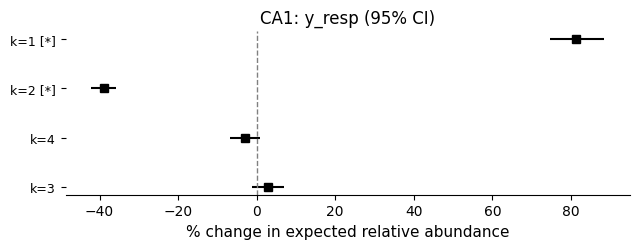

[saved] ca1_results/ca1_forest_y_resp.png


<Figure size 640x480 with 0 Axes>

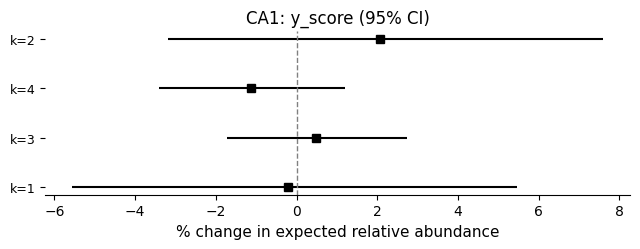

[saved] ca1_results/ca1_forest_y_score.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# =================================================================================================
# CA1 (Community Abundance Analysis) with explicit alpha and Milo-style filtering
# =================================================================================================
# Requires: numpy, pandas, matplotlib, statsmodels

import os
from typing import List, Dict, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm

# =============================================================================
# Helper: Fit Negative Binomial GLM with offset log(n)
# =============================================================================
def _fit_nb_glm_one_formula(
    df: pd.DataFrame,
    formula: str,
    offset_col: str = "n",
    cov_type: str = "HC1",
    alpha: float = 1.0
):
    """
    Fit a single Negative Binomial GLM using statsmodels.

    Intuition:
    ----------
    - Each community count c_k is modeled as:
        c_k ~ NegBin(mu, alpha)
    - With log(mu) = linear predictor + log(n) offset
      where n = total bag size.
    - The offset ensures we model *relative abundance*
      rather than absolute counts.

    Parameters
    ----------
    df : DataFrame
        Data with counts, targets, and covariates.
    formula : str
        Patsy formula (e.g., "c_1 ~ y_resp + age + site").
    offset_col : str, default="n"
        Column name with bag total size (log used as offset).
    cov_type : str, default="HC1"
        Covariance estimator type ("HC1" = robust SEs).
    alpha : float, default=1.0
        Dispersion parameter for Negative Binomial (fixes variance scaling).

    Returns
    -------
    res : statsmodels GLMResults
        Fitted model object.
    """
    model = smf.glm(
        formula=formula,
        data=df,
        family=sm.families.NegativeBinomial(alpha=alpha),
        offset=np.log(df[offset_col].clip(lower=1).values)  # avoid log(0)
    )
    res = model.fit(cov_type=cov_type)
    return res


# =============================================================================
# Main CA1 fitting function
# =============================================================================
def fit_ca1_multi_targets(
    df: pd.DataFrame,
    K: int,
    target_cols: List[str],
    covariates: Optional[List[str]] = None,
    offset_col: str = "n",
    cov_type: str = "HC1",
    handle_collinearity: str = "auto",   # "auto", "drop", "deviation", "none"
    ci_level: float = 0.95,
    outdir: Optional[str] = None,
    plot: bool = True,
    scale: str = "percent",   # "percent" or "ratio"
    alpha: float = 1.0,       # dispersion parameter for Negative Binomial
    min_total: int = 10,      # min total counts per community
    min_bags: int = 0         # min number of bags where community appears
) -> Dict[str, pd.DataFrame]:
    """
    Fit CA1 (Community Abundance analysis) for multiple bag-level targets.

    Intuition:
    ----------
    - For each target (e.g., treatment, survival score), we regress
      *each community’s count* on the target + covariates.
    - This tells us whether a community is more/less abundant when
      the target changes, after accounting for bag size and covariates.
    - Before fitting, communities that are too rare or small are filtered out,
      following Milo's practice of discarding undersized neighbourhoods.

    Parameters
    ----------
    df : DataFrame
        Wide bag-level DataFrame with columns:
          - n : total bag size (for offset)
          - c_1..c_K : community counts
          - targets : outcome columns
          - covariates : optional numeric/categorical bag covariates
    K : int
        Number of communities.
    target_cols : list of str
        Names of outcome columns to regress on.
    covariates : list of str, optional
        Extra covariates (numeric or categorical).
    offset_col : str, default="n"
        Column name with bag total size.
    cov_type : str, default="HC1"
        Covariance estimator type.
    handle_collinearity : {"auto","drop","deviation","none"}, default="auto"
        Strategy to avoid collinearity when communities are exclusive:
          - "auto": detect compositional counts and switch to "deviation".
          - "drop": drop last community as reference.
          - "deviation": impose sum-to-zero constraint across coefficients.
          - "none": include all communities (may cause collinearity).
    alpha : float, default=1.0
        Dispersion parameter for Negative Binomial GLMs.
    min_total : int, default=10
        Minimum total count across all bags to retain a community (Milo-like).
    min_bags : int, default=1
        Minimum number of bags in which a community must appear (Milo-like).
    scale : {"percent","ratio"}, default="percent"
        How to display effect sizes in plots:
          - "percent": (exp(coef)-1)*100 → % change
          - "ratio": exp(coef) → multiplicative ratio

    Returns
    -------
    results_by_target : dict[str, DataFrame]
        Mapping from each target to a DataFrame of fitted effect statistics.
    """
    if covariates is None:
        covariates = []
    if outdir:
        os.makedirs(outdir, exist_ok=True)

    results_by_target: Dict[str, pd.DataFrame] = {}

    # -------------------------------------------------------------------------
    # Filter sparse / rare communities (Milo-style)
    # -------------------------------------------------------------------------
    all_count_cols = [f"c_{k}" for k in range(1, K + 1)]
    count_cols = [c for c in all_count_cols if c in df.columns]
    totals = df[count_cols].sum(axis=0)
    presence = (df[count_cols] > 0).sum(axis=0)
    keep_mask = (totals >= min_total) & (presence >= min_bags)
    dropped = [c for c, keep in zip(count_cols, keep_mask) if not keep]

    if dropped:
        print(f"[filter] Dropping {len(dropped)} low-membership communities: {dropped}")
    df = df.drop(columns=dropped)
    kept_cols = [c for c in count_cols if c not in dropped]
    K = len(kept_cols)
    print(f"[filter] Retained {K} communities for testing after filtering.")

    # -------------------------------------------------------------------------
    # Detect compositional structure (fixed: now uses kept_cols)
    # -------------------------------------------------------------------------
    row_sums = df[kept_cols].sum(axis=1)
    is_compositional = np.allclose(row_sums.values, df[offset_col].values, rtol=1e-6, atol=1e-6)
    if handle_collinearity == "auto" and is_compositional:
        print("[info] Detected compositional counts → switching to deviation coding.")
        method = "deviation"
    else:
        method = handle_collinearity
    K_eff = K - 1 if method == "drop" else K

    # -------------------------------------------------------------------------
    # Fit one GLM per community per target
    # -------------------------------------------------------------------------
    for target in target_cols:
        rhs_terms = [target] + list(covariates)
        rhs = " + ".join(rhs_terms) if rhs_terms else "1"

        rows = []
        for k, response in enumerate(kept_cols[:K_eff], start=1):
            formula = f"{response} ~ {rhs}"
            res = _fit_nb_glm_one_formula(df, formula, offset_col, cov_type, alpha)

            for term in res.params.index:
                if term == "Intercept":
                    continue
                coef = res.params.get(term, np.nan)
                se = res.bse.get(term, np.nan)
                pval = res.pvalues.get(term, np.nan)
                lo, hi = res.conf_int(alpha=1 - ci_level).loc[term].values

                rows.append({
                    "target": target,
                    "community": f"k={k}",
                    "response": response,
                    "term": term,
                    "coef_log": coef,
                    "se": se,
                    "p": pval,
                    "ci_lo": lo,
                    "ci_hi": hi,
                    "exp_coef": np.exp(coef) if np.isfinite(coef) else np.nan,
                    "exp_ci_lo": np.exp(lo) if np.isfinite(lo) else np.nan,
                    "exp_ci_hi": np.exp(hi) if np.isfinite(hi) else np.nan,
                    "percent_change": (np.exp(coef) - 1) * 100,
                    "deviance": res.deviance,
                    "pearson_chi2": res.pearson_chi2,
                    "nobs": res.nobs
                })

        effects = pd.DataFrame(rows)

        # ---------------------------------------------------------------------
        # Deviation coding adjustment and FDR correction (fixed SEs)
        # ---------------------------------------------------------------------
        if method == "deviation":
            mask = effects["term"] == target
            coef_vec = effects.loc[mask, "coef_log"].to_numpy()
            Kc = len(coef_vec)
            mean_coef = np.nanmean(coef_vec)
            centered = coef_vec - mean_coef

            var_vec = effects.loc[mask, "se"].to_numpy() ** 2
            mean_var = np.mean(var_vec) / Kc
            var_centered = var_vec + mean_var - 2 * (var_vec / Kc)
            var_centered = np.clip(var_centered, 0, None)
            se_centered = np.sqrt(var_centered)
            z = np.divide(centered, se_centered, out=np.zeros_like(centered), where=se_centered > 0)
            p_centered = 2 * norm.sf(np.abs(z))
            zcrit = norm.ppf(0.5 + ci_level / 2)
            lo = centered - zcrit * se_centered
            hi = centered + zcrit * se_centered

            effects.loc[mask, "coef_log"] = centered
            effects.loc[mask, "se"] = se_centered
            effects.loc[mask, "p"] = p_centered
            effects.loc[mask, "ci_lo"] = lo
            effects.loc[mask, "ci_hi"] = hi
            effects.loc[mask, "exp_coef"] = np.exp(centered)
            effects.loc[mask, "exp_ci_lo"] = np.exp(lo)
            effects.loc[mask, "exp_ci_hi"] = np.exp(hi)
            effects.loc[mask, "percent_change"] = (effects.loc[mask, "exp_coef"] - 1) * 100

        # ---------------------------------------------------------------------
        # FDR correction (BH)
        # ---------------------------------------------------------------------
        effects["q"] = np.nan
        effects["significant"] = False
        for term_name, grp in effects.groupby("term", sort=False):
            rej, qvals, _, _ = multipletests(grp["p"].values, method="fdr_bh")
            effects.loc[grp.index, "q"] = qvals
            effects.loc[grp.index, "significant"] = rej

        if outdir:
            csv_path = os.path.join(outdir, f"ca1_effects_{target}.csv")
            effects.to_csv(csv_path, index=False)

        if plot:
            forest_plot_publication(
                effects=effects,
                term=target,
                ci_level=ci_level,
                title=f"CA1: {target}",
                scale=scale,
                sort_by_abs=True,
                outpath=os.path.join(outdir, f"ca1_forest_{target}.png") if outdir else None
            )

        results_by_target[target] = effects

    return results_by_target

# =============================================================================
# Forest plot
# =============================================================================
def forest_plot_publication(
    effects: pd.DataFrame,
    term: str,
    ci_level: float = 0.95,
    title: str = "",
    scale: str = "percent",    # "percent" or "ratio"
    sort_by_abs: bool = True,
    top_C: Optional[int] = 20, # show only top C communities by |effect|
    outpath: Optional[str] = None
):
    """
    Draw a publication-style forest plot for CA1 community effects.

    Parameters
    ----------
    effects : pd.DataFrame
        Output from fit_ca1_multi_targets().
    term : str
        Name of the target variable (e.g., 'y_resp', 'y_score').
    ci_level : float, default=0.95
        Confidence interval level.
    title : str, optional
        Plot title.
    scale : {'percent','ratio'}, default='percent'
        If 'percent': x-axis = % change (exp(coef)-1)*100.
        If 'ratio'  : x-axis = multiplicative ratio (exp(coef)).
    sort_by_abs : bool, default=True
        Sort by absolute effect size.
    top_C : int or None, default=20
        If not None, display only the top C communities by |effect|.
    outpath : str or None, optional
        Save figure to this path if provided.

    Notes
    -----
    - Each row = one community's effect on the target.
    - Squares = point estimates; horizontal lines = confidence intervals.
    - [*] marks significant (BH-FDR corrected) results.
    """
    df = effects.loc[effects["term"] == term].copy()
    if df.empty:
        print(f"[warn] No rows for term '{term}'")
        return

    # Choose plotting scale
    if scale == "percent":
        df["effect"] = (df["exp_coef"] - 1.0) * 100
        df["ci_lo_plot"] = (df["exp_ci_lo"] - 1.0) * 100
        df["ci_hi_plot"] = (df["exp_ci_hi"] - 1.0) * 100
        ref_line = 0.0
        x_label = "% change in expected relative abundance"
    elif scale == "ratio":
        df["effect"] = df["exp_coef"]
        df["ci_lo_plot"] = df["exp_ci_lo"]
        df["ci_hi_plot"] = df["exp_ci_hi"]
        ref_line = 1.0
        x_label = "Multiplicative effect on expected relative abundance"
    else:
        raise ValueError("scale must be 'percent' or 'ratio'")

    # Sort and subset
    if sort_by_abs:
        df = df.reindex(df["effect"].abs().sort_values(ascending=False).index)
    else:
        df = df.sort_values("community")

    if top_C is not None and len(df) > top_C:
        df = df.head(top_C)

    # Build label and y positions
    df["label"] = df["community"] + df["significant"].map(lambda x: " [*]" if x else "")
    y_pos = np.arange(len(df))

    # Plot
    fig, ax = plt.subplots(figsize=(6.5, 0.4 * len(df) + 1))
    for i, row in enumerate(df.itertuples(index=False)):
        ax.hlines(y=y_pos[i], xmin=row.ci_lo_plot, xmax=row.ci_hi_plot,
                  color="black", lw=1.5)
        ax.plot(row.effect, y_pos[i], "s", color="black", markersize=6, zorder=3)

    # Reference line and styling
    ax.axvline(ref_line, linestyle="--", color="gray", lw=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df["label"].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_title(f"{title} ({int(ci_level*100)}% CI)", fontsize=12)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.8)

    plt.tight_layout()
    plt.show()
    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"[saved] {outpath}")


# =============================================================================
# Example usage with NB-based simulated community counts
# =============================================================================
if __name__ == "__main__":
    rng = np.random.default_rng(7)

    N, K = 150, 4
    n = rng.poisson(500, size=N).clip(min=50)
    y_resp = rng.integers(0, 2, size=N)
    y_score = rng.normal(0, 1, size=N)
    age = rng.normal(60, 10, size=N)
    site = rng.choice(list("ABC"), size=N)

    # True baseline and effects: enforce exactly one positive and one negative cluster
    beta0 = np.array([-2.0, -2.2, -2.1, -2.3])
    betas = np.array([0.6, -0.5, 0.0, 0.0])  # k=1 positive, k=2 negative

    C = np.zeros((N, K), dtype=int)
    for k in range(K):
        eta = beta0[k] + y_resp * betas[k] + np.log(n)
        mu = np.exp(eta)
        C[:, k] = rng.poisson(mu)

    df = pd.DataFrame({
        "n": n,
        "c_1": C[:, 0], "c_2": C[:, 1], "c_3": C[:, 2], "c_4": C[:, 3],
        "y_resp": y_resp,
        "y_score": y_score,
        "age": age,
        "site": site
    })

    print(df.head())

    results = fit_ca1_multi_targets(
        df=df,
        K=K,
        target_cols=["y_resp", "y_score"],
        covariates=["age", "site"],
        handle_collinearity="auto",
        outdir="ca1_results",
        plot=True,
        scale="percent"
    )